<a href="https://www.kaggle.com/code/shahirhabib/semeval-2026-task-13-featuremethod?scriptVersionId=314871399" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [19]:
!gdown --id 1u0_PMsIOvQgJ9OctgshrMHXBmyDC-1hA -O /kaggle/working/finaltest.parquet

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1u0_PMsIOvQgJ9OctgshrMHXBmyDC-1hA
From (redirected): https://drive.google.com/uc?id=1u0_PMsIOvQgJ9OctgshrMHXBmyDC-1hA&confirm=t&uuid=57c4c107-9519-489e-88d0-0c0cb0ec739a
To: /kaggle/working/finaltest.parquet
100%|████████████████████████████████████████| 298M/298M [00:03<00:00, 97.9MB/s]


In [1]:
!gdown --id 19slGAb6cPmIaDeBHvzscRO0aJTIEjb0w -O /kaggle/working/trainpval_features_all.parquet

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=19slGAb6cPmIaDeBHvzscRO0aJTIEjb0w
From (redirected): https://drive.google.com/uc?id=19slGAb6cPmIaDeBHvzscRO0aJTIEjb0w&confirm=t&uuid=3c08e393-8454-4442-bb94-7ed5c2476266
To: /kaggle/working/trainpval_features_all.parquet
100%|████████████████████████████████████████| 301M/301M [00:04<00:00, 66.4MB/s]


In [2]:
!gdown --id 1zrI_UdIpuQHQKVqE_5coFfOb84MwCkif -O /kaggle/working/sampletest_features_all.parquet

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1zrI_UdIpuQHQKVqE_5coFfOb84MwCkif
To: /kaggle/working/sampletest_features_all.parquet
100%|████████████████████████████████████████| 756k/756k [00:00<00:00, 80.0MB/s]


### 📚 Import Required Library 

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from datasets import Dataset, load_from_disk
from sklearn.metrics import classification_report ,confusion_matrix 
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Extract first 500,000 rows

trainvaldf = pd.read_parquet("/kaggle/working/trainpval_features_all.parquet")

newdf = trainvaldf.iloc[:500000]
valdf = trainvaldf.iloc[500000:]
# Optional: check shape
print(newdf.shape)
print(valdf.shape)
out_path = f"train_features_all.parquet"
newdf.to_parquet(
    out_path,
    index=False
)
out_path2 = f"validation_features_all.parquet"
valdf.to_parquet(
    out_path2,
    index=False
)

(500000, 38)
(100000, 38)


In [5]:

sampledf = pd.read_parquet("/kaggle/working/sampletest_features_all.parquet")
sampledf.head()

,code,label,language,loc_total,loc_comments,loc_blank,comment_ratio,avg_line_length,max_line_length,indentation_std_dev,...,halstead_n2,halstead_N1,halstead_N2,halstead_vocab,halstead_length,maintainability_index,token_entropy,ast_node_entropy,perplexity_score,burstiness
0,public Vector To(Vector o)\n {\n ...,0,c#,8.0,0.0,0.0,0.000000,25.250000,50.0,3.968627,...,8.0,23.0,17.0,19.0,40.0,64.549375,4.043943,3.842678,10.612992,1.227278
1,func (v *DefaultMessageSyntaxValidator) Valida...,0,go,8.0,0.0,0.0,0.000000,40.625000,126.0,2.397916,...,24.0,40.0,33.0,36.0,73.0,61.988184,4.738918,4.715993,19.566830,23.450027
2,"""""""Module managing testsuite capabilities\n\nC...",0,python,77.0,15.0,15.0,0.194805,47.532468,116.0,4.453012,...,89.0,183.0,158.0,112.0,341.0,34.608739,5.802035,3.675598,50.225122,413.337393
3,void Anvil::Image::on_memory_backing_opaque_up...,0,c++,109.0,0.0,0.0,0.000000,51.256881,132.0,14.421972,...,69.0,370.0,194.0,109.0,564.0,30.341679,5.764046,0.000000,44.360261,606.061099
4,bool NOMAD::Priority_Eval_Point::dominates\n( ...,0,c++,86.0,0.0,0.0,0.000000,27.627907,77.0,4.157997,...,43.0,358.0,172.0,70.0,530.0,33.077549,5.106593,0.000000,20.368269,271.023607


In [5]:
import re

def detect_language(code: str) -> str:
    if not code or not code.strip():
        return "Python"

    code = code.strip()

    patterns = {
    "C": [
        r"#include\s*<stdio\.h>",
        r"#include\s*<stdlib\.h>",
        r"#include\s*<string\.h>",
        r"\bprintf\s*\(",
        r"\bscanf\s*\(",
        r"\bmalloc\s*\(",
        r"\bfree\s*\(",
        r"\bcalloc\s*\(",
        r"\brealloc\s*\(",
        r"\bint\s+main\s*\(",
        r"\bfor\s*\([^;]+;[^;]+;[^)]+\)",
        r"\bwhile\s*\(",
        r"\bdo\s*\{.*\}\s*while",
        r"\bif\s*\(",
        r"\belse\b",
        r"\bswitch\s*\(",
        r"\bcase\b",
        r"\bstruct\b",
        r"\btypedef\b",
        r";\s*$",  # Frequent semicolons at line ends
    ],
    "C++": [
        r"#include\s*<iostream>",
        r"#include\s*<vector>",
        r"#include\s*<string>",
        r"\bstd::",
        r"\bcout\b",
        r"\bcin\b",
        r"\busing\s+namespace\s+std;?",
        r"\bclass\b",
        r"\bpublic:|\bprivate:|\bprotected:",
        r"\btemplate\s*<",
        r"\bnamespace\b",
        r"\bnew\s+\w",
        r"\bdelete\s+\w",
        r"\bfor\s*\([^;]+;[^;]+;[^)]+\)",
        r"\bwhile\s*\(",
        r"\bif\s*\(",
        r"\belse\b",
        r"\bswitch\s*\(",
        r"\bauto\b",
        r"=>",  # Lambda
        r"\bstd::cout\s*<<",
    ],
    "Java": [
        r"\bpublic\s+class\b",
        r"\bprivate\s+class\b",
        r"\bstatic\s+void\s+main\s*\(",
        r"\bSystem\.out\.print(ln)?\s*\(",
        r"\bimport\s+java\.",
        r"\bpackage\s+[\w\.]+;",
        r"\bpublic\s+static\b",
        r"\bnew\s+\w+\s*\(",
        r"\bextends\b",
        r"\bimplements\b",
        r"\b@Override",
        r"\bfor\s*\(\w+\s+\w+\s*:\s*\w+\)",
        r"\bfor\s*\([^;]+;[^;]+;[^)]+\)",
        r"\bwhile\s*\(",
        r"\bif\s*\(",
        r"\belse\b",
        r"\bswitch\s*\(",
        r"\bString\s+\w+\s*=",
        r"\bint\s+\w+\s*=",
    ],
    "Python": [
        r"\bdef\s+\w+\s*\(",
        r"\bclass\s+\w+\s*:",
        r"\bimport\s+\w",
        r"\bfrom\s+\w+\s+import",
        r"\bprint\s*\(",
        r"\bself\b",
        r":\s*(#.*)?$",  # Indentation colon
        r"\bfor\s+\w+\s+in\b",
        r"\bwhile\s*:",
        r"\bif\s*:",
        r"\belif\b",
        r"\belse\s*:",
        r"\btry\s*:",
        r"\bexcept\b",
        r"\bfinally\s*:",
        r"\blambda\s+\w+:",
        r"\b__init__\s*\(",
        r"^ {4}|\t",  # Indentation (common in real code)
        r"\w+\s*=\s*\{.*\}",  # Dict literal
    ],
    "Go": [
        r"\bpackage\s+main\b",
        r"\bpackage\s+\w+\b",
        r"\bfunc\s+main\s*\(",
        r"\bfunc\s+\w+\s*\(",
        r"\bfmt\.Print(ln)?\s*\(",
        r"\bimport\s+\(",
        r"\bimport\s+\"[\w/]+\"",
        r"\bvar\s+\w+\s+\w+",
        r"\bconst\s+\w+",
        r"\btype\s+\w+\s+struct\b",
        r"\bfor\s+\w+\s*:=\s*range",
        r"\bfor\s*\([^;]*;[^;]*;[^)]*\)",
        r"\bfor\s*\(\s*\)\s*\{",  # Infinite loop
        r"\bif\s+\w+\s*:=",
        r"\bif\s*\(",
        r"\belse\b",
        r"\bswitch\b",
        r"\bcase\b",
        r"\bgo\s+\w+\s*\(",  # Goroutine
        r":=",  # Short declaration
    ],
    "PHP": [
        r"<\?php",
        r"<\?",
        r"\becho\b",
        r"\bprint\b",
        r"\$\w+",
        r"\bfunction\s+\w+\s*\(",
        r"\bclass\s+\w+",
        r"\bpublic\s+function",
        r"\bprivate\s+function",
        r"\bforeach\s*\(\s*\$",
        r"\bfor\s*\(",
        r"\bwhile\s*\(",
        r"\bif\s*\(",
        r"\belse\b",
        r"\bswitch\s*\(",
        r"\$this->",
        r"\brequire_once\b",
        r"\binclude\b",
    ],
    "JavaScript": [
        r"\bfunction\s+\w*\s*\(",
        r"\bconsole\.log\s*\(",
        r"\b(let|var|const)\b",
        r"=>",
        r"\bdocument\.",
        r"\bwindow\.",
        r"\brequire\s*\(",
        r"\bimport\s+.*\s+from",
        r"\bexport\b",
        r"\bfor\s*\(\s*(let|var)\b",
        r"\bfor\s*\(\s*.*\s+of\s+\)",
        r"\bfor\s*\(\s*.*\s+in\s+\)",
        r"\bwhile\s*\(",
        r"\bif\s*\(",
        r"\belse\b",
        r"\bswitch\s*\(",
        r"\bcase\b",
        r"\basync\s+\w*",
        r"\bawait\b",
        r"\{.*\}",  # Object literals common
        r"\[.*\]",  # Array literals
    ],
      "CSharp": [
    r"\busing\s+[A-Za-z_][A-Za-z0-9_.]*\s*;",        # using System.Text;
    r"\bnamespace\s+[A-Za-z_][A-Za-z0-9_.]*\s*\{",   # namespace MyApp {
    r"\bConsole\.Write(Line)?\s*\(",                 # Console.WriteLine(
    r"\bpublic\s+class\s+\w+",                       # public class Foo
    r"\binternal\s+class\s+\w+",                     # internal class Foo
    r"\bclass\s+\w+\s*:\s*\w+",                      # class Foo : Bar
   
    r"\bforeach\s*\(\s*var\s+\w+\s+in\s+",           # foreach (var x in y)
    r"\bvar\s+\w+\s*=",                               # var x =
    r"\bnew\s+\w+<[^>]+>\s*\(",                      # new List<int>(
    r"\bTask<",                                      # async Task<T>
    r"\basync\s+Task\b",                             # async Task
    r"\bawait\s+\w+",                                # await foo
    r"\b\[\s*(Serializable|HttpGet|HttpPost|Route)", # attributes [HttpGet]
]
    }

    scores = {lang: 0 for lang in patterns}

    for lang, regexes in patterns.items():
        for regex in regexes:
            if re.search(regex, code):
                scores[lang] += 1

    # Choose the language with the highest score
    detected_language = max(scores, key=scores.get)
    # print(scores)
    # If no strong signal found, default to Python
    if scores[detected_language] == 0:
        return "Python"

    return detected_language

# Example usage
import pandas as pd
testdf = pd.read_parquet('/kaggle/working/finaltest.parquet')
testdf.head()
from tqdm import tqdm 
tqdm.pandas()
testdf['language'] = testdf['code'].progress_apply(detect_language)
testdf.head()
testdf.to_csv('/kaggle/working/finaltest.csv', index=False)

100%|██████████| 500000/500000 [28:41<00:00, 290.47it/s] 


### 🗂️ Getting Started with The Dataset Provided

In [4]:
train_df = pd.read_parquet("/kaggle/input/semeval-2026-task-13-dataset/SemEval-2026-Task13/task_a/task_a_training_set_1.parquet")
validation_df = pd.read_parquet("/kaggle/input/semeval-2026-task-13-dataset/SemEval-2026-Task13/task_a/task_a_validation_set.parquet")
test_df = pd.read_parquet("/kaggle/input/semeval-2026-task-13-dataset/SemEval-2026-Task13/task_a/task_a_test_set_sample.parquet")
train_df.head()

,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python
3,T = int(input())\nfor t in range(T):\n\tcolor ...,human,0,Python
4,for i in range(int(input())):\n\tinput()\n\ta ...,human,0,Python


### 🧮 Visualizing Dataset 

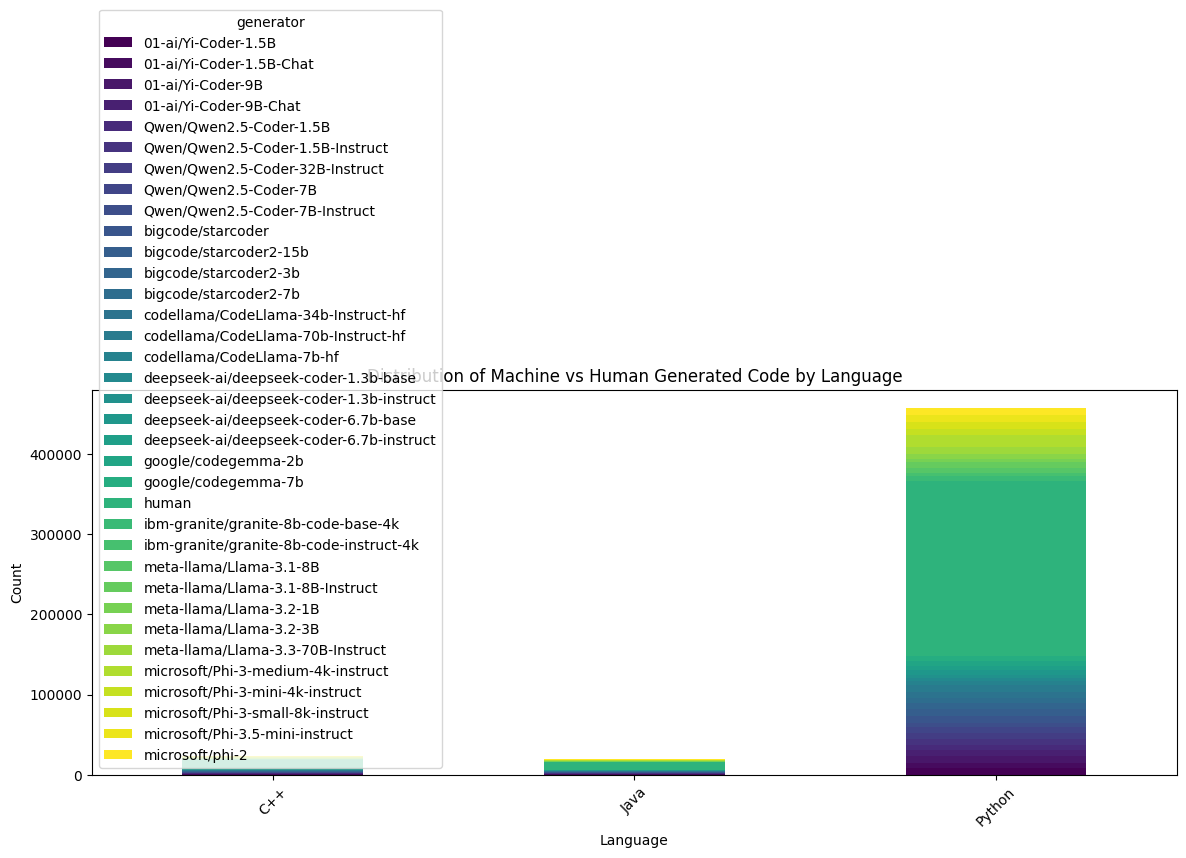

In [5]:

pivot_df = train_df.groupby(['language', 'generator']).size().unstack().fillna(0)

pivot_df.plot(kind='bar', stacked=True, figsize=(14, 5), colormap="viridis")

plt.xlabel('Language')
plt.ylabel('Count')
plt.title('Distribution of Machine vs Human Generated Code by Language')
plt.xticks(rotation=45)

plt.show()


### Test dataset Visualization

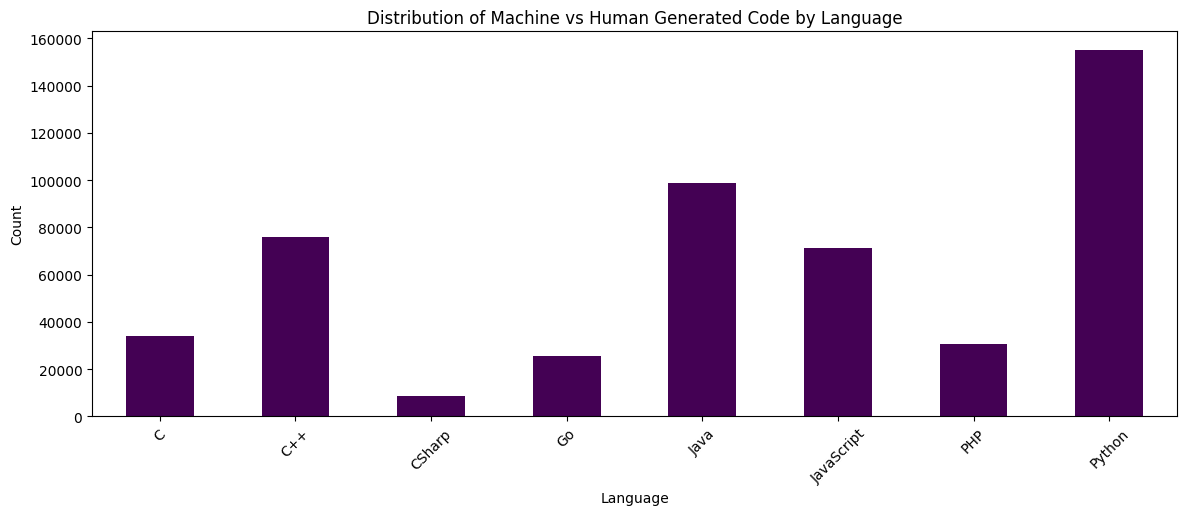

In [8]:
finaltestdf= pd.read_csv("/kaggle/working/finaltest.csv")
# finaltestdf.info()
# finaltestdf.sample(10)
pivot_df = finaltestdf.groupby(['language']).size()

pivot_df.plot(kind='bar', stacked=True, figsize=(14, 5), colormap="viridis")

plt.xlabel('Language')
plt.ylabel('Count')
plt.title('Distribution of Machine vs Human Generated Code by Language')
plt.xticks(rotation=45)

plt.show()


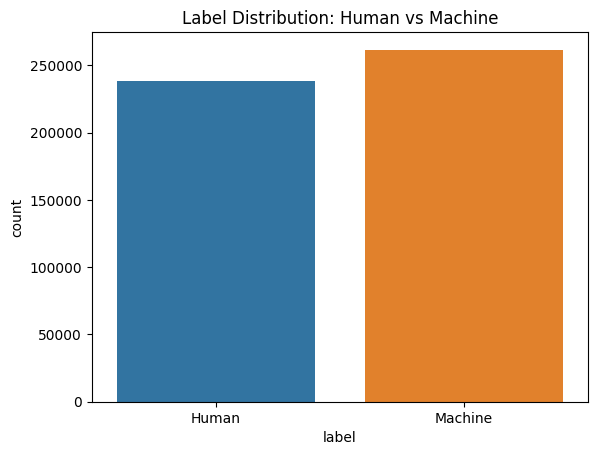

In [31]:
train_df['label'] = train_df['label'].astype(int)
validation_df['label'] = validation_df['label'].astype(int)
train_df['label'].value_counts().sort_index()
sns.countplot(data=train_df, x='label')
plt.title("Label Distribution: Human vs Machine")
plt.xticks([0, 1], ['Human', 'Machine'])
plt.show()

In [ ]:
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow logging
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", len(gpus) > 0)

if gpus:
    print("Number of GPUs:", len(gpus))
    for i, gpu in enumerate(gpus):
        print(f"GPU {i}:", gpu.name)
else:
    print("No GPU found.")


## Feature extraction
1.  loc_total: Total lines of code
2.  loc_comments: Count of lines containing comments
3.  loc_blank: Count of empty lines
4.  comment_ratio: loc_comments / loc_total
5.  avg_line_length: Average number of characters per line
6.  max_line_length: Length of the longest line
7.  indentation_std_dev: Standard deviation of indentation levels

8.  unique_identifier_ratio: Count of unique variables / total tokens (Type-Token Ratio)
9.  avg_identifier_length: Average length of variable/function names
10. snake_case_ratio: Percentage of identifiers using snake_case (vs camelCase)
11. keyword_density: Count of language keywords / total tokens
12. hapax_legomena_count: Number of identifiers that appear exactly once

13. ast_node_count: Total number of nodes in the Abstract Syntax Tree
14. ast_max_depth: The deepest nesting level of the tree
15. ast_avg_branching_factor: Average number of children per node
16. control_flow_ratio: (Count of If + For + While nodes) / ast_node_count
17. exception_handling_ratio: (Count of Try + Except nodes) / ast_node_count
18. return_statement_density: Count of Return nodes / num_functions
19. syntactic_ngram_frequency: Frequency of specific parent-child pairs (e.g., For → If)

20. cyclomatic_complexity: McCabe’s complexity (Number of linearly independent paths)
21. halstead_volume: Information content of the code in bits
22. halstead_difficulty: How difficult the program is to write/understand
23. halstead_effort: volume × difficulty (Estimated mental effort)
24. maintainability_index: Composite score (0–100) combining Halstead, McCabe, and LOC
25. cognitive_complexity: Metric penalizing nesting and confusing sequences more than McCabe

26. token_entropy: Shannon entropy of the token distribution
27. ast_node_entropy: Shannon entropy of the AST node type distribution
28. perplexity_score: Perplexity of the code calculated by a proxy model
29. burstiness: Variance of perplexity across the snippet


In [9]:
"""
Feature extractor for SemEval-2026 Task 13 Subtask A 

"""
from __future__ import annotations
import ast
import io
import math
import keyword
import tokenize
from collections import Counter, defaultdict
from typing import List, Tuple, Dict, Any
import statistics

try:
    import numpy as np
    import pandas as pd
except Exception:
    np = None
    pd = None

# ----------------------------- Low-level helpers --------------------------------

def tokens_from_code(code: str) -> List[Tuple[int, str, int]]:
    """Return list of (tok_type, tok_str, lineno) for Python code."""
    toks = []
    try:
        reader = io.StringIO(code).readline
        for tok in tokenize.generate_tokens(reader):
            tok_type = tok.type
            tok_str = tok.string
            lineno = tok.start[0]
            toks.append((tok_type, tok_str, lineno))
    except Exception:
        # fallback empty
        pass
    return toks


def shannon_entropy(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0:
        return 0.0
    ent = 0.0
    for v in counter.values():
        p = v / total
        ent -= p * math.log2(p)
    return ent

# ----------------------------- AST helpers --------------------------------

def ast_walk_with_parents(node: ast.AST):
    """Yield (parent, child) pairs for all child nodes."""
    for parent in ast.walk(node):
        for child in ast.iter_child_nodes(parent):
            yield parent, child


def ast_node_count(node: ast.AST) -> int:
    return sum(1 for _ in ast.walk(node))


def ast_max_depth(node: ast.AST) -> int:
    def depth(n):
        children = list(ast.iter_child_nodes(n))
        if not children:
            return 1
        return 1 + max(depth(c) for c in children)
    try:
        return depth(node)
    except Exception:
        return 0


def ast_avg_branching(node: ast.AST) -> float:
    nodes = list(ast.walk(node))
    if not nodes:
        return 0.0
    child_counts = [len(list(ast.iter_child_nodes(n))) for n in nodes]
    return sum(child_counts) / len(child_counts)

# ----------------------------- Complexity helpers --------------------------------

def compute_cyclomatic(node: ast.AST) -> int:
    """Simplified McCabe: 1 + number of decision points across the module."""
    decisions = 0
    for n in ast.walk(node):
        if isinstance(n, (ast.If, ast.For, ast.While, ast.With, ast.AsyncWith, ast.IfExp)):
            decisions += 1
        elif isinstance(n, ast.BoolOp):
            # each boolean operator increases independent paths by n-1
            decisions += max(0, len(n.values) - 1)
        elif isinstance(n, (ast.Try,)):
            # try/except can change paths
            decisions += 1
    return max(1, 1 + decisions)


def compute_cognitive_complexity(node: ast.AST) -> float:
    """Heuristic cognitive complexity: increase for nesting and control structures.
    This is a simplified proxy of more elaborate algorithms (e.g., SonarSource algorithm).
    """
    score = 0

    control_types = (ast.If, ast.For, ast.While, ast.With, ast.Try, ast.IfExp)

    def visit(n, nesting=0):
        nonlocal score
        if isinstance(n, control_types):
            score += 1 + nesting
            nesting += 1
        # boolean operations add small penalty
        if isinstance(n, ast.BoolOp):
            score += 0.5
        for c in ast.iter_child_nodes(n):
            visit(c, nesting)

    try:
        visit(node, 0)
    except Exception:
        return 0.0
    return float(score)

# ----------------------------- Halstead metrics --------------------------------

def halstead_metrics_from_tokens(toks: List[Tuple[int, str, int]]) -> Dict[str, float]:
    operators = []
    operands = []
    for tt, ts, _ in toks:
        if tt == tokenize.OP or ts in keyword.kwlist:
            operators.append(ts)
        elif tt == tokenize.NAME or tt == tokenize.NUMBER or tt == tokenize.STRING:
            operands.append(ts)
        else:
            # treat other types conservatively
            if ts.strip():
                operands.append(ts)
    N1 = len(operators)
    N2 = len(operands)
    n1 = len(set(operators))
    n2 = len(set(operands))
    n = n1 + n2
    N = N1 + N2
    if n == 0:
        volume = 0.0
    else:
        volume = N * math.log2(n if n > 0 else 1)
    difficulty = 0.0
    if n2 > 0:
        difficulty = (n1 / 2.0) * (N2 / n2)
    effort = volume * difficulty
    return {
        'halstead_n1': float(n1),
        'halstead_n2': float(n2),
        'halstead_N1': float(N1),
        'halstead_N2': float(N2),
        'halstead_vocab': float(n),
        'halstead_length': float(N),
        'halstead_volume': float(volume),
        'halstead_difficulty': float(difficulty),
        'halstead_effort': float(effort),
    }

# ----------------------------- Perplexity proxy (n-gram) --------------------------------

def build_ngram_counts(tokens: List[str], n: int = 3):
    counts = Counter()
    context_counts = Counter()
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    for i in range(len(padded) - n + 1):
        ctx = tuple(padded[i:i + n - 1])
        gram = tuple(padded[i:i + n])
        counts[gram] += 1
        context_counts[ctx] += 1
    return counts, context_counts


def perplexity_of_tokens(tokens: List[str], ngram_counts, context_counts, n=3, vocab_size=None):
    counts = ngram_counts
    ctx_counts = context_counts
    V = vocab_size or max(1, len({t for ctx in ctx_counts for t in ctx}))
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    log_prob = 0.0
    N = 0
    for i in range(n - 1, len(padded)):
        ctx = tuple(padded[i - (n - 1):i])
        gram = tuple(padded[i - (n - 1):i + 1])
        numer = counts.get(gram, 0) + 1  # add-one smoothing
        denom = ctx_counts.get(ctx, 0) + V
        prob = numer / denom
        log_prob += -math.log2(prob)
        N += 1
    if N == 0:
        return float('inf')
    cross_entropy = log_prob / N
    perplexity = 2 ** cross_entropy
    return float(perplexity)

# ----------------------------- Main extractor --------------------------------

def extract_features_python(code: str) -> Dict[str, Any]:
    # basic lines
    lines = code.splitlines()
    loc_total = len(lines)
    loc_blank = sum(1 for L in lines if L.strip() == '')
    # comment lines: naive detect '#'
    loc_comments = sum(1 for L in lines if '#' in L)
    comment_ratio = (loc_comments / loc_total) if loc_total > 0 else 0.0
    line_lengths = [len(L) for L in lines] if lines else [0]
    avg_line_length = statistics.mean(line_lengths) if line_lengths else 0.0
    max_line_length = max(line_lengths) if line_lengths else 0
    # indentation levels (leading spaces, tabs -> 4 spaces)
    indents = []
    for L in lines:
        leading = 0
        for ch in L:
            if ch == '\t':
                leading += 4
            elif ch == ' ':
                leading += 1
            else:
                break
        indents.append(leading)
    indentation_std_dev = float(statistics.pstdev(indents)) if indents else 0.0

    # tokens & ast
    toks = tokens_from_code(code)
    token_strings = [ts for _, ts, _ in toks if ts.strip()]
    total_tokens = max(1, len(token_strings))

    # identifiers: use AST to capture semantic identifiers
    try:
        tree = ast.parse(code)
    except Exception:
        tree = None

    identifiers = []
    if tree is not None:
        for n in ast.walk(tree):
            if isinstance(n, ast.Name):
                identifiers.append(n.id)
            elif isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
                identifiers.append(n.name)
            elif isinstance(n, ast.arg):
                identifiers.append(n.arg)
    id_counter = Counter(identifiers)
    unique_identifier_ratio = (len(id_counter) / total_tokens) if total_tokens > 0 else 0.0
    avg_identifier_length = (statistics.mean([len(i) for i in identifiers]) if identifiers else 0.0)
    snake_count = 0
    camel_count = 0
    for ident in identifiers:
        if ident.islower() and '_' in ident:
            snake_count += 1
        elif any(c.isupper() for c in ident[1:]):
            camel_count += 1
    snake_case_ratio = (snake_count / (snake_count + camel_count)) if (snake_count + camel_count) > 0 else 0.0
    keyword_count = sum(1 for t in token_strings if t in keyword.kwlist)
    keyword_density = keyword_count / total_tokens
    hapax_legomena_count = sum(1 for idn, cnt in id_counter.items() if cnt == 1)

    # AST metrics
    ast_node_cnt = float(ast_node_count(tree)) if tree is not None else 0.0
    ast_max_d = float(ast_max_depth(tree)) if tree is not None else 0.0
    ast_avg_branch = float(ast_avg_branching(tree)) if tree is not None else 0.0

    # parent-child syntactic pairs frequency
    parent_child = Counter()
    if tree is not None:
        for p, c in ast_walk_with_parents(tree):
            parent_child[(type(p).__name__, type(c).__name__)] += 1
    # example: frequency of For -> If
    syntactic_ngram_frequency = float(parent_child.get(('For', 'If'), 0)) / (ast_node_cnt if ast_node_cnt > 0 else 1)

    # control flow and exception handling
    control_count = sum(1 for n in ast.walk(tree) if isinstance(n, (ast.If, ast.For, ast.While))) if tree is not None else 0
    exception_count = sum(1 for n in ast.walk(tree) if isinstance(n, ast.Try)) if tree is not None else 0
    control_flow_ratio = (control_count / ast_node_cnt) if ast_node_cnt > 0 else 0.0
    exception_handling_ratio = (exception_count / ast_node_cnt) if ast_node_cnt > 0 else 0.0

    # return statement density
    num_functions = sum(1 for n in ast.walk(tree) if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef))) if tree is not None else 0
    return_count = sum(1 for n in ast.walk(tree) if isinstance(n, ast.Return)) if tree is not None else 0
    return_statement_density = (return_count / num_functions) if num_functions > 0 else float(return_count)

    # metrics: cyclomatic, halstead, maintainability, cognitive
    cyclomatic_complexity = float(compute_cyclomatic(tree)) if tree is not None else 0.0
    hal = halstead_metrics_from_tokens(toks)
    halstead_volume = hal['halstead_volume']
    halstead_difficulty = hal['halstead_difficulty']
    halstead_effort = hal['halstead_effort']

    # maintainability index (classic formula, scaled 0-100)
    try:
        # avoid log of zero
        V = halstead_volume if halstead_volume > 0 else 1.0
        mi = max(0.0, (171 - 5.2 * math.log(V) - 0.23 * cyclomatic_complexity - 16.2 * math.log(max(1.0, loc_total))) )
        maintainability_index = (mi / 171.0) * 100.0
    except Exception:
        maintainability_index = 0.0

    cognitive_complexity = float(compute_cognitive_complexity(tree)) if tree is not None else 0.0

    # entropy measures
    token_counter = Counter(token_strings)
    token_entropy = float(shannon_entropy(token_counter))
    ast_node_types = Counter(type(n).__name__ for n in ast.walk(tree)) if tree is not None else Counter()
    ast_node_entropy = float(shannon_entropy(ast_node_types))

    # perplexity proxy using internal n-gram model (3-gram) with add-one smoothing
    token_seq = token_strings
    if len(token_seq) < 1:
        perplexity_score = float('inf')
        burstiness = 0.0
    else:
        n = 3
        ngram_counts, ctx_counts = build_ngram_counts(token_seq, n=n)
        vocab = len(set(token_seq)) + 2
        perplexity_score = perplexity_of_tokens(token_seq, ngram_counts, ctx_counts, n=n, vocab_size=vocab)
        # burstiness: compute perplexity per-line and take variance
        # build token lists per line
        tokens_by_line = defaultdict(list)
        for tt, ts, lineno in toks:
            if ts.strip():
                tokens_by_line[lineno].append(ts)
        line_perps = []
        for ln in sorted(tokens_by_line.keys()):
            per = perplexity_of_tokens(tokens_by_line[ln], ngram_counts, ctx_counts, n=n, vocab_size=vocab)
            if math.isfinite(per):
                line_perps.append(per)
        burstiness = float(np.var(line_perps)) if (np is not None and line_perps) else (float(statistics.pvariance(line_perps)) if line_perps else 0.0)

    result = {
        'loc_total': float(loc_total),
        'loc_comments': float(loc_comments),
        'loc_blank': float(loc_blank),
        'comment_ratio': float(comment_ratio),
        'avg_line_length': float(avg_line_length),
        'max_line_length': float(max_line_length),
        'indentation_std_dev': float(indentation_std_dev),

        'unique_identifier_ratio': float(unique_identifier_ratio),
        'avg_identifier_length': float(avg_identifier_length),
        'snake_case_ratio': float(snake_case_ratio),
        'keyword_density': float(keyword_density),
        'hapax_legomena_count': float(hapax_legomena_count),

        'ast_node_count': float(ast_node_cnt),
        'ast_max_depth': float(ast_max_d),
        'ast_avg_branching_factor': float(ast_avg_branch),
        'control_flow_ratio': float(control_flow_ratio),
        'exception_handling_ratio': float(exception_handling_ratio),
        'return_statement_density': float(return_statement_density),
        'syntactic_ngram_frequency': float(syntactic_ngram_frequency),

        'cyclomatic_complexity': float(cyclomatic_complexity),
        'halstead_volume': float(halstead_volume),
        'halstead_difficulty': float(halstead_difficulty),
        'halstead_effort': float(halstead_effort),
        'maintainability_index': float(maintainability_index),
        'cognitive_complexity': float(cognitive_complexity),

        'token_entropy': float(token_entropy),
        'ast_node_entropy': float(ast_node_entropy),
        'perplexity_score': float(perplexity_score),
        'burstiness': float(burstiness),
    }

    # include halstead counts for completeness
    result.update({k: float(v) for k, v in hal.items()})

    return result

In [10]:
f = extract_features_python(train_df['code'][0])
import pprint
pprint.pprint(f)
print(len(f))

{'ast_avg_branching_factor': 0.9924812030075187,
 'ast_max_depth': 9.0,
 'ast_node_count': 133.0,
 'ast_node_entropy': 3.552783408929339,
 'avg_identifier_length': 1.4242424242424243,
 'avg_line_length': 17.153846153846153,
 'burstiness': 26.508580407933607,
 'cognitive_complexity': 15.0,
 'comment_ratio': 0.0,
 'control_flow_ratio': 0.03759398496240601,
 'cyclomatic_complexity': 6.0,
 'exception_handling_ratio': 0.0,
 'halstead_N1': 59.0,
 'halstead_N2': 46.0,
 'halstead_difficulty': 17.523809523809526,
 'halstead_effort': 9585.394192757269,
 'halstead_length': 105.0,
 'halstead_n1': 16.0,
 'halstead_n2': 21.0,
 'halstead_vocab': 37.0,
 'halstead_volume': 546.9926033910398,
 'hapax_legomena_count': 2.0,
 'indentation_std_dev': 3.3139475736212334,
 'keyword_density': 0.0761904761904762,
 'loc_blank': 0.0,
 'loc_comments': 0.0,
 'loc_total': 13.0,
 'maintainability_index': 55.722080088957206,
 'max_line_length': 48.0,
 'perplexity_score': 18.479354476983527,
 'return_statement_density':

**Feature extraction for java**

In [11]:
pip install javalang

Note: you may need to restart the kernel to use updated packages.


In [12]:
"""
Feature extractor for SemEval-2026 Task 13 Subtask A (Java Version)
Requires: pip install javalang numpy pandas
"""
from __future__ import annotations
import math
import re
import statistics
from collections import Counter, defaultdict
from typing import List, Tuple, Dict, Any, Optional

# Third-party parser for Java
try:
    import javalang
    from javalang import tree as jtree
except ImportError:
    raise ImportError("The 'javalang' library is required. Install it via 'pip install javalang'.")

try:
    import numpy as np
    import pandas as pd
except Exception:
    np = None
    pd = None

# ----------------------------- Low-level helpers --------------------------------

def clean_comments_java(code: str) -> str:
    code = re.sub(r'//.*', '', code)
    code = re.sub(r'/\*.*?\*/', '', code, flags=re.DOTALL)
    return code

def java_tokens_from_code_java(code: str) -> List[Any]:
    tokens = []
    try:
        tokens = list(javalang.tokenizer.tokenize(code))
    except Exception:
        pass
    return tokens

def shannon_entropy_java(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0:
        return 0.0
    ent = 0.0
    for v in counter.values():
        p = v / total
        ent -= p * math.log2(p)
    return ent

# ----------------------------- AST helpers --------------------------------

def java_ast_walk_java(node):
    if node is None:
        return
    if isinstance(node, (javalang.ast.Node, list, tuple)):
        yield node
        children = []
        if isinstance(node, javalang.ast.Node):
            children = node.children
        elif isinstance(node, (list, tuple)):
            children = node
        for child in children:
            if isinstance(child, (javalang.ast.Node, list, tuple)):
                yield from java_ast_walk_java(child)

def java_ast_walk_with_parents_java(node):
    if isinstance(node, javalang.ast.Node):
        for child in node.children:
            if isinstance(child, javalang.ast.Node):
                yield node, child
                yield from java_ast_walk_with_parents_java(child)
            elif isinstance(child, (list, tuple)):
                for item in child:
                    if isinstance(item, javalang.ast.Node):
                        yield node, item
                        yield from java_ast_walk_with_parents_java(item)

def ast_node_count_java(node) -> int:
    return sum(1 for _ in java_ast_walk_java(node)) if node else 0

def ast_max_depth_java(node) -> int:
    def depth(n):
        if not isinstance(n, javalang.ast.Node):
            return 0
        children = [c for c in n.children if isinstance(c, (javalang.ast.Node, list, tuple))]
        if not children:
            return 1
        max_child_depth = 0
        for c in children:
            if isinstance(c, list):
                for item in c:
                    if isinstance(item, javalang.ast.Node):
                        max_child_depth = max(max_child_depth, depth(item))
            elif isinstance(c, javalang.ast.Node):
                max_child_depth = max(max_child_depth, depth(c))
        return 1 + max_child_depth
    try:
        return depth(node)
    except Exception:
        return 0

def ast_avg_branching_java(node) -> float:
    nodes = [n for n in java_ast_walk_java(node) if isinstance(n, javalang.ast.Node)]
    if not nodes:
        return 0.0
    total_children = 0
    for n in nodes:
        local_children = 0
        for child in n.children:
            if isinstance(child, javalang.ast.Node):
                local_children += 1
            elif isinstance(child, list):
                local_children += len([x for x in child if isinstance(x, javalang.ast.Node)])
        total_children += local_children
    return total_children / len(nodes)

# ----------------------------- Complexity helpers --------------------------------

def compute_cyclomatic_java_java(node) -> int:
    decisions = 0
    decision_types = (
        jtree.IfStatement, jtree.ForStatement, jtree.WhileStatement, 
        jtree.DoStatement, jtree.CatchClause, jtree.SwitchStatement,jtree.SwitchStatementCase
    )
    for n in java_ast_walk_java(node):
        if isinstance(n, decision_types):
            decisions += 1
        elif isinstance(n, jtree.SwitchStatementCase):
            decisions += 1
        elif isinstance(n, jtree.BinaryOperation):
            if n.operator in ('&&', '||'):
                decisions += 1
        elif isinstance(n, jtree.TernaryExpression):
            decisions += 1
    return max(1, 1 + decisions)

def compute_cognitive_complexity_java_java(node) -> float:
    score = 0
    nesting_types = (
        jtree.IfStatement, jtree.ForStatement, jtree.WhileStatement, 
        jtree.DoStatement, jtree.CatchClause, jtree.SwitchStatement
    )
    def visit(n, nesting=0):
        nonlocal score
        current_nesting = nesting
        if isinstance(n, nesting_types):
            score += 1 + nesting
            current_nesting += 1
        elif isinstance(n, jtree.TernaryExpression):
            score += 1 + nesting
        if isinstance(n, jtree.BinaryOperation):
            if n.operator in ('&&', '||'):
                score += 1
        if hasattr(n, 'children'):
            for child in n.children:
                if isinstance(child, javalang.ast.Node):
                    visit(child, current_nesting)
                elif isinstance(child, list):
                    for item in child:
                        if isinstance(item, javalang.ast.Node):
                            visit(item, current_nesting)
    try:
        visit(node, 0)
    except Exception:
        return 0.0
    return float(score)

# ----------------------------- Halstead metrics --------------------------------

def halstead_metrics_from_java_tokens_java(tokens) -> Dict[str, float]:
    operators = []
    operands = []
    for tok in tokens:
        val = tok.value
        if isinstance(tok, (javalang.tokenizer.Keyword, javalang.tokenizer.Separator, javalang.tokenizer.Operator)):
            operators.append(val)
        elif isinstance(tok, (javalang.tokenizer.Identifier, javalang.tokenizer.Literal)):
            operands.append(val)
        else:
            operands.append(val)
    N1 = len(operators)
    N2 = len(operands)
    n1 = len(set(operators))
    n2 = len(set(operands))
    n = n1 + n2
    N = N1 + N2
    if n == 0:
        volume = 0.0
    else:
        volume = N * math.log2(n if n > 0 else 1)
    difficulty = 0.0
    if n2 > 0:
        difficulty = (n1 / 2.0) * (N2 / n2)
    effort = volume * difficulty
    return {
        'halstead_n1': float(n1),
        'halstead_n2': float(n2),
        'halstead_N1': float(N1),
        'halstead_N2': float(N2),
        'halstead_vocab': float(n),
        'halstead_length': float(N),
        'halstead_volume': float(volume),
        'halstead_difficulty': float(difficulty),
        'halstead_effort': float(effort),
    }

# ----------------------------- Perplexity proxy --------------------------------

def build_ngram_counts_java(tokens: List[str], n: int = 3):
    counts = Counter()
    context_counts = Counter()
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    for i in range(len(padded) - n + 1):
        ctx = tuple(padded[i:i + n - 1])
        gram = tuple(padded[i:i + n])
        counts[gram] += 1
        context_counts[ctx] += 1
    return counts, context_counts

def perplexity_of_tokens_java(tokens: List[str], ngram_counts, context_counts, n=3, vocab_size=None):
    counts = ngram_counts
    ctx_counts = context_counts
    V = vocab_size or max(1, len({t for ctx in ctx_counts for t in ctx}))
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    log_prob = 0.0
    N = 0
    for i in range(n - 1, len(padded)):
        ctx = tuple(padded[i - (n - 1):i])
        gram = tuple(padded[i - (n - 1):i + 1])
        numer = counts.get(gram, 0) + 1 
        denom = ctx_counts.get(ctx, 0) + V
        prob = numer / denom
        log_prob += -math.log2(prob)
        N += 1
    if N == 0:
        return float('inf')
    cross_entropy = log_prob / N
    perplexity = 2 ** cross_entropy
    return float(perplexity)

# ----------------------------- Main extractor --------------------------------

def extract_features_java(code: str) -> Dict[str, Any]:
    lines = code.splitlines()
    loc_total = len(lines)
    loc_blank = sum(1 for L in lines if L.strip() == '')

    comment_matches = re.findall(r'//.*?$|/\*.*?\*/', code, flags=re.MULTILINE | re.DOTALL)
    loc_comments = 0
    for match in comment_matches:
        loc_comments += len(match.splitlines())

    comment_ratio = (loc_comments / loc_total) if loc_total > 0 else 0.0
    line_lengths = [len(L) for L in lines] if lines else [0]
    avg_line_length = statistics.mean(line_lengths) if line_lengths else 0.0
    max_line_length = max(line_lengths) if line_lengths else 0

    indents = []
    for L in lines:
        stripped = L.lstrip()
        if not stripped: continue
        leading = len(L) - len(stripped)
        indents.append(leading)
    indentation_std_dev = float(statistics.pstdev(indents)) if indents else 0.0

    tokens = java_tokens_from_code_java(code)
    token_strings = [t.value for t in tokens]
    total_tokens = max(1, len(token_strings))

    tree = None
    try:
        tree = javalang.parse.parse(code)
    except javalang.parser.JavaSyntaxError:
        try:
            dummy_code = "class Dummy { " + code + " }"
            tree = javalang.parse.parse(dummy_code)
        except Exception:
            tree = None
    except Exception:
        tree = None

    identifiers = []
    if tree:
        for n in java_ast_walk_java(tree):
            if isinstance(n, (jtree.VariableDeclarator, jtree.MethodDeclaration, jtree.ClassDeclaration, jtree.FormalParameter)):
                if hasattr(n, 'name') and n.name:
                    identifiers.append(n.name)
            elif isinstance(n, jtree.MemberReference):
                identifiers.append(n.member)

    if not identifiers and tokens:
        identifiers = [t.value for t in tokens if isinstance(t, javalang.tokenizer.Identifier)]

    id_counter = Counter(identifiers)
    unique_identifier_ratio = (len(id_counter) / total_tokens) if total_tokens > 0 else 0.0
    avg_identifier_length = (statistics.mean([len(i) for i in identifiers]) if identifiers else 0.0)

    snake_count = 0
    camel_count = 0
    for ident in identifiers:
        if '_' in ident:
            snake_count += 1
        elif any(c.isupper() for c in ident[1:]):
            camel_count += 1
    snake_case_ratio = (snake_count / (snake_count + camel_count)) if (snake_count + camel_count) > 0 else 0.0

    java_keywords = set([
        'abstract','assert','boolean','break','byte','case','catch','char','class','const',
        'continue','default','do','double','else','enum','extends','final','finally','float',
        'for','goto','if','implements','import','instanceof','int','interface','long','native',
        'new','package','private','protected','public','return','short','static','strictfp',
        'super','switch','synchronized','this','throw','throws','transient','try','void','volatile','while'
    ])
    keyword_count = sum(1 for t in token_strings if t in java_keywords)
    keyword_density = keyword_count / total_tokens
    hapax_legomena_count = sum(1 for idn, cnt in id_counter.items() if cnt == 1)

    ast_node_cnt = float(ast_node_count_java(tree))
    ast_max_d = float(ast_max_depth_java(tree))
    ast_avg_branch = float(ast_avg_branching_java(tree))

    parent_child = Counter()
    if tree:
        for p, c in java_ast_walk_with_parents_java(tree):
            if isinstance(p, javalang.ast.Node) and isinstance(c, javalang.ast.Node):
                parent_child[(type(p).__name__, type(c).__name__)] += 1
    syntactic_ngram_frequency = float(parent_child.get(('ForStatement', 'IfStatement'), 0)) / (ast_node_cnt if ast_node_cnt > 0 else 1)

    control_types = (jtree.IfStatement, jtree.ForStatement, jtree.WhileStatement, jtree.DoStatement, jtree.SwitchStatement)
    control_count = sum(1 for n in java_ast_walk_java(tree) if isinstance(n, control_types)) if tree else 0
    exception_count = sum(1 for n in java_ast_walk_java(tree) if isinstance(n, jtree.TryStatement)) if tree else 0

    control_flow_ratio = (control_count / ast_node_cnt) if ast_node_cnt > 0 else 0.0
    exception_handling_ratio = (exception_count / ast_node_cnt) if ast_node_cnt > 0 else 0.0

    num_methods = sum(1 for n in java_ast_walk_java(tree) if isinstance(n, jtree.MethodDeclaration)) if tree else 0
    return_count = sum(1 for n in java_ast_walk_java(tree) if isinstance(n, jtree.ReturnStatement)) if tree else 0
    return_statement_density = (return_count / num_methods) if num_methods > 0 else float(return_count)

    cyclomatic_complexity = float(compute_cyclomatic_java_java(tree)) if tree else 0.0
    hal = halstead_metrics_from_java_tokens_java(tokens)
    halstead_volume = hal['halstead_volume']

    try:
        V = halstead_volume if halstead_volume > 0 else 1.0
        mi = max(0.0, (171 - 5.2 * math.log(V) - 0.23 * cyclomatic_complexity - 16.2 * math.log(max(1.0, loc_total))))
        maintainability_index = (mi / 171.0) * 100.0
    except Exception:
        maintainability_index = 0.0

    cognitive_complexity = float(compute_cognitive_complexity_java_java(tree)) if tree else 0.0

    token_counter = Counter(token_strings)
    token_entropy = float(shannon_entropy_java(token_counter))

    ast_node_types = Counter()
    if tree:
        for n in java_ast_walk_java(tree):
            if isinstance(n, javalang.ast.Node):
                ast_node_types[type(n).__name__] += 1
    ast_node_entropy = float(shannon_entropy_java(ast_node_types))

    if len(token_strings) < 1:
        perplexity_score = float('inf')
        burstiness = 0.0
    else:
        n_gram_size = 3
        ngram_counts, ctx_counts = build_ngram_counts_java(token_strings, n=n_gram_size)
        vocab = len(set(token_strings)) + 2
        perplexity_score = perplexity_of_tokens_java(token_strings, ngram_counts, ctx_counts, n=n_gram_size, vocab_size=vocab)

        tokens_by_line = defaultdict(list)
        for tok in tokens:
            tokens_by_line[tok.position.line].append(tok.value)

        line_perps = []
        for ln in sorted(tokens_by_line.keys()):
            per = perplexity_of_tokens_java(tokens_by_line[ln], ngram_counts, ctx_counts, n=n_gram_size, vocab_size=vocab)
            if math.isfinite(per):
                line_perps.append(per)
        burstiness = float(statistics.pvariance(line_perps)) if line_perps else 0.0

    result = {
        'loc_total': float(loc_total),
        'loc_comments': float(loc_comments),
        'loc_blank': float(loc_blank),
        'comment_ratio': float(comment_ratio),
        'avg_line_length': float(avg_line_length),
        'max_line_length': float(max_line_length),
        'indentation_std_dev': float(indentation_std_dev),
        'unique_identifier_ratio': float(unique_identifier_ratio),
        'avg_identifier_length': float(avg_identifier_length),
        'snake_case_ratio': float(snake_case_ratio),
        'keyword_density': float(keyword_density),
        'hapax_legomena_count': float(hapax_legomena_count),
        'ast_node_count': float(ast_node_cnt),
        'ast_max_depth': float(ast_max_d),
        'ast_avg_branching_factor': float(ast_avg_branch),
        'control_flow_ratio': float(control_flow_ratio),
        'exception_handling_ratio': float(exception_handling_ratio),
        'return_statement_density': float(return_statement_density),
        'syntactic_ngram_frequency': float(syntactic_ngram_frequency),
        'cyclomatic_complexity': float(cyclomatic_complexity),
        'halstead_volume': float(halstead_volume),
        'maintainability_index': float(maintainability_index),
        'cognitive_complexity': float(cognitive_complexity),
        'token_entropy': float(token_entropy),
        'ast_node_entropy': float(ast_node_entropy),
        'perplexity_score': float(perplexity_score),
        'burstiness': float(burstiness),
    }
    result.update({k: float(v) for k, v in hal.items()})
    return result

 
java_sample = """
public class HelloWorld {
    public static void main(String[] args) {
        // This is a comment
        System.out.println("Hello, World!");
        if (args.length > 0) {
            for(String arg : args) {
                System.out.println(arg);
            }
        }
    }
}
"""
try:
    features = extract_features_java(java_sample)
    import pprint
    pprint.pprint(features)
except Exception as e:
    print(f"Error: {e}")

{'ast_avg_branching_factor': 0.9565217391304348,
 'ast_max_depth': 10.0,
 'ast_node_count': 60.0,
 'ast_node_entropy': 3.8820451081368628,
 'avg_identifier_length': 4.857142857142857,
 'avg_line_length': 22.916666666666668,
 'burstiness': 37.7255921582309,
 'cognitive_complexity': 3.0,
 'comment_ratio': 0.08333333333333333,
 'control_flow_ratio': 0.03333333333333333,
 'cyclomatic_complexity': 3.0,
 'exception_handling_ratio': 0.0,
 'halstead_N1': 36.0,
 'halstead_N2': 18.0,
 'halstead_difficulty': 13.090909090909092,
 'halstead_effort': 3361.273201529376,
 'halstead_length': 54.0,
 'halstead_n1': 16.0,
 'halstead_n2': 11.0,
 'halstead_vocab': 27.0,
 'halstead_volume': 256.7639251168273,
 'hapax_legomena_count': 3.0,
 'indentation_std_dev': 4.769046199492364,
 'keyword_density': 0.12962962962962962,
 'loc_blank': 1.0,
 'loc_comments': 1.0,
 'loc_total': 12.0,
 'maintainability_index': 59.18368154362253,
 'max_line_length': 44.0,
 'perplexity_score': 13.570095288123872,
 'return_statemen

**Cpp Feature extraction**

In [ ]:
pip install libclang

In [ ]:
# from __future__ import annotations
# import math
# import re
# import statistics
# from collections import Counter, defaultdict
# from typing import List, Tuple, Dict, Any

# try:
#     import clang.cindex
#     from clang.cindex import CursorKind, TokenKind
# except ImportError:
#     raise ImportError("The 'libclang' library is required. Install it via 'pip install libclang'.")

# try:
#     import numpy as np
#     import pandas as pd
# except Exception:
#     np = None
#     pd = None

# # ----------------------------- Configuration --------------------------------

# # Note: If clang.cindex doesn't find the library automatically, you may need 
# # to set the library path manually here, e.g.:
# # clang.cindex.Config.set_library_file('/usr/lib/llvm-10/lib/libclang.so')

# # ----------------------------- Low-level helpers --------------------------------

# def clean_cpp_comments_cpp(code: str) -> str:
#     """Remove C++ comments for LOC counting."""
#     # Remove // comments
#     code = re.sub(r'//.*', '', code)
#     # Remove /* */ comments
#     code = re.sub(r'/\*.*?\*/', '', code, flags=re.DOTALL)
#     return code

# def get_cpp_cursor_and_tokens_cpp(code: str):
#     """Parse C++ code string and return the root cursor and list of tokens."""
#     index = clang.cindex.Index.create()
    
#     # We use a virtual file 't.cpp' to parse the string content
#     # We add -std=c++17 to support modern syntax
#     args = ['-std=c++17']
    
#     try:
#         tu = index.parse('t.cpp', args=args, unsaved_files=[('t.cpp', code)])
#         return tu.cursor, list(tu.get_tokens(extent=tu.cursor.extent))
#     except Exception:
#         return None, []

# def shannon_entropy_cpp(counter: Counter) -> float:
#     total = sum(counter.values())
#     if total == 0: return 0.0
#     ent = 0.0
#     for v in counter.values():
#         p = v / total
#         ent -= p * math.log2(p)
#     return ent

# # ----------------------------- AST helpers --------------------------------

# def ast_walk_cpp(cursor):
#     """Recursive walk yielding all descendants."""
#     yield cursor
#     for child in cursor.get_children():
#         yield from ast_walk_cpp(child)

# def ast_walk_with_parents_cpp(cursor):
#     """Yield (parent, child) pairs."""
#     for child in cursor.get_children():
#         yield cursor, child
#         yield from ast_walk_with_parents_cpp(child)

# def ast_node_count_cpp(cursor) -> int:
#     # Filter out unexposed/internal nodes usually not relevant for source metrics
#     return sum(1 for _ in ast_walk_cpp(cursor))

# def ast_max_depth_cpp(cursor) -> int:
#     children = list(cursor.get_children())
#     if not children:
#         return 1
#     return 1 + max(ast_max_depth_cpp(c) for c in children)

# def ast_avg_branching_cpp(cursor) -> float:
#     nodes = list(ast_walk_cpp(cursor))
#     if not nodes:
#         return 0.0
#     total_children = sum(len(list(n.get_children())) for n in nodes)
#     return total_children / len(nodes)

# # ----------------------------- Complexity helpers --------------------------------

# def get_binary_op_token_cpp(cursor):
#     """Helper to find the operator string in a BINARY_OPERATOR cursor."""
#     # We scan tokens in the cursor range to find && or ||
#     try:
#         for token in cursor.get_tokens():
#             if token.spelling in ('&&', '||'):
#                 return token.spelling
#     except:
#         pass
#     return None

# def compute_cyclomatic_cpp(cursor) -> int:
#     """McCabe: 1 + decision points."""
#     decisions = 0
    
#     decision_kinds = {
#         CursorKind.IF_STMT, CursorKind.FOR_STMT, CursorKind.WHILE_STMT,
#         CursorKind.DO_STMT, CursorKind.CASE_STMT, CursorKind.DEFAULT_STMT,
#         CursorKind.CONDITIONAL_OPERATOR, # Ternary
#         CursorKind.CXX_CATCH_STMT
#     }

#     for node in ast_walk_cpp(cursor):
#         if node.kind in decision_kinds:
#             decisions += 1
#         elif node.kind == CursorKind.BINARY_OPERATOR:
#             # Check for short-circuit logic operators
#             op = get_binary_op_token_cpp(node)
#             if op in ('&&', '||'):
#                 decisions += 1
                
#     return max(1, 1 + decisions)

# def compute_cognitive_complexity_cpp(cursor) -> float:
#     """Heuristic cognitive complexity for C++."""
#     score = 0
    
#     nesting_kinds = {
#         CursorKind.IF_STMT, CursorKind.FOR_STMT, CursorKind.WHILE_STMT,
#         CursorKind.DO_STMT, CursorKind.CXX_CATCH_STMT, CursorKind.SWITCH_STMT
#     }

#     def visit(node, nesting=0):
#         nonlocal score
#         current_nesting = nesting
        
#         if node.kind in nesting_kinds:
#             score += 1 + nesting
#             current_nesting += 1
#         elif node.kind == CursorKind.CONDITIONAL_OPERATOR:
#             score += 1 + nesting
        
#         # Boolean operators
#         if node.kind == CursorKind.BINARY_OPERATOR:
#              op = get_binary_op_token_cpp(node)
#              if op in ('&&', '||'):
#                  score += 1

#         for child in node.get_children():
#             visit(child, current_nesting)

#     try:
#         visit(cursor, 0)
#     except Exception:
#         return 0.0
#     return float(score)

# # ----------------------------- Halstead metrics --------------------------------

# def halstead_metrics_from_cpp_tokens_cpp(tokens) -> Dict[str, float]:
#     operators = []
#     operands = []
    
#     for tok in tokens:
#         # Clang TokenKind: KEYWORD, PUNCTUATION, LITERAL, IDENTIFIER, COMMENT
#         if tok.kind in (TokenKind.KEYWORD, TokenKind.PUNCTUATION):
#             operators.append(tok.spelling)
#         elif tok.kind in (TokenKind.LITERAL, TokenKind.IDENTIFIER):
#             operands.append(tok.spelling)
#         # We generally ignore comments for Halstead
            
#     N1 = len(operators)
#     N2 = len(operands)
#     n1 = len(set(operators))
#     n2 = len(set(operands))
#     n = n1 + n2
#     N = N1 + N2
    
#     if n == 0:
#         volume = 0.0
#     else:
#         volume = N * math.log2(n if n > 0 else 1)
        
#     difficulty = 0.0
#     if n2 > 0:
#         difficulty = (n1 / 2.0) * (N2 / n2)
        
#     effort = volume * difficulty
    
#     return {
#         'halstead_n1': float(n1),
#         'halstead_n2': float(n2),
#         'halstead_N1': float(N1),
#         'halstead_N2': float(N2),
#         'halstead_vocab': float(n),
#         'halstead_length': float(N),
#         'halstead_volume': float(volume),
#         'halstead_difficulty': float(difficulty),
#         'halstead_effort': float(effort),
#     }

# # ----------------------------- Perplexity proxy (n-gram) --------------------------------

# def build_ngram_counts_cpp(tokens: List[str], n: int = 3):
#     counts = Counter()
#     context_counts = Counter()
#     padded = ['<s>'] * (n - 1) + tokens + ['</s>']
#     for i in range(len(padded) - n + 1):
#         ctx = tuple(padded[i:i + n - 1])
#         gram = tuple(padded[i:i + n])
#         counts[gram] += 1
#         context_counts[ctx] += 1
#     return counts, context_counts

# def perplexity_of_tokens_cpp(tokens: List[str], ngram_counts, context_counts, n=3, vocab_size=None):
#     counts = ngram_counts
#     ctx_counts = context_counts
#     V = vocab_size or max(1, len({t for ctx in ctx_counts for t in ctx}))
#     padded = ['<s>'] * (n - 1) + tokens + ['</s>']
#     log_prob = 0.0
#     N = 0
#     for i in range(n - 1, len(padded)):
#         ctx = tuple(padded[i - (n - 1):i])
#         gram = tuple(padded[i - (n - 1):i + 1])
#         numer = counts.get(gram, 0) + 1 
#         denom = ctx_counts.get(ctx, 0) + V
#         prob = numer / denom
#         log_prob += -math.log2(prob)
#         N += 1
#     if N == 0:
#         return float('inf')
#     cross_entropy = log_prob / N
#     perplexity = 2 ** cross_entropy
#     return float(perplexity)

# # ----------------------------- Main extractor --------------------------------

# def extract_features_cpp(code: str) -> Dict[str, Any]:
#     # 1. Textual Metrics
#     lines = code.splitlines()
#     loc_total = len(lines)
#     loc_blank = sum(1 for L in lines if L.strip() == '')
    
#     # Regex based comment counting
#     comment_matches = re.findall(r'//.*?$|/\*.*?\*/', code, flags=re.MULTILINE | re.DOTALL)
#     loc_comments = 0
#     for match in comment_matches:
#         loc_comments += len(match.splitlines())
#     comment_ratio = (loc_comments / loc_total) if loc_total > 0 else 0.0
#     line_lengths = [len(L) for L in lines] if lines else [0]
#     avg_line_length = statistics.mean(line_lengths) if line_lengths else 0.0
#     max_line_length = max(line_lengths) if line_lengths else 0
    
#     indents = []
#     for L in lines:
#         stripped = L.lstrip()
#         if not stripped: continue
#         # Assumption: 1 tab = 4 spaces
#         leading_spaces = 0
#         for ch in L:
#             if ch == ' ': leading_spaces += 1
#             elif ch == '\t': leading_spaces += 4
#             else: break
#         indents.append(leading_spaces)
#     indentation_std_dev = float(statistics.pstdev(indents)) if indents else 0.0

#     # 2. Tokenization & AST
#     cursor, tokens = get_cpp_cursor_and_tokens_cpp(code)
#     token_strings = [t.spelling for t in tokens]
#     total_tokens = max(1, len(token_strings))

#     # 3. Identifiers
#     identifiers = []
#     if cursor:
#         for node in ast_walk_cpp(cursor):
#             # Capture specific declaration names
#             if node.kind in (CursorKind.VAR_DECL, CursorKind.FUNCTION_DECL, 
#                            CursorKind.PARM_DECL, CursorKind.CLASS_DECL, 
#                            CursorKind.FIELD_DECL, CursorKind.STRUCT_DECL):
#                 if node.spelling:
#                     identifiers.append(node.spelling)
    
#     # Fallback to tokens if AST yield is low
#     if not identifiers and tokens:
#         identifiers = [t.spelling for t in tokens if t.kind == TokenKind.IDENTIFIER]

#     id_counter = Counter(identifiers)
#     unique_identifier_ratio = (len(id_counter) / total_tokens) if total_tokens > 0 else 0.0
#     avg_identifier_length = (statistics.mean([len(i) for i in identifiers]) if identifiers else 0.0)
    
#     snake_count = 0
#     camel_count = 0
#     for ident in identifiers:
#         if '_' in ident: 
#             snake_count += 1
#         elif any(c.isupper() for c in ident[1:]): 
#             camel_count += 1
            
#     snake_case_ratio = (snake_count / (snake_count + camel_count)) if (snake_count + camel_count) > 0 else 0.0
    
#     # Standard C++ Keywords
#     cpp_keywords = {
#         'alignas', 'alignof', 'and', 'and_eq', 'asm', 'auto', 'bitand', 'bitor', 'bool', 'break', 'case', 'catch', 
#         'char', 'char16_t', 'char32_t', 'class', 'compl', 'const', 'constexpr', 'const_cast', 'continue', 'decltype', 
#         'default', 'delete', 'do', 'double', 'dynamic_cast', 'else', 'enum', 'explicit', 'export', 'extern', 'false', 
#         'float', 'for', 'friend', 'goto', 'if', 'inline', 'int', 'long', 'mutable', 'namespace', 'new', 'noexcept', 
#         'not', 'not_eq', 'nullptr', 'operator', 'or', 'or_eq', 'private', 'protected', 'public', 'register', 
#         'reinterpret_cast', 'return', 'short', 'signed', 'sizeof', 'static', 'static_assert', 'static_cast', 
#         'struct', 'switch', 'template', 'this', 'thread_local', 'throw', 'true', 'try', 'typedef', 'typeid', 
#         'typename', 'union', 'unsigned', 'using', 'virtual', 'void', 'volatile', 'wchar_t', 'while', 'xor', 'xor_eq'
#     }
#     keyword_count = sum(1 for t in token_strings if t in cpp_keywords)
#     keyword_density = keyword_count / total_tokens
#     hapax_legomena_count = sum(1 for idn, cnt in id_counter.items() if cnt == 1)

#     # 4. AST Metrics
#     ast_node_cnt = float(ast_node_count_cpp(cursor)) if cursor else 0.0
#     ast_max_d = float(ast_max_depth_cpp(cursor)) if cursor else 0.0
#     ast_avg_branch = float(ast_avg_branching_cpp(cursor)) if cursor else 0.0

#     # Parent-child frequency (Syntactic N-grams)
#     parent_child = Counter()
#     if cursor:
#         for p, c in ast_walk_with_parents_cpp(cursor):
#             parent_child[(p.kind.name, c.kind.name)] += 1
    
#     syntactic_ngram_frequency = float(parent_child.get(('FOR_STMT', 'IF_STMT'), 0)) / (ast_node_cnt if ast_node_cnt > 0 else 1)

#     # Control Flow
#     control_kinds = {CursorKind.IF_STMT, CursorKind.FOR_STMT, CursorKind.WHILE_STMT, CursorKind.DO_STMT, CursorKind.SWITCH_STMT}
#     control_count = sum(1 for n in ast_walk_cpp(cursor) if n.kind in control_kinds) if cursor else 0
#     exception_count = sum(1 for n in ast_walk_cpp(cursor) if n.kind in (CursorKind.CXX_TRY_STMT, CursorKind.CXX_CATCH_STMT)) if cursor else 0
    
#     control_flow_ratio = (control_count / ast_node_cnt) if ast_node_cnt > 0 else 0.0
#     exception_handling_ratio = (exception_count / ast_node_cnt) if ast_node_cnt > 0 else 0.0

#     # Return density
#     num_funcs = sum(1 for n in ast_walk_cpp(cursor) if n.kind == CursorKind.FUNCTION_DECL) if cursor else 0
#     return_count = sum(1 for n in ast_walk_cpp(cursor) if n.kind == CursorKind.RETURN_STMT) if cursor else 0
#     return_statement_density = (return_count / num_funcs) if num_funcs > 0 else float(return_count)

#     # 5. Complexity & Halstead
#     cyclomatic_complexity = float(compute_cyclomatic_cpp(cursor)) if cursor else 0.0
#     hal = halstead_metrics_from_cpp_tokens_cpp(tokens)
#     halstead_volume = hal['halstead_volume']
    
#     # Maintainability Index
#     try:
#         V = halstead_volume if halstead_volume > 0 else 1.0
#         mi = max(0.0, (171 - 5.2 * math.log(V) - 0.23 * cyclomatic_complexity - 16.2 * math.log(max(1.0, loc_total))))
#         maintainability_index = (mi / 171.0) * 100.0
#     except Exception:
#         maintainability_index = 0.0
        
#     cognitive_complexity = float(compute_cognitive_complexity_cpp(cursor)) if cursor else 0.0

#     # 6. Entropy & Perplexity
#     token_counter = Counter(token_strings)
#     token_entropy = float(shannon_entropy_cpp(token_counter))
    
#     ast_node_types = Counter()
#     if cursor:
#         for n in ast_walk_cpp(cursor):
#             ast_node_types[n.kind.name] += 1
#     ast_node_entropy = float(shannon_entropy_cpp(ast_node_types))

#     # Perplexity (Self-similarity)
#     if len(token_strings) < 1:
#         perplexity_score = float('inf')
#         burstiness = 0.0
#     else:
#         n_gram_size = 3
#         ngram_counts, ctx_counts = build_ngram_counts_cpp(token_strings, n=n_gram_size)
#         vocab = len(set(token_strings)) + 2
#         perplexity_score = perplexity_of_tokens_cpp(token_strings, ngram_counts, ctx_counts, n=n_gram_size, vocab_size=vocab)
        
#         # Burstiness: variance of perplexity per line
#         tokens_by_line = defaultdict(list)
#         for tok in tokens:
#             tokens_by_line[tok.location.line].append(tok.spelling)
            
#         line_perps = []
#         for ln in sorted(tokens_by_line.keys()):
#             per = perplexity_of_tokens_cpp(tokens_by_line[ln], ngram_counts, ctx_counts, n=n_gram_size, vocab_size=vocab)
#             if math.isfinite(per):
#                 line_perps.append(per)
                
#         burstiness = float(statistics.pvariance(line_perps)) if line_perps else 0.0

#     result = {
#         'loc_total': float(loc_total),
#         'loc_comments': float(loc_comments),
#         'loc_blank': float(loc_blank),
#         'comment_ratio': float(comment_ratio),
#         'avg_line_length': float(avg_line_length),
#         'max_line_length': float(max_line_length),
#         'indentation_std_dev': float(indentation_std_dev),

#         'unique_identifier_ratio': float(unique_identifier_ratio),
#         'avg_identifier_length': float(avg_identifier_length),
#         'snake_case_ratio': float(snake_case_ratio),
#         'keyword_density': float(keyword_density),
#         'hapax_legomena_count': float(hapax_legomena_count),

#         'ast_node_count': float(ast_node_cnt),
#         'ast_max_depth': float(ast_max_d),
#         'ast_avg_branching_factor': float(ast_avg_branch),
#         'control_flow_ratio': float(control_flow_ratio),
#         'exception_handling_ratio': float(exception_handling_ratio),
#         'return_statement_density': float(return_statement_density),
#         'syntactic_ngram_frequency': float(syntactic_ngram_frequency),

#         'cyclomatic_complexity': float(cyclomatic_complexity),
#         'halstead_volume': float(halstead_volume),
#         'maintainability_index': float(maintainability_index),
#         'cognitive_complexity': float(cognitive_complexity),

#         'token_entropy': float(token_entropy),
#         'ast_node_entropy': float(ast_node_entropy),
#         'perplexity_score': float(perplexity_score),
#         'burstiness': float(burstiness),
#     }
    
#     result.update({k: float(v) for k, v in hal.items()})
    
#     return result

# cpp_sample = """
# #include <iostream>
# #include <vector>

# // C++ Example for Feature Extraction
# int main(int argc, char* argv[]) {
#     std::vector<int> numbers = {1, 2, 3, 4, 5};
#     if (argc > 1) {
#         for(int i = 0; i < numbers.size(); ++i) {
#             if(numbers[i] % 2 == 0) {
#                 std::cout << "Even: " << numbers[i] << std::endl;
#             } else {
#                 std::cout << "Odd: " << numbers[i] << std::endl;
#             }
#         }
#     }
#     return 0;
# }
# """
# try:
#     features = extract_features_cpp(cpp_sample)
#     import pprint
#     pprint.pprint(features)
# except Exception as e:
#     print(f"Error: {e}")

In [13]:
"""
Fast Feature Extractor for SemEval-2026 Task 13 Subtask A (C++ Version)
"""
from __future__ import annotations
import math
import re
import statistics
import time
import concurrent.futures
from collections import Counter, defaultdict
from typing import List, Dict, Any

# ----------------------------- Library Imports -----------------------------
try:
    import clang.cindex
    from clang.cindex import CursorKind, TokenKind
except ImportError:
    raise ImportError("libclang not found. Please run: pip install libclang")

try:
    import numpy as np
    import pandas as pd
except ImportError:
    np = None
    pd = None

# ----------------------------- Configuration -----------------------------

# OPTIONAL: If the script cannot find libclang.so/dll, uncomment and set path:
# clang.cindex.Config.set_library_file('/usr/lib/llvm-14/lib/libclang.so')

# ----------------------------- Metric Helpers -----------------------------

def shannon_entropy_cpp(counter: Counter) -> float:
    """Calculates Shannon entropy of a distribution."""
    total = sum(counter.values())
    if total == 0:
        return 0.0
    ent = 0.0
    for v in counter.values():
        p = v / total
        ent -= p * math.log2(p)
    return ent

def build_ngram_counts_cpp(tokens: List[str], n: int = 3):
    """Builds n-gram frequency counts for perplexity calculation."""
    counts = Counter()
    context_counts = Counter()
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    for i in range(len(padded) - n + 1):
        ctx = tuple(padded[i:i + n - 1])
        gram = tuple(padded[i:i + n])
        counts[gram] += 1
        context_counts[ctx] += 1
    return counts, context_counts

def calc_perplexity(tokens: List[str], ngram_counts, context_counts, n=3, vocab_size=1000):
    """Calculates perplexity of a token sequence against a model."""
    if not tokens: return 0.0
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    log_prob = 0.0
    N = 0
    for i in range(n - 1, len(padded)):
        ctx = tuple(padded[i - (n - 1):i])
        gram = tuple(padded[i - (n - 1):i + 1])
        numer = ngram_counts.get(gram, 0) + 1  # Add-one smoothing
        denom = context_counts.get(ctx, 0) + vocab_size
        prob = numer / denom
        log_prob += -math.log2(prob)
        N += 1
    if N == 0: return 0.0
    return 2 ** (log_prob / N)

# ----------------------------- Main Extractor Class -----------------------------

class FastCppExtractor:
    def __init__(self):
        self.index = clang.cindex.Index.create()
        # Optimization Flags:
        # -nostdinc: Do not search system headers (Crucial for speed)
        # -w: Suppress warnings
        # -std=c++17: Parse as modern C++
        self.args = ['-std=c++17', '-nostdinc', '-w']

    def extract(self, filename: str, code: str) -> Dict[str, Any]:
        """Main extraction method for a single file string."""
        
        # --- 1. Textual Metrics (Fast Regex/String ops) ---
        lines = code.splitlines()
        loc_total = len(lines)
        loc_blank = sum(1 for L in lines if not L.strip())
        
        # Remove comments for clean LOC counting
        clean_text = re.sub(r'//.*', '', code)
        clean_text = re.sub(r'/\*.*?\*/', '', clean_text, flags=re.DOTALL)
        comment_matches = re.findall(r'//.*?$|/\*.*?\*/', code, flags=re.MULTILINE | re.DOTALL)
        loc_comments = 0
        for match in comment_matches:
            loc_comments += len(match.splitlines())
        comment_ratio = (loc_comments / loc_total) if loc_total > 0 else 0.0
        line_lengths = [len(L) for L in lines] if lines else [0]
        avg_line_length = statistics.mean(line_lengths) if line_lengths else 0.0
        max_line_length = max(line_lengths) if line_lengths else 0
        
        indents = []
        for L in lines:
            stripped = L.lstrip()
            if not stripped: continue
            # Assumption: 1 tab = 4 spaces
            leading_spaces = 0
            for ch in L:
                if ch == ' ': leading_spaces += 1
                elif ch == '\t': leading_spaces += 4
                else: break
            indents.append(leading_spaces)
        indentation_std_dev = float(statistics.pstdev(indents)) if indents else 0.0

        # --- 2. Parse & AST Analysis ---
        # We use a virtual filename 't.cpp' to pass string content to libclang
        try:
            tu = self.index.parse('t.cpp', args=self.args, unsaved_files=[('t.cpp', code)])
            cursor = tu.cursor
        except Exception as e:
            return {'filename': filename, 'error': f"Parse Error: {str(e)}"}

        # Initialize stats container for single-pass walk
        stats = {
            'nodes': 0, 
            'max_depth': 0, 
            'branching_sum': 0, 'branching_nodes': 0,
            'cyclomatic': 0, 'cognitive': 0,
            'control_stmts': 0, 'exception_stmts': 0, 'return_stmts': 0, 'functions': 0,
            'node_types': Counter(), 
            'identifiers': [],
            # Syntactic N-gram specific: Count FOR loops that contain IF
            'for_if_pairs': 0
        }

        # Perform the Single-Pass Walk
        self._visit_node(cursor, depth=0, nesting=0, stats=stats)

        # --- 3. Token Analysis (Halstead & Entropy) ---
        # Get all tokens once
        tokens = list(tu.get_tokens(extent=cursor.extent))
        token_strs = [t.spelling for t in tokens]
        total_tokens = len(token_strs)
        cpp_keywords = {
            'alignas', 'alignof', 'and', 'and_eq', 'asm', 'auto', 'bitand', 'bitor', 'bool', 'break', 'case', 'catch', 
            'char', 'char16_t', 'char32_t', 'class', 'compl', 'const', 'constexpr', 'const_cast', 'continue', 'decltype', 
            'default', 'delete', 'do', 'double', 'dynamic_cast', 'else', 'enum', 'explicit', 'export', 'extern', 'false', 
            'float', 'for', 'friend', 'goto', 'if', 'inline', 'int', 'long', 'mutable', 'namespace', 'new', 'noexcept', 
            'not', 'not_eq', 'nullptr', 'operator', 'or', 'or_eq', 'private', 'protected', 'public', 'register', 
            'reinterpret_cast', 'return', 'short', 'signed', 'sizeof', 'static', 'static_assert', 'static_cast', 
            'struct', 'switch', 'template', 'this', 'thread_local', 'throw', 'true', 'try', 'typedef', 'typeid', 
            'typename', 'union', 'unsigned', 'using', 'virtual', 'void', 'volatile', 'wchar_t', 'while', 'xor', 'xor_eq'
                }
        keyword_count = sum(1 for t in token_strs if t in cpp_keywords)
        keyword_density = keyword_count / total_tokens

        # Separate operators and operands for Halstead
        operators, operands = [], []
        for t in tokens:
            if t.kind in (TokenKind.KEYWORD, TokenKind.PUNCTUATION):
                operators.append(t.spelling)
            elif t.kind in (TokenKind.LITERAL, TokenKind.IDENTIFIER):
                operands.append(t.spelling)
        
        n1 = len(set(operators))
        n2 = len(set(operands))
        N1 = len(operators)
        N2 = len(operands)
        
        # Halstead Calcs
        hal_vocab = n1 + n2
        hal_len = N1 + N2
        hal_vol = hal_len * math.log2(hal_vocab if hal_vocab > 0 else 1)
        hal_diff = (n1 / 2.0) * (N2 / n2) if n2 > 0 else 0
        hal_eff = hal_vol * hal_diff

        # Maintainability Index
        # MI = 171 - 5.2*ln(V) - 0.23*G - 16.2*ln(LOC)
        cyclomatic = max(1, 1 + stats['cyclomatic'])
        try:
            term1 = 5.2 * math.log(hal_vol) if hal_vol > 0 else 0
            term2 = 0.23 * cyclomatic
            term3 = 16.2 * math.log(loc_total) if loc_total > 0 else 0
            mi = 171 - term1 - term2 - term3
            mi = max(0.0, (mi / 171.0) * 100.0)
        except ValueError:
            mi = 0.0

        # Identifier Metrics
        id_counter = Counter(stats['identifiers'])
        uniq_id_ratio = len(id_counter) / total_tokens if total_tokens > 0 else 0
        avg_id_len = statistics.mean([len(x) for x in stats['identifiers']]) if stats['identifiers'] else 0
        
        snake_case = sum(1 for x in stats['identifiers'] if '_' in x)
        camel_case = sum(1 for x in stats['identifiers'] if not '_' in x and any(c.isupper() for c in x[1:]))
        snake_ratio = snake_case / (snake_case + camel_case) if (snake_case + camel_case) > 0 else 0
        
        hapax = sum(1 for v in id_counter.values() if v == 1)

        # Entropy & Perplexity
        token_ent = shannon_entropy_cpp(Counter(token_strs))
        ast_ent = shannon_entropy_cpp(stats['node_types'])

        # Perplexity & Burstiness
        if total_tokens < 2:
            perplexity = 0.0
            burstiness = 0.0
        else:
            n_gram = 3
            vocab_s = len(set(token_strs)) + 2
            ng_counts, ctx_counts = build_ngram_counts_cpp(token_strs, n=n_gram)
            perplexity = calc_perplexity(token_strs, ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
            
            # Burstiness: Variance of perplexity per line
            # Group tokens by line
            line_tokens = defaultdict(list)
            for t in tokens:
                line_tokens[t.location.line].append(t.spelling)
            
            line_perps = []
            for ln in sorted(line_tokens.keys()):
                p = calc_perplexity(line_tokens[ln], ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
                line_perps.append(p)
            
            burstiness = statistics.pvariance(line_perps) if len(line_perps) > 1 else 0.0

        # --- 4. Final Dictionary Assembly ---
        result = {
            # Textual
            'loc_total': loc_total,
            'loc_comments': loc_comments,
            'loc_blank': loc_blank,
            'comment_ratio': comment_ratio,
            'avg_line_length': avg_line_length,
            'max_line_length': max_line_length,
            'indentation_std_dev': indentation_std_dev,
            
            # Identifiers
            'unique_identifier_ratio': uniq_id_ratio,
            'avg_identifier_length': avg_id_len,
            'snake_case_ratio': snake_ratio,
            'keyword_density': float(keyword_density),
            'hapax_legomena_count': hapax,
            
            # AST Structure
            'ast_node_count': stats['nodes'],
            'ast_max_depth': stats['max_depth'],
            'ast_avg_branching_factor': (stats['branching_sum'] / stats['branching_nodes']) if stats['branching_nodes'] else 0,
            
            # Control Flow
            'control_flow_ratio': (stats['control_stmts'] / stats['nodes']) if stats['nodes'] else 0,
            'exception_handling_ratio': (stats['exception_stmts'] / stats['nodes']) if stats['nodes'] else 0,
            'return_statement_density': (stats['return_stmts'] / stats['functions']) if stats['functions'] else 0,
            'syntactic_ngram_frequency': (stats['for_if_pairs'] / stats['nodes']) if stats['nodes'] else 0,
            
            # Complexity
            'cyclomatic_complexity': cyclomatic,
            'cognitive_complexity': stats['cognitive'],
            'halstead_volume': hal_vol,            
            'maintainability_index': mi,
            'halstead_difficulty': hal_diff,
            'halstead_effort': hal_eff,
            'halstead_n1' : n1,
            'halstead_n2' : n2,
            'halstead_N1' : N1,
            'halstead_N2' : N2,
            'halstead_vocab' : hal_vocab,
            'halstead_length' : hal_len,
            
            # Entropy
            'token_entropy': token_ent,
            'ast_node_entropy': ast_ent,
            'perplexity_score': perplexity,
            'burstiness': burstiness
        }
        return result

    def _visit_node(self, node, depth, nesting, stats):
        """Recursive Single-Pass Visitor"""
        stats['nodes'] += 1
        stats['max_depth'] = max(stats['max_depth'], depth)
        
        kind = node.kind
        stats['node_types'][kind.name] += 1

        # 1. Identifier Collection
        if kind in (CursorKind.VAR_DECL, CursorKind.FUNCTION_DECL, CursorKind.PARM_DECL, CursorKind.FIELD_DECL):
            if node.spelling:
                stats['identifiers'].append(node.spelling)

        # 2. Complexity & Logic Counting
        # Cyclomatic triggers
        is_decision = kind in (CursorKind.IF_STMT, CursorKind.FOR_STMT, CursorKind.WHILE_STMT, 
                               CursorKind.DO_STMT, CursorKind.CASE_STMT, CursorKind.CXX_CATCH_STMT, 
                               CursorKind.CONDITIONAL_OPERATOR)
        
        if is_decision:
            stats['cyclomatic'] += 1
        
        # Cognitive Nesting triggers (subset of decisions)
        is_nesting = kind in (CursorKind.IF_STMT, CursorKind.FOR_STMT, CursorKind.WHILE_STMT, 
                              CursorKind.DO_STMT, CursorKind.CXX_CATCH_STMT, CursorKind.SWITCH_STMT)
        
        next_nesting = nesting
        if is_nesting:
            stats['cognitive'] += (1 + nesting)
            next_nesting += 1
        
        # Control Flow counts
        if kind in (CursorKind.IF_STMT, CursorKind.FOR_STMT, CursorKind.WHILE_STMT):
            stats['control_stmts'] += 1
        if kind in (CursorKind.CXX_TRY_STMT, CursorKind.CXX_CATCH_STMT):
            stats['exception_stmts'] += 1
        if kind == CursorKind.RETURN_STMT:
            stats['return_stmts'] += 1
        if kind == CursorKind.FUNCTION_DECL:
            stats['functions'] += 1

        # Binary Operator Check (Special case for && and ||)
        if kind == CursorKind.BINARY_OPERATOR:
            # Quick check on tokens within this specific node range
            # Note: This is slightly expensive, but necessary for accuracy
            try:
                op_tokens = list(node.get_tokens())
                # Heuristic: usually operator is in the middle, just scan list
                for t in op_tokens:
                    if t.spelling in ('&&', '||'):
                        stats['cyclomatic'] += 1
                        stats['cognitive'] += 1
                        break
            except:
                pass

        # 3. Recurse children
        children = list(node.get_children())
        stats['branching_sum'] += len(children)
        if children:
            stats['branching_nodes'] += 1
            
        # Syntactic N-gram check (FOR -> IF)
        if kind == CursorKind.FOR_STMT:
            for child in children:
                if child.kind == CursorKind.IF_STMT:
                    stats['for_if_pairs'] += 1

        for child in children:
            self._visit_node(child, depth + 1, next_nesting, stats)

# ----------------------------- Multiprocessing Logic -----------------------------

def extract_features_cpp(args):
    """Worker function to process a single file."""
    filename, code = args
    # Instantiate extractor inside the worker process
    extractor = FastCppExtractor()
    try:
        return extractor.extract(filename, code)
    except Exception as e:
        return {'filename': filename, 'error': str(e)}

def run_parallel_extraction(code_map: Dict[str, str], max_workers=None):
    """
    Orchestrates the parallel extraction.
    code_map: Dictionary { 'filename': 'code string', ... }
    """
    results = []
    
    # Use ProcessPoolExecutor for CPU-bound tasks
    with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
        # Convert dict items to a list of arguments
        tasks = list(code_map.items())
        total_files = len(tasks)
        
        print(f"Starting extraction on {total_files} files using {max_workers or 'all'} cores...")
        
        # Submit all tasks
        futures = [executor.submit(extract_features_cpp, task) for task in tasks]
        
        # Monitor progress
        for i, future in enumerate(concurrent.futures.as_completed(futures)):
            result = future.result()
            results.append(result)
            
            if (i + 1) % 100 == 0:
                print(f"Progress: {i + 1}/{total_files} files processed.")
                
    return pd.DataFrame(results) if pd else results


# # Create a dictionary of 100 copies for testing
# data_map = {f"file_{i}.cpp": dummy_code for i in range(100)}

# # 2. Run extraction
# start_time = time.time()
# df_results = run_parallel_extraction(data_map)
# end_time = time.time()

# print(f"\nDone! Processed {len(data_map)} files in {end_time - start_time:.2f} seconds.")

# if pd is not None:
#     print("\nHead of Dataframe:")
#     print(df_results.head())
#     # df_results.to_csv("cpp_features.csv", index=False)
# else:
#     print(df_results[0])
cpp_sample = """
#include <iostream>
#include <vector>

// C++ Example for Feature Extraction
int main(int argc, char* argv[]) {
    std::vector<int> numbers = {1, 2, 3, 4, 5};
    if (argc > 1) {
        for(int i = 0; i < numbers.size(); ++i) {
            if(numbers[i] % 2 == 0) {
                std::cout << "Even: " << numbers[i] << std::endl;
            } else {
                std::cout << "Odd: " << numbers[i] << std::endl;
            }
        }
    }
    return 0;
}
"""
res = extract_features_cpp(('test.cpp', cpp_sample))
import pprint
pprint.pprint(res) 

{'ast_avg_branching_factor': 1.7142857142857142,
 'ast_max_depth': 8,
 'ast_node_count': 25,
 'ast_node_entropy': 3.559079570624174,
 'avg_identifier_length': 3.25,
 'avg_line_length': 24.944444444444443,
 'burstiness': 110.64165235659863,
 'cognitive_complexity': 6,
 'comment_ratio': 0.05555555555555555,
 'control_flow_ratio': 0.12,
 'cyclomatic_complexity': 4,
 'exception_handling_ratio': 0.0,
 'halstead_N1': 79,
 'halstead_N2': 42,
 'halstead_difficulty': 26.25,
 'halstead_effort': 17443.49839721713,
 'halstead_length': 121,
 'halstead_n1': 25,
 'halstead_n2': 20,
 'halstead_vocab': 45,
 'halstead_volume': 664.5142246558906,
 'hapax_legomena_count': 4,
 'indentation_std_dev': 5.651327277728657,
 'keyword_density': 0.08196721311475409,
 'loc_blank': 2,
 'loc_comments': 1,
 'loc_total': 18,
 'maintainability_index': 52.31630692560799,
 'max_line_length': 65,
 'perplexity_score': 21.970582051434956,
 'return_statement_density': 1.0,
 'snake_case_ratio': 0,
 'syntactic_ngram_frequency':

In [14]:
pip install esprima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for esprima: filename=esprima-4.0.1-py3-none-any.whl size=62243 sha256=118348f49f272173f8f6002056ac16160d2898bf7ebe282b45f12450795e2d27
  Stored in directory: /root/.cache/pip/wheels/ee/7c/26/04ddea9cd69d1b03b38932cca35cd118b730f13598d33a665d
Successfully built esprima
Note: you may need to restart the kernel to use updated packages.


In [15]:
"""
Fast Feature Extractor for SemEval-2026 Task 13 Subtask A (JavaScript Version)
Requires: pip install esprima numpy pandas
"""
from __future__ import annotations
import math
import re
import statistics
import time
import concurrent.futures
from collections import Counter, defaultdict
from typing import List, Dict, Any

try:
    import esprima
except ImportError:
    raise ImportError("The 'esprima' library is required. Install it via 'pip install esprima'.")

try:
    import numpy as np
    import pandas as pd
except ImportError:
    np = None
    pd = None

# ----------------------------- Metric Helpers -----------------------------

def shannon_entropy(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0: return 0.0
    ent = 0.0
    for v in counter.values():
        p = v / total
        ent -= p * math.log2(p)
    return ent

def build_ngram_counts(tokens: List[str], n: int = 3):
    counts = Counter()
    context_counts = Counter()
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    for i in range(len(padded) - n + 1):
        ctx = tuple(padded[i:i + n - 1])
        gram = tuple(padded[i:i + n])
        counts[gram] += 1
        context_counts[ctx] += 1
    return counts, context_counts

def calc_perplexity_js(tokens: List[str], ngram_counts, context_counts, n=3, vocab_size=1000):
    if not tokens: return 0.0
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    log_prob = 0.0
    N = 0
    for i in range(n - 1, len(padded)):
        ctx = tuple(padded[i - (n - 1):i])
        gram = tuple(padded[i - (n - 1):i + 1])
        numer = ngram_counts.get(gram, 0) + 1
        denom = context_counts.get(ctx, 0) + vocab_size
        prob = numer / denom
        log_prob += -math.log2(prob)
        N += 1
    if N == 0: return 0.0
    return 2 ** (log_prob / N)

# ----------------------------- Main Extractor Class -----------------------------

class FastJsExtractor:
    def extract(self, filename: str, code: str) -> Dict[str, Any]:
        """Main extraction method for a single JS file string."""
        
        # --- 1. Textual Metrics ---
        lines = code.splitlines()
        loc_total = len(lines)
        loc_blank = sum(1 for L in lines if not L.strip())
        
        # Simple Regex for comments (handles // and /* */)
        # Note: This regex is an approximation. JS regex literals /.../ can trick it,
        # but for feature extraction statistics, it's usually sufficient.
        clean_text = re.sub(r'//.*', '', code)
        clean_text = re.sub(r'/\*.*?\*/', '', clean_text, flags=re.DOTALL)
        loc_comments = loc_total - len(clean_text.splitlines())
        if loc_comments < 0: loc_comments = 0
        comment_ratio = (loc_comments / loc_total) if loc_total > 0 else 0.0

        line_lengths = [len(L) for L in lines] if lines else [0]
        avg_line_len = statistics.mean(line_lengths)
        max_line_len = max(line_lengths)

        # Indentation (2 or 4 spaces common in JS)
        indents = []
        for L in lines:
            stripped = L.lstrip()
            if not stripped: continue
            # Normalize tabs to 4 spaces
            expanded = L.replace('\t', '    ')
            indents.append(len(expanded) - len(expanded.lstrip()))
        indent_std = float(statistics.pstdev(indents)) if indents else 0.0

        # --- 2. Parse & AST Analysis ---
        try:
            # tolerant=True helps parse files even with minor errors
            tree = esprima.parseScript(code, options={'tolerant': True, 'loc': False})
            
            # Tokenize separately for Halstead
            # esprima.tokenize returns a list of objects
            raw_tokens = esprima.tokenize(code)
        except Exception as e:
            # Fallback for JSX or heavy syntax errors: return basic stats + error
            return {'filename': filename, 'loc_total': loc_total, 'error': str(e)}

        stats = {
            'nodes': 0, 
            'max_depth': 0, 
            'branching_sum': 0, 'branching_nodes': 0,
            'cyclomatic': 0, 'cognitive': 0,
            'control_stmts': 0, 'exception_stmts': 0, 'return_stmts': 0, 'functions': 0,
            'node_types': Counter(), 
            'identifiers': [],
            'for_if_pairs': 0
        }

        # Single-pass walk
        self._visit_node(tree, depth=0, nesting=0, stats=stats)

        # --- 3. Token Analysis (Halstead) ---
        token_strs = [t.value for t in raw_tokens]
        total_tokens = len(token_strs)
        
        operators, operands = [], []
        # JS Token types: Keyword, Identifier, Punctuator, Numeric, String, Boolean, Template
        for t in raw_tokens:
            if t.type in ('Keyword', 'Punctuator'):
                operators.append(t.value)
            elif t.type in ('Identifier', 'Numeric', 'String', 'Boolean', 'Template'):
                operands.append(t.value)
        
        n1 = len(set(operators))
        n2 = len(set(operands))
        N1 = len(operators)
        N2 = len(operands)
        
        hal_vocab = n1 + n2
        hal_len = N1 + N2
        hal_vol = hal_len * math.log2(hal_vocab if hal_vocab > 0 else 1)
        hal_diff = (n1 / 2.0) * (N2 / n2) if n2 > 0 else 0
        hal_eff = hal_vol * hal_diff

        # Maintainability Index
        cyclomatic = max(1, 1 + stats['cyclomatic'])
        try:
            term1 = 5.2 * math.log(hal_vol) if hal_vol > 0 else 0
            term2 = 0.23 * cyclomatic
            term3 = 16.2 * math.log(loc_total) if loc_total > 0 else 0
            mi = 171 - term1 - term2 - term3
            mi = max(0.0, (mi / 171.0) * 100.0)
        except ValueError:
            mi = 0.0

        # Identifier Metrics
        id_counter = Counter(stats['identifiers'])
        uniq_id_ratio = len(id_counter) / total_tokens if total_tokens > 0 else 0
        avg_id_len = statistics.mean([len(x) for x in stats['identifiers']]) if stats['identifiers'] else 0
        
        snake_case = sum(1 for x in stats['identifiers'] if '_' in x)
        camel_case = sum(1 for x in stats['identifiers'] if not '_' in x and any(c.isupper() for c in x[1:]))
        snake_ratio = snake_case / (snake_case + camel_case) if (snake_case + camel_case) > 0 else 0
        
        # Common JS keywords for density check
        js_keywords = {'break', 'case', 'catch', 'class', 'const', 'continue', 'debugger', 'default', 'delete', 
                       'do', 'else', 'export', 'extends', 'finally', 'for', 'function', 'if', 'import', 'in', 
                       'instanceof', 'let', 'new', 'return', 'super', 'switch', 'this', 'throw', 'try', 
                       'typeof', 'var', 'void', 'while', 'with', 'yield', 'await', 'async'}
        keyword_count = sum(1 for t in token_strs if t in js_keywords)
        keyword_density = keyword_count / total_tokens if total_tokens > 0 else 0
        hapax = sum(1 for v in id_counter.values() if v == 1)

        # Entropy & Perplexity
        token_ent = shannon_entropy(Counter(token_strs))
        ast_ent = shannon_entropy(stats['node_types'])
        
        if total_tokens < 2:
            perplexity = 0.0
            burstiness = 0.0
        else:
            n_gram = 3
            vocab_s = len(set(token_strs)) + 2
            ng_counts, ctx_counts = build_ngram_counts(token_strs, n=n_gram)
            perplexity = calc_perplexity_js(token_strs, ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
            
            # Burstiness
            line_tokens = defaultdict(list)
            # esprima tokens usually lack line numbers in the simple list, 
            # but we can approximate burstiness via chunking if lines aren't available,
            # OR we can assume tokens are sequential and split by average line length.
            # To be strictly accurate, we'd need 'loc=True' in tokenize, which produces a different structure.
            # Here we use a simpler sliding window variance as a proxy if line data isn't easily mapped.
            # But let's try to map roughly:
            
            # Simple line approximation for burstiness
            line_perps = []
            chunk_size = max(1, int(total_tokens / max(1, loc_total)))
            for i in range(0, total_tokens, chunk_size):
                chunk = token_strs[i:i+chunk_size]
                if not chunk: continue
                p = calc_perplexity_js(chunk, ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
                line_perps.append(p)
                
            burstiness = statistics.pvariance(line_perps) if len(line_perps) > 1 else 0.0

        # --- 4. Final Result ---
        result = {
            'loc_total': float(loc_total),
            'loc_comments': float(loc_comments),
            'loc_blank': float(loc_blank),
            'comment_ratio': float(comment_ratio),
            'avg_line_length': float(avg_line_len),
            'max_line_length': float(max_line_len),
            'indentation_std_dev': float(indent_std),
            
            'unique_identifier_ratio': float(uniq_id_ratio),
            'avg_identifier_length': float(avg_id_len),
            'snake_case_ratio': float(snake_ratio),
            'keyword_density': float(keyword_density),
            'hapax_legomena_count': float(hapax),
            
            'ast_node_count': float(stats['nodes']),
            'ast_max_depth': float(stats['max_depth']),
            'ast_avg_branching_factor': float((stats['branching_sum'] / stats['branching_nodes']) if stats['branching_nodes'] else 0),
            'syntactic_ngram_frequency': float((stats['for_if_pairs'] / stats['nodes']) if stats['nodes'] else 0),
            
            'control_flow_ratio': float((stats['control_stmts'] / stats['nodes']) if stats['nodes'] else 0),
            'exception_handling_ratio': float((stats['exception_stmts'] / stats['nodes']) if stats['nodes'] else 0),
            'return_statement_density': float((stats['return_stmts'] / stats['functions']) if stats['functions'] else 0),
            
            'cyclomatic_complexity': float(cyclomatic),
            'cognitive_complexity': float(stats['cognitive']),
            'halstead_volume': float(hal_vol),
            'halstead_difficulty': float(hal_diff),
            'halstead_effort': float(hal_eff),
            'halstead_n1': float(n1),
            'halstead_n2': float(n2),
            'halstead_N1': float(N1),
            'halstead_N2': float(N2),
            'halstead_vocab': float(hal_vocab),
            'halstead_length': float(hal_len),
            'maintainability_index': float(mi),
            
            'token_entropy': float(token_ent),
            'ast_node_entropy': float(ast_ent),
            'perplexity_score': float(perplexity),
            'burstiness': float(burstiness)
        }
        return result

    def _visit_node(self, node, depth, nesting, stats):
        """Recursive AST walker for JS esprima nodes."""
        if not node: return
        
        # Esprima nodes are objects, we can check type via .type
        # Some fields might be lists of nodes (body, elements, etc.)
        
        stats['nodes'] += 1
        stats['max_depth'] = max(stats['max_depth'], depth)
        
        node_type = getattr(node, 'type', 'Unknown')
        stats['node_types'][node_type] += 1
        
        # 1. Identifiers
        # In JS, Identifiers are used for variables, functions, and properties.
        # We try to capture definitions mostly.
        if node_type in ('FunctionDeclaration', 'VariableDeclarator', 'ClassDeclaration', 'MethodDefinition'):
            if hasattr(node, 'id') and node.id:
                stats['identifiers'].append(node.id.name)
        elif node_type == 'Identifier':
            # Catch all identifiers (usages + defs) for general stats
            stats['identifiers'].append(node.name)

        # 2. Complexity Logic
        # Cyclomatic Decision Points
        if node_type in ('IfStatement', 'ForStatement', 'ForInStatement', 'ForOfStatement', 
                         'WhileStatement', 'DoWhileStatement', 'SwitchCase', 'ConditionalExpression'):
            stats['cyclomatic'] += 1
        
        # Logical Operators (&&, ||, ??) also add cyclomatic complexity
        if node_type == 'LogicalExpression':
            if node.operator in ('&&', '||', '??'):
                stats['cyclomatic'] += 1
                stats['cognitive'] += 1 # Boolean operators increase cognitive too

        # Cognitive Nesting
        # Triggers: if, loops, catch, switch, ternary
        is_nesting = node_type in ('IfStatement', 'ForStatement', 'ForInStatement', 'ForOfStatement',
                                   'WhileStatement', 'DoWhileStatement', 'CatchClause', 'SwitchStatement',
                                   'ConditionalExpression', 'FunctionDeclaration', 'ArrowFunctionExpression', 'FunctionExpression')
        
        next_nesting = nesting
        if is_nesting:
            # Functions reset nesting in some metrics, but for pure cognitive nesting we often accumulate.
            # However, standard cognitive complexity usually adds nesting penalty for control structures.
            if node_type not in ('FunctionDeclaration', 'ArrowFunctionExpression', 'FunctionExpression'):
                stats['cognitive'] += (1 + nesting)
                next_nesting += 1
            else:
                # Functions usually start a new context, but we can treat them as just structural
                pass

        # Control Flow counts
        if node_type in ('IfStatement', 'ForStatement', 'ForInStatement', 'ForOfStatement', 'WhileStatement'):
            stats['control_stmts'] += 1
        if node_type in ('TryStatement', 'CatchClause', 'ThrowStatement'):
            stats['exception_stmts'] += 1
        if node_type == 'ReturnStatement':
            stats['return_stmts'] += 1
        if node_type in ('FunctionDeclaration', 'FunctionExpression', 'ArrowFunctionExpression'):
            stats['functions'] += 1

        # Syntactic N-gram (For -> If)
        # We need to peek at children. 
        # Esprima children are in 'body', 'consequent', 'block', etc.
        # We iterate children generically below.
        
        # 3. Recurse
        # Helper to get all child nodes from an esprima object
        children = []
        for key, value in node.__dict__.items():
            if key in ('loc', 'range', 'type', 'comments', 'tokens', 'leadingComments', 'trailingComments'): 
                continue
            if isinstance(value, list):
                for item in value:
                    if hasattr(item, 'type'):
                        children.append(item)
            elif hasattr(value, 'type'):
                children.append(value)
        
        if children:
            stats['branching_sum'] += len(children)
            stats['branching_nodes'] += 1
            
        # Check specific child relationships
        if node_type in ('ForStatement', 'ForInStatement', 'ForOfStatement'):
            for child in children:
                # Often the body is a BlockStatement, so we might need to look inside,
                # but direct 'For -> If' usually means immediate nesting or inside block.
                # Simplification: Check immediate children (which includes the BlockStatement usually)
                if getattr(child, 'type', '') == 'IfStatement':
                    stats['for_if_pairs'] += 1
                # If child is BlockStatement, look inside that?
                elif getattr(child, 'type', '') == 'BlockStatement':
                    for block_child in getattr(child, 'body', []):
                        if getattr(block_child, 'type', '') == 'IfStatement':
                             stats['for_if_pairs'] += 1

        for child in children:
            self._visit_node(child, depth + 1, next_nesting, stats)

# ----------------------------- Parallel Processing -----------------------------

def extract_features_js(args):
    filename, code = args
    extractor = FastJsExtractor()
    try:
        return extractor.extract(filename, code)
    except Exception as e:
        return {'filename': filename, 'error': str(e)}

def extract_js_features_parallel(code_map: Dict[str, str], max_workers=None):
    results = []
    with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
        tasks = list(code_map.items())
        total = len(tasks)
        print(f"Starting JS extraction on {total} files...")
        
        futures = [executor.submit(extract_features_js, t) for t in tasks]
        
        for i, f in enumerate(concurrent.futures.as_completed(futures)):
            results.append(f.result())
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{total}...")
                
    return pd.DataFrame(results) if pd else results

# ----------------------------- Example Usage -----------------------------

# Sample JS Code
js_sample = """
function calculatePrimes(max) {
    // Comment here
    var sieve = [], i, j, primes = [];
    for (i = 2; i <= max; ++i) {
        if (!sieve[i]) {
            // i has not been marked -- it is prime
            primes.push(i);
            for (j = i << 1; j <= max; j += i) {
                sieve[j] = true;
            }
        }
    }
    return primes;
}
"""
    
    # # Simulate Dataset
# data = {f"script_{i}.js": js_sample for i in range(10)}
res = extract_features_js(('test.js', js_sample))
import pprint
pprint.pprint(res)


{'ast_avg_branching_factor': 1.9333333333333333,
 'ast_max_depth': 12.0,
 'ast_node_count': 59.0,
 'ast_node_entropy': 3.2673250404839056,
 'avg_identifier_length': 3.5172413793103448,
 'avg_line_length': 23.2,
 'burstiness': 2.123744222132883,
 'cognitive_complexity': 6.0,
 'comment_ratio': 0.0,
 'control_flow_ratio': 0.05084745762711865,
 'cyclomatic_complexity': 4.0,
 'exception_handling_ratio': 0.0,
 'halstead_N1': 55.0,
 'halstead_N2': 27.0,
 'halstead_difficulty': 27.0,
 'halstead_effort': 10863.85577867726,
 'halstead_length': 82.0,
 'halstead_n1': 20.0,
 'halstead_n2': 10.0,
 'halstead_vocab': 30.0,
 'halstead_volume': 402.3650288398985,
 'hapax_legomena_count': 1.0,
 'indentation_std_dev': 4.823412290324038,
 'keyword_density': 0.07317073170731707,
 'loc_blank': 1.0,
 'loc_comments': 0.0,
 'loc_total': 15.0,
 'maintainability_index': 55.569190793975096,
 'max_line_length': 51.0,
 'perplexity_score': 16.095058906524738,
 'return_statement_density': 1.0,
 'snake_case_ratio': 0.0

In [16]:
pip install tree-sitter tree-sitter-c-sharp tree-sitter-php tree-sitter-go

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 632.2/632.2 kB 9.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.8/402.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.0/313.0 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [17]:
"""
Fast Feature Extractor for SemEval-2026 Task 13 Subtask A (C# Version)
Requires: pip install tree-sitter tree-sitter-c-sharp numpy pandas
"""
from __future__ import annotations
import math
import re
import statistics
import time
import concurrent.futures
from collections import Counter, defaultdict
from typing import List, Dict, Any

try:
    from tree_sitter import Language, Parser
    import tree_sitter_c_sharp
except ImportError:
    raise ImportError("Tree-sitter is required. Run: pip install tree-sitter tree-sitter-c-sharp")

try:
    import numpy as np
    import pandas as pd
except ImportError:
    np = None
    pd = None

# ----------------------------- Setup Tree-Sitter -----------------------------

# Initialize C# Language
CS_LANGUAGE = Language(tree_sitter_c_sharp.language())
parser = Parser()
parser.language = CS_LANGUAGE

# ----------------------------- Metric Helpers -----------------------------

def shannon_entropy(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0: return 0.0
    ent = 0.0
    for v in counter.values():
        p = v / total
        ent -= p * math.log2(p)
    return ent

def build_ngram_counts(tokens: List[str], n: int = 3):
    counts = Counter()
    context_counts = Counter()
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    for i in range(len(padded) - n + 1):
        ctx = tuple(padded[i:i + n - 1])
        gram = tuple(padded[i:i + n])
        counts[gram] += 1
        context_counts[ctx] += 1
    return counts, context_counts

def calc_perplexity(tokens: List[str], ngram_counts, context_counts, n=3, vocab_size=1000):
    if not tokens: return 0.0
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    log_prob = 0.0
    N = 0
    for i in range(n - 1, len(padded)):
        ctx = tuple(padded[i - (n - 1):i])
        gram = tuple(padded[i - (n - 1):i + 1])
        numer = ngram_counts.get(gram, 0) + 1
        denom = context_counts.get(ctx, 0) + vocab_size
        prob = numer / denom
        log_prob += -math.log2(prob)
        N += 1
    if N == 0: return 0.0
    return 2 ** (log_prob / N)

# ----------------------------- Main Extractor Class -----------------------------

class FastCSharpExtractor:
    def extract(self, filename: str, code: str) -> Dict[str, Any]:
        """Main extraction method for a single C# file string."""
        
        # --- 1. Textual Metrics ---
        lines = code.splitlines()
        loc_total = len(lines)
        loc_blank = sum(1 for L in lines if not L.strip())
        
        # Regex for comments (C# uses // and /* */)
        clean_text = re.sub(r'//.*', '', code)
        clean_text = re.sub(r'/\*.*?\*/', '', clean_text, flags=re.DOTALL)
        loc_comments = loc_total - len(clean_text.splitlines())
        if loc_comments < 0: loc_comments = 0
        comment_ratio = (loc_comments / loc_total) if loc_total > 0 else 0.0

        line_lengths = [len(L) for L in lines] if lines else [0]
        avg_line_len = statistics.mean(line_lengths)
        max_line_len = max(line_lengths)

        # Indentation (C# standard is 4 spaces)
        indents = []
        for L in lines:
            if not L.strip(): continue
            expanded = L.replace('\t', '    ')
            indents.append(len(expanded) - len(expanded.lstrip()))
        indent_std = float(statistics.pstdev(indents)) if indents else 0.0

        # --- 2. Parse & AST Analysis ---
        # Parse using the global parser instance (re-setting language per process if needed, but usually safe)
        try:
            tree = parser.parse(bytes(code, "utf8"))
            root_node = tree.root_node
        except Exception as e:
            return {'filename': filename, 'error': f"Parse Error: {str(e)}"}

        stats = {
            'nodes': 0, 
            'max_depth': 0, 
            'branching_sum': 0, 'branching_nodes': 0,
            'cyclomatic': 0, 'cognitive': 0,
            'control_stmts': 0, 'exception_stmts': 0, 'return_stmts': 0, 'functions': 0,
            'node_types': Counter(), 
            'identifiers': [],
            'for_if_pairs': 0,
            'tokens': [] # Collect raw tokens for Halstead
        }

        # Single-pass walk
        self._visit_node(root_node, depth=0, nesting=0, stats=stats)

        # --- 3. Token Analysis (Halstead) ---
        # In tree-sitter, we can collect leaf nodes as tokens
        # Or specifically nodes that correspond to code tokens
        token_strs = stats['tokens']
        total_tokens = len(token_strs)
        
        operators, operands = [], []
        
        # Define C# Operators/Keywords roughly
        cs_keywords = {
            'abstract', 'as', 'base', 'bool', 'break', 'byte', 'case', 'catch', 'char', 'checked', 
            'class', 'const', 'continue', 'decimal', 'default', 'delegate', 'do', 'double', 'else', 
            'enum', 'event', 'explicit', 'extern', 'false', 'finally', 'fixed', 'float', 'for', 
            'foreach', 'goto', 'if', 'implicit', 'in', 'int', 'interface', 'internal', 'is', 'lock', 
            'long', 'namespace', 'new', 'null', 'object', 'operator', 'out', 'override', 'params', 
            'private', 'protected', 'public', 'readonly', 'ref', 'return', 'sbyte', 'sealed', 'short', 
            'sizeof', 'stackalloc', 'static', 'string', 'struct', 'switch', 'this', 'throw', 'true', 
            'try', 'typeof', 'uint', 'ulong', 'unchecked', 'unsafe', 'ushort', 'using', 'virtual', 
            'void', 'volatile', 'while'
        }
        
        cs_punctuators = {';', '{', '}', '(', ')', '[', ']', '.', ',', ':', '+', '-', '*', '/', '%', 
                          '++', '--', '==', '!=', '>', '<', '>=', '<=', '&&', '||', '!', '=', '+=', '-=', '*=', '/='}

        for t in token_strs:
            if t in cs_keywords or t in cs_punctuators:
                operators.append(t)
            else:
                # Identifiers, Literals, Numbers
                operands.append(t)
        
        n1 = len(set(operators))
        n2 = len(set(operands))
        N1 = len(operators)
        N2 = len(operands)
        
        hal_vocab = n1 + n2
        hal_len = N1 + N2
        hal_vol = hal_len * math.log2(hal_vocab if hal_vocab > 0 else 1)
        hal_diff = (n1 / 2.0) * (N2 / n2) if n2 > 0 else 0
        hal_eff = hal_vol * hal_diff

        # Maintainability Index
        cyclomatic = max(1, 1 + stats['cyclomatic'])
        try:
            term1 = 5.2 * math.log(hal_vol) if hal_vol > 0 else 0
            term2 = 0.23 * cyclomatic
            term3 = 16.2 * math.log(loc_total) if loc_total > 0 else 0
            mi = 171 - term1 - term2 - term3
            mi = max(0.0, (mi / 171.0) * 100.0)
        except ValueError:
            mi = 0.0

        # Identifier Metrics
        id_counter = Counter(stats['identifiers'])
        uniq_id_ratio = len(id_counter) / total_tokens if total_tokens > 0 else 0
        avg_id_len = statistics.mean([len(x) for x in stats['identifiers']]) if stats['identifiers'] else 0
        
        snake_case = sum(1 for x in stats['identifiers'] if '_' in x)
        camel_case = sum(1 for x in stats['identifiers'] if not '_' in x and any(c.isupper() for c in x[1:]))
        snake_ratio = snake_case / (snake_case + camel_case) if (snake_case + camel_case) > 0 else 0
        
        keyword_count = sum(1 for t in token_strs if t in cs_keywords)
        keyword_density = keyword_count / total_tokens if total_tokens > 0 else 0
        hapax = sum(1 for v in id_counter.values() if v == 1)

        # Entropy & Perplexity
        token_ent = shannon_entropy(Counter(token_strs))
        ast_ent = shannon_entropy(stats['node_types'])
        
        if total_tokens < 2:
            perplexity = 0.0
            burstiness = 0.0
        else:
            n_gram = 3
            vocab_s = len(set(token_strs)) + 2
            ng_counts, ctx_counts = build_ngram_counts(token_strs, n=n_gram)
            perplexity = calc_perplexity(token_strs, ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
            
            # Burstiness (Variance of perplexity across lines)
            # Tree-sitter nodes have start_point=(row, col), so we can map exact lines
            # But 'tokens' list here is flat. Let's use simple chunking for speed.
            line_perps = []
            chunk_size = max(1, int(total_tokens / max(1, loc_total)))
            for i in range(0, total_tokens, chunk_size):
                chunk = token_strs[i:i+chunk_size]
                if not chunk: continue
                p = calc_perplexity(chunk, ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
                line_perps.append(p)
            burstiness = statistics.pvariance(line_perps) if len(line_perps) > 1 else 0.0

        # --- 4. Final Result ---
        result = {
            'loc_total': float(loc_total),
            'loc_comments': float(loc_comments),
            'loc_blank': float(loc_blank),
            'comment_ratio': float(comment_ratio),
            'avg_line_length': float(avg_line_len),
            'max_line_length': float(max_line_len),
            'indentation_std_dev': float(indent_std),
            
            'unique_identifier_ratio': float(uniq_id_ratio),
            'avg_identifier_length': float(avg_id_len),
            'snake_case_ratio': float(snake_ratio),
            'keyword_density': float(keyword_density),
            'hapax_legomena_count': float(hapax),
            
            'ast_node_count': float(stats['nodes']),
            'ast_max_depth': float(stats['max_depth']),
            'ast_avg_branching_factor': float((stats['branching_sum'] / stats['branching_nodes']) if stats['branching_nodes'] else 0),
            'syntactic_ngram_frequency': float((stats['for_if_pairs'] / stats['nodes']) if stats['nodes'] else 0),
            
            'control_flow_ratio': float((stats['control_stmts'] / stats['nodes']) if stats['nodes'] else 0),
            'exception_handling_ratio': float((stats['exception_stmts'] / stats['nodes']) if stats['nodes'] else 0),
            'return_statement_density': float((stats['return_stmts'] / stats['functions']) if stats['functions'] else 0),
            
            'cyclomatic_complexity': float(cyclomatic),
            'cognitive_complexity': float(stats['cognitive']),
            'halstead_volume': float(hal_vol),
            'halstead_difficulty': float(hal_diff),
            'halstead_effort': float(hal_eff),
            'halstead_n1' : n1,
            'halstead_n2' : n2,
            'halstead_N1' : N1,
            'halstead_N2' : N2,
            'halstead_vocab' : hal_vocab,
            'halstead_length' : hal_len,
            'maintainability_index': float(mi),
            
            'token_entropy': float(token_ent),
            'ast_node_entropy': float(ast_ent),
            'perplexity_score': float(perplexity),
            'burstiness': float(burstiness)
        }
        return result

    def _visit_node(self, node, depth, nesting, stats):
        """Recursive AST walker for Tree-sitter C# nodes."""
        stats['nodes'] += 1
        stats['max_depth'] = max(stats['max_depth'], depth)
        
        node_type = node.type
        stats['node_types'][node_type] += 1
        
        # 0. Collect Tokens (Leaf nodes usually)
        if node.child_count == 0:
            # Decode bytes to string
            token_text = node.text.decode('utf8')
            if token_text.strip():
                stats['tokens'].append(token_text)
        
        # 1. Identifiers
        # Tree-sitter gives specific types for identifiers
        if node_type == 'identifier':
            stats['identifiers'].append(node.text.decode('utf8'))
        elif node_type in ('variable_declarator', 'method_declaration', 'class_declaration'):
             # Try to find the name node among children
             name_child = node.child_by_field_name('name')
             if name_child:
                 stats['identifiers'].append(name_child.text.decode('utf8'))

        # 2. Complexity Logic
        # Cyclomatic Decision Points
        # C# decisions: if, for, foreach, while, do, switch (cases), catch, ternary (?)
        is_decision = node_type in ('if_statement', 'for_statement', 'foreach_statement', 
                                    'while_statement', 'do_statement', 'case_switch_label', 
                                    'catch_clause', 'conditional_expression', 'binary_expression')
        
        if is_decision:
            if node_type == 'binary_expression':
                # Only count boolean ops && and ||
                op_node = node.child_by_field_name('operator')
                if op_node:
                    op_text = op_node.text.decode('utf8')
                    if op_text in ('&&', '||'):
                        stats['cyclomatic'] += 1
                        stats['cognitive'] += 1
            else:
                stats['cyclomatic'] += 1

        # Cognitive Nesting
        is_nesting = node_type in ('if_statement', 'for_statement', 'foreach_statement', 
                                   'while_statement', 'do_statement', 'catch_clause', 'switch_statement')
        
        next_nesting = nesting
        if is_nesting:
            stats['cognitive'] += (1 + nesting)
            next_nesting += 1

        # Control Flow counts
        if node_type in ('if_statement', 'for_statement', 'foreach_statement', 'while_statement', 'do_statement'):
            stats['control_stmts'] += 1
        if node_type in ('throw_statement', 'catch_clause', 'finally_clause'):
            stats['exception_stmts'] += 1
        if node_type == 'return_statement':
            stats['return_stmts'] += 1
        if node_type in ('method_declaration', 'local_function_statement'):
            stats['functions'] += 1

        # 3. Recurse
        children = node.children
        if children:
            stats['branching_sum'] += len(children)
            stats['branching_nodes'] += 1
            
        # Syntactic N-gram (For -> If)
        if node_type in ('for_statement', 'foreach_statement'):
            # Check immediate body (often a block)
            body = node.child_by_field_name('body')
            if body:
                if body.type == 'if_statement':
                    stats['for_if_pairs'] += 1
                elif body.type == 'block':
                    for child in body.children:
                        if child.type == 'if_statement':
                            stats['for_if_pairs'] += 1

        for child in children:
            self._visit_node(child, depth + 1, next_nesting, stats)

# ----------------------------- Parallel Processing -----------------------------

def extract_features_cs(args):
    filename, code = args
    # Re-init parser per process if needed, usually global is okay for reading
    # But safe practice creates an extractor instance per task or initializes in worker
    extractor = FastCSharpExtractor()
    try:
        return extractor.extract(filename, code)
    except Exception as e:
        return {'filename': filename, 'error': str(e)}

def extract_cs_features_parallel(code_map: Dict[str, str], max_workers=None):
    results = []
    with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
        tasks = list(code_map.items())
        total = len(tasks)
        print(f"Starting C# extraction on {total} files...")
        
        futures = [executor.submit(extract_features_cs, t) for t in tasks]
        
        for i, f in enumerate(concurrent.futures.as_completed(futures)):
            results.append(f.result())
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{total}...")
                
    return pd.DataFrame(results) if pd else results

# ----------------------------- Example Usage -----------------------------

cs_sample = """
using System;
using System.Collections.Generic;

namespace Demo {
    public class PrimeCalculator {
        public List<int> GetPrimes(int max) {
            var primes = new List<int>();
            // Loop through numbers
            for (int i = 2; i <= max; i++) {
                bool isPrime = true;
                for (int j = 2; j <= Math.Sqrt(i); j++) {
                    if (i % j == 0) {
                        isPrime = false;
                        break;
                    }
                }
                if (isPrime) {
                    primes.Add(i);
                }
            }
            return primes;
        }
    }
}
"""
res = extract_features_cs(('test.cpp', cs_sample))
import pprint
pprint.pprint(res)

{'ast_avg_branching_factor': 2.901639344262295,
 'ast_max_depth': 16.0,
 'ast_node_count': 178.0,
 'ast_node_entropy': 5.20737349982458,
 'avg_identifier_length': 4.75,
 'avg_line_length': 25.36,
 'burstiness': 11.227944509560254,
 'cognitive_complexity': 8.0,
 'comment_ratio': 0.0,
 'control_flow_ratio': 0.02247191011235955,
 'cyclomatic_complexity': 5.0,
 'exception_handling_ratio': 0.0,
 'halstead_N1': 82,
 'halstead_N2': 35,
 'halstead_difficulty': 23.94736842105263,
 'halstead_effort': 15387.305241216329,
 'halstead_length': 117,
 'halstead_n1': 26,
 'halstead_n2': 19,
 'halstead_vocab': 45,
 'halstead_volume': 642.546812270572,
 'hapax_legomena_count': 6.0,
 'indentation_std_dev': 7.504504003614406,
 'keyword_density': 0.1794871794871795,
 'loc_blank': 2.0,
 'loc_comments': 0.0,
 'loc_total': 25.0,
 'maintainability_index': 49.17188616023239,
 'max_line_length': 57.0,
 'perplexity_score': 22.801269818386654,
 'return_statement_density': 1.0,
 'snake_case_ratio': 0.0,
 'syntactic_

In [18]:
"""
Fast Feature Extractor for SemEval-2026 Task 13 Subtask A (PHP Version)
Requires: pip install tree-sitter tree-sitter-php numpy pandas
"""
from __future__ import annotations
import math
import re
import statistics
import time
import concurrent.futures
from collections import Counter, defaultdict
from typing import List, Dict, Any

try:
    from tree_sitter import Language, Parser
    import tree_sitter_php
except ImportError:
    raise ImportError("Tree-sitter is required. Run: pip install tree-sitter tree-sitter-php")

try:
    import numpy as np
    import pandas as pd
except ImportError:
    np = None
    pd = None

# ----------------------------- Setup Tree-Sitter -----------------------------

# Initialize PHP Language
PHP_LANGUAGE = Language(tree_sitter_php.language_php())
parser = Parser()
parser.language = PHP_LANGUAGE

# ----------------------------- Metric Helpers -----------------------------

def shannon_entropy(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0: return 0.0
    ent = 0.0
    for v in counter.values():
        p = v / total
        ent -= p * math.log2(p)
    return ent

def build_ngram_counts(tokens: List[str], n: int = 3):
    counts = Counter()
    context_counts = Counter()
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    for i in range(len(padded) - n + 1):
        ctx = tuple(padded[i:i + n - 1])
        gram = tuple(padded[i:i + n])
        counts[gram] += 1
        context_counts[ctx] += 1
    return counts, context_counts

def calc_perplexity(tokens: List[str], ngram_counts, context_counts, n=3, vocab_size=1000):
    if not tokens: return 0.0
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    log_prob = 0.0
    N = 0
    for i in range(n - 1, len(padded)):
        ctx = tuple(padded[i - (n - 1):i])
        gram = tuple(padded[i - (n - 1):i + 1])
        numer = ngram_counts.get(gram, 0) + 1
        denom = context_counts.get(ctx, 0) + vocab_size
        prob = numer / denom
        log_prob += -math.log2(prob)
        N += 1
    if N == 0: return 0.0
    return 2 ** (log_prob / N)

# ----------------------------- Main Extractor Class -----------------------------

class FastPhpExtractor:
    def extract(self, filename: str, code: str) -> Dict[str, Any]:
        """Main extraction method for a single PHP file string."""
        
        # --- 1. Textual Metrics ---
        lines = code.splitlines()
        loc_total = len(lines)
        loc_blank = sum(1 for L in lines if not L.strip())
        
        # Remove comments (//, #, /* */)
        clean_text = re.sub(r'//.*|#.*', '', code) 
        clean_text = re.sub(r'/\*.*?\*/', '', clean_text, flags=re.DOTALL)
        loc_comments = loc_total - len(clean_text.splitlines())
        if loc_comments < 0: loc_comments = 0
        comment_ratio = (loc_comments / loc_total) if loc_total > 0 else 0.0

        line_lengths = [len(L) for L in lines] if lines else [0]
        avg_line_len = statistics.mean(line_lengths)
        max_line_len = max(line_lengths)

        # Indentation (PHP standard is 4 spaces)
        indents = []
        for L in lines:
            if not L.strip(): continue
            expanded = L.replace('\t', '    ')
            indents.append(len(expanded) - len(expanded.lstrip()))
        indent_std = float(statistics.pstdev(indents)) if indents else 0.0

        # --- 2. Parse & AST Analysis ---
        try:
            tree = parser.parse(bytes(code, "utf8"))
            root_node = tree.root_node
        except Exception as e:
            return {'filename': filename, 'error': f"Parse Error: {str(e)}"}

        stats = {
            'nodes': 0, 
            'max_depth': 0, 
            'branching_sum': 0, 'branching_nodes': 0,
            'cyclomatic': 0, 'cognitive': 0,
            'control_stmts': 0, 'exception_stmts': 0, 'return_stmts': 0, 'functions': 0,
            'node_types': Counter(), 
            'identifiers': [],
            'for_if_pairs': 0,
            'tokens': [] 
        }

        self._visit_node(root_node, depth=0, nesting=0, stats=stats)

        # --- 3. Token Analysis (Halstead) ---
        token_strs = stats['tokens']
        total_tokens = len(token_strs)
        
        operators, operands = [], []
        
        # PHP Keywords & Punctuators
        php_keywords = {
            'abstract', 'and', 'array', 'as', 'break', 'callable', 'case', 'catch', 'class', 'clone',
            'const', 'continue', 'declare', 'default', 'die', 'do', 'echo', 'else', 'elseif', 'empty',
            'enddeclare', 'endfor', 'endforeach', 'endif', 'endswitch', 'endwhile', 'eval', 'exit',
            'extends', 'final', 'finally', 'for', 'foreach', 'function', 'global', 'goto', 'if',
            'implements', 'include', 'include_once', 'instanceof', 'insteadof', 'interface', 'isset',
            'list', 'namespace', 'new', 'or', 'print', 'private', 'protected', 'public', 'require',
            'require_once', 'return', 'static', 'switch', 'throw', 'trait', 'try', 'unset', 'use',
            'var', 'while', 'xor', 'yield'
        }
        php_ops = {'+', '-', '*', '/', '%', '++', '--', '=', '==', '===', '!=', '!==', '<', '>', '<=', '>=', '&&', '||', '!', '.', '->', '=>', '::', '$'}

        for t in token_strs:
            if t in php_keywords or t in php_ops or t in {';', '{', '}', '(', ')', '[', ']', ','}:
                operators.append(t)
            else:
                operands.append(t)
        
        n1 = len(set(operators))
        n2 = len(set(operands))
        N1 = len(operators)
        N2 = len(operands)
        
        hal_vocab = n1 + n2
        hal_len = N1 + N2
        hal_vol = hal_len * math.log2(hal_vocab if hal_vocab > 0 else 1)
        hal_diff = (n1 / 2.0) * (N2 / n2) if n2 > 0 else 0
        hal_eff = hal_vol * hal_diff

        # Maintainability Index
        cyclomatic = max(1, 1 + stats['cyclomatic'])
        try:
            term1 = 5.2 * math.log(hal_vol) if hal_vol > 0 else 0
            term2 = 0.23 * cyclomatic
            term3 = 16.2 * math.log(loc_total) if loc_total > 0 else 0
            mi = 171 - term1 - term2 - term3
            mi = max(0.0, (mi / 171.0) * 100.0)
        except ValueError:
            mi = 0.0

        # Identifier Metrics
        id_counter = Counter(stats['identifiers'])
        uniq_id_ratio = len(id_counter) / total_tokens if total_tokens > 0 else 0
        avg_id_len = statistics.mean([len(x) for x in stats['identifiers']]) if stats['identifiers'] else 0
        
        snake_case = sum(1 for x in stats['identifiers'] if '_' in x)
        camel_case = sum(1 for x in stats['identifiers'] if not '_' in x and any(c.isupper() for c in x[1:]))
        snake_ratio = snake_case / (snake_case + camel_case) if (snake_case + camel_case) > 0 else 0
        
        keyword_count = sum(1 for t in token_strs if t in php_keywords)
        keyword_density = keyword_count / total_tokens if total_tokens > 0 else 0
        hapax = sum(1 for v in id_counter.values() if v == 1)

        # Entropy & Perplexity
        token_ent = shannon_entropy(Counter(token_strs))
        ast_ent = shannon_entropy(stats['node_types'])
        
        if total_tokens < 2:
            perplexity = 0.0
            burstiness = 0.0
        else:
            n_gram = 3
            vocab_s = len(set(token_strs)) + 2
            ng_counts, ctx_counts = build_ngram_counts(token_strs, n=n_gram)
            perplexity = calc_perplexity(token_strs, ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
            
            # Chunking for burstiness speed (approx line level)
            line_perps = []
            chunk_size = max(1, int(total_tokens / max(1, loc_total)))
            for i in range(0, total_tokens, chunk_size):
                chunk = token_strs[i:i+chunk_size]
                if not chunk: continue
                p = calc_perplexity(chunk, ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
                line_perps.append(p)
            burstiness = statistics.pvariance(line_perps) if len(line_perps) > 1 else 0.0

        # --- 4. Result ---
        result = {
            'loc_total': float(loc_total),
            'loc_comments': float(loc_comments),
            'loc_blank': float(loc_blank),
            'comment_ratio': float(comment_ratio),
            'avg_line_length': float(avg_line_len),
            'max_line_length': float(max_line_len),
            'indentation_std_dev': float(indent_std),
            
            'unique_identifier_ratio': float(uniq_id_ratio),
            'avg_identifier_length': float(avg_id_len),
            'snake_case_ratio': float(snake_ratio),
            'keyword_density': float(keyword_density),
            'hapax_legomena_count': float(hapax),
            
            'ast_node_count': float(stats['nodes']),
            'ast_max_depth': float(stats['max_depth']),
            'ast_avg_branching_factor': float((stats['branching_sum'] / stats['branching_nodes']) if stats['branching_nodes'] else 0),
            'syntactic_ngram_frequency': float((stats['for_if_pairs'] / stats['nodes']) if stats['nodes'] else 0),
            
            'control_flow_ratio': float((stats['control_stmts'] / stats['nodes']) if stats['nodes'] else 0),
            'exception_handling_ratio': float((stats['exception_stmts'] / stats['nodes']) if stats['nodes'] else 0),
            'return_statement_density': float((stats['return_stmts'] / stats['functions']) if stats['functions'] else 0),
            
            'cyclomatic_complexity': float(cyclomatic),
            'cognitive_complexity': float(stats['cognitive']),
            'halstead_volume': float(hal_vol),
            'halstead_difficulty': float(hal_diff),
            'halstead_effort': float(hal_eff),
            'halstead_n1': float(n1),
            'halstead_n2': float(n2),
            'halstead_N1': float(N1),
            'halstead_N2': float(N2),
            'halstead_vocab': float(hal_vocab),
            'halstead_length': float(hal_len),
            'maintainability_index': float(mi),
            
            'token_entropy': float(token_ent),
            'ast_node_entropy': float(ast_ent),
            'perplexity_score': float(perplexity),
            'burstiness': float(burstiness)
        }
        return result

    def _visit_node(self, node, depth, nesting, stats):
        stats['nodes'] += 1
        stats['max_depth'] = max(stats['max_depth'], depth)
        
        node_type = node.type
        stats['node_types'][node_type] += 1
        
        # 0. Collect Tokens
        if node.child_count == 0:
            token_text = node.text.decode('utf8')
            if token_text.strip():
                stats['tokens'].append(token_text)

        # 1. Identifiers
        # PHP vars start with $, e.g. 'variable_name' nodes often inside 'variable_name' type
        if node_type == 'variable_name' or node_type == 'name':
             stats['identifiers'].append(node.text.decode('utf8'))

        # 2. Complexity
        # Decisions: if, for, foreach, while, do, case, catch, ternary, binary (logic)
        is_decision = node_type in ('if_statement', 'for_statement', 'foreach_statement', 
                                    'while_statement', 'do_statement', 'case_statement', 
                                    'catch_clause', 'conditional_expression', 'binary_expression')
        
        if is_decision:
            if node_type == 'binary_expression':
                # Check for &&, ||, and, or, xor
                # Finding the operator child is tricky in tree-sitter without field names sometimes
                # Simple check on text content of children
                has_logic = False
                for child in node.children:
                    t = child.type
                    if t in ('&&', '||', 'and', 'or', 'xor'):
                        has_logic = True
                        break
                if has_logic:
                    stats['cyclomatic'] += 1
                    stats['cognitive'] += 1
            else:
                stats['cyclomatic'] += 1

        # Nesting
        is_nesting = node_type in ('if_statement', 'for_statement', 'foreach_statement', 
                                   'while_statement', 'do_statement', 'catch_clause', 'switch_statement')
        next_nesting = nesting
        if is_nesting:
            stats['cognitive'] += (1 + nesting)
            next_nesting += 1

        # Control Flow
        if node_type in ('if_statement', 'for_statement', 'foreach_statement', 'while_statement', 'do_statement'):
            stats['control_stmts'] += 1
        if node_type in ('throw_statement', 'catch_clause', 'try_statement'):
            stats['exception_stmts'] += 1
        if node_type == 'return_statement':
            stats['return_stmts'] += 1
        if node_type in ('function_definition', 'method_declaration'):
            stats['functions'] += 1

        # 3. Recurse
        children = node.children
        if children:
            stats['branching_sum'] += len(children)
            stats['branching_nodes'] += 1
            
        # Syntactic N-gram (For -> If)
        if node_type in ('for_statement', 'foreach_statement'):
            # In PHP tree-sitter, body is usually a 'compound_statement' (block) or single statement
            # We iterate children to find the block or if-statement
            for child in children:
                if child.type == 'compound_statement':
                    for grand in child.children:
                        if grand.type == 'if_statement':
                            stats['for_if_pairs'] += 1
                elif child.type == 'if_statement':
                    stats['for_if_pairs'] += 1

        for child in children:
            self._visit_node(child, depth + 1, next_nesting, stats)

# ----------------------------- Parallel Processing -----------------------------

def extract_features_php(args):
    filename, code = args
    extractor = FastPhpExtractor()
    try:
        return extractor.extract(filename, code)
    except Exception as e:
        return {'filename': filename, 'error': str(e)}

# def extract_php_features_parallel(code_map: Dict[str, str], max_workers=None):
#     results = []
#     with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
#         tasks = list(code_map.items())
#         total = len(tasks)
#         print(f"Starting PHP extraction on {total} files...")
#         futures = [executor.submit(process_php_file_wrapper, t) for t in tasks]
#         for i, f in enumerate(concurrent.futures.as_completed(futures)):
#             results.append(f.result())
#             if (i + 1) % 100 == 0:
#                 print(f"Processed {i + 1}/{total}...")
#     return pd.DataFrame(results) if pd else results

# ----------------------------- Example Usage -----------------------------

php_sample = """
<?php
function getPrimes($max) {
    $primes = [];
    // Loop from 2 to max
    for ($i = 2; $i <= $max; $i++) {
        $isPrime = true;
        for ($j = 2; $j <= sqrt($i); $j++) {
            if ($i % $j == 0) {
                $isPrime = false;
                break;
            }
        }
        if ($isPrime) {
            $primes[] = $i;
        }
    }
    return $primes;
}
?>
"""
res = extract_features_php(('test.cpp', php_sample))
import pprint
pprint.pprint(res)

{'ast_avg_branching_factor': 2.754385964912281,
 'ast_max_depth': 12.0,
 'ast_node_count': 158.0,
 'ast_node_entropy': 4.712653837788966,
 'avg_identifier_length': 3.710526315789474,
 'avg_line_length': 18.55,
 'burstiness': 8.62574340471779,
 'cognitive_complexity': 8.0,
 'comment_ratio': 0.0,
 'control_flow_ratio': 0.02531645569620253,
 'cyclomatic_complexity': 5.0,
 'exception_handling_ratio': 0.0,
 'halstead_N1': 73.0,
 'halstead_N2': 28.0,
 'halstead_difficulty': 18.0,
 'halstead_effort': 9090.0,
 'halstead_length': 101.0,
 'halstead_n1': 18.0,
 'halstead_n2': 14.0,
 'halstead_vocab': 32.0,
 'halstead_volume': 505.0,
 'hapax_legomena_count': 2.0,
 'indentation_std_dev': 5.035057154990063,
 'keyword_density': 0.06930693069306931,
 'loc_blank': 1.0,
 'loc_comments': 0.0,
 'loc_total': 20.0,
 'maintainability_index': 52.01838206794939,
 'max_line_length': 44.0,
 'perplexity_score': 15.78392090334163,
 'return_statement_density': 1.0,
 'snake_case_ratio': 0.0,
 'syntactic_ngram_freque

In [19]:
"""
Fast Feature Extractor for SemEval-2026 Task 13 Subtask A (Go Version)
Requires: pip install tree-sitter tree-sitter-go numpy pandas
"""
from __future__ import annotations
import math
import re
import statistics
import time
import concurrent.futures
from collections import Counter, defaultdict
from typing import List, Dict, Any

try:
    from tree_sitter import Language, Parser
    import tree_sitter_go
except ImportError:
    raise ImportError("Tree-sitter is required. Run: pip install tree-sitter tree-sitter-go")

try:
    import numpy as np
    import pandas as pd
except ImportError:
    np = None
    pd = None

# ----------------------------- Setup Tree-Sitter -----------------------------

# Initialize Go Language
GO_LANGUAGE = Language(tree_sitter_go.language())
parser = Parser()
parser.language = GO_LANGUAGE

# ----------------------------- Metric Helpers -----------------------------

def shannon_entropy(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0: return 0.0
    ent = 0.0
    for v in counter.values():
        p = v / total
        ent -= p * math.log2(p)
    return ent

def build_ngram_counts(tokens: List[str], n: int = 3):
    counts = Counter()
    context_counts = Counter()
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    for i in range(len(padded) - n + 1):
        ctx = tuple(padded[i:i + n - 1])
        gram = tuple(padded[i:i + n])
        counts[gram] += 1
        context_counts[ctx] += 1
    return counts, context_counts

def calc_perplexity(tokens: List[str], ngram_counts, context_counts, n=3, vocab_size=1000):
    if not tokens: return 0.0
    padded = ['<s>'] * (n - 1) + tokens + ['</s>']
    log_prob = 0.0
    N = 0
    for i in range(n - 1, len(padded)):
        ctx = tuple(padded[i - (n - 1):i])
        gram = tuple(padded[i - (n - 1):i + 1])
        numer = ngram_counts.get(gram, 0) + 1
        denom = context_counts.get(ctx, 0) + vocab_size
        prob = numer / denom
        log_prob += -math.log2(prob)
        N += 1
    if N == 0: return 0.0
    return 2 ** (log_prob / N)

# ----------------------------- Main Extractor Class -----------------------------

class FastGoExtractor:
    def extract(self, filename: str, code: str) -> Dict[str, Any]:
        """Main extraction method for a single Go file string."""
        
        # --- 1. Textual Metrics ---
        lines = code.splitlines()
        loc_total = len(lines)
        loc_blank = sum(1 for L in lines if not L.strip())
        
        # Remove comments (//, /* */)
        clean_text = re.sub(r'//.*', '', code)
        clean_text = re.sub(r'/\*.*?\*/', '', clean_text, flags=re.DOTALL)
        loc_comments = loc_total - len(clean_text.splitlines())
        if loc_comments < 0: loc_comments = 0
        comment_ratio = (loc_comments / loc_total) if loc_total > 0 else 0.0

        line_lengths = [len(L) for L in lines] if lines else [0]
        avg_line_len = statistics.mean(line_lengths)
        max_line_len = max(line_lengths)

        # Indentation (Go heavily uses tabs, fmt usually handles this)
        indents = []
        for L in lines:
            if not L.strip(): continue
            # Normalize tab to 4 spaces for calculation
            expanded = L.replace('\t', '    ')
            indents.append(len(expanded) - len(expanded.lstrip()))
        indent_std = float(statistics.pstdev(indents)) if indents else 0.0

        # --- 2. Parse & AST Analysis ---
        try:
            tree = parser.parse(bytes(code, "utf8"))
            root_node = tree.root_node
        except Exception as e:
            return {'filename': filename, 'error': f"Parse Error: {str(e)}"}

        stats = {
            'nodes': 0, 
            'max_depth': 0, 
            'branching_sum': 0, 'branching_nodes': 0,
            'cyclomatic': 0, 'cognitive': 0,
            'control_stmts': 0, 'exception_stmts': 0, 'return_stmts': 0, 'functions': 0,
            'node_types': Counter(), 
            'identifiers': [],
            'for_if_pairs': 0,
            'tokens': [] 
        }

        self._visit_node(root_node, depth=0, nesting=0, stats=stats)

        # --- 3. Token Analysis (Halstead) ---
        token_strs = stats['tokens']
        total_tokens = len(token_strs)
        
        operators, operands = [], []
        
        # Go Keywords & Operators
        go_keywords = {
            'break', 'case', 'chan', 'const', 'continue', 'default', 'defer', 'else', 'fallthrough', 
            'for', 'func', 'go', 'goto', 'if', 'import', 'interface', 'map', 'package', 'range', 
            'return', 'select', 'struct', 'switch', 'type', 'var'
        }
        # Common Go operators and punctuators
        go_punctuators = {
            '+', '-', '*', '/', '%', '&', '|', '^', '<<', '>>', '&^',
            '+=', '-=', '*=', '/=', '%=', '&=', '|=', '^=', '<<=', '>>=', '&^=',
            '&&', '||', '<-', '++', '--', '==', '<', '>', '=', '!', '!=', '<=', '>=', ':=', '...',
            '(', ')', '[', ']', '{', '}', ',', '.', ';', ':'
        }

        for t in token_strs:
            if t in go_keywords or t in go_punctuators:
                operators.append(t)
            else:
                # Identifiers, Literals (int, string, rune, etc.)
                operands.append(t)
        
        n1 = len(set(operators))
        n2 = len(set(operands))
        N1 = len(operators)
        N2 = len(operands)
        
        hal_vocab = n1 + n2
        hal_len = N1 + N2
        hal_vol = hal_len * math.log2(hal_vocab if hal_vocab > 0 else 1)
        hal_diff = (n1 / 2.0) * (N2 / n2) if n2 > 0 else 0
        hal_eff = hal_vol * hal_diff

        # Maintainability Index
        cyclomatic = max(1, 1 + stats['cyclomatic'])
        try:
            term1 = 5.2 * math.log(hal_vol) if hal_vol > 0 else 0
            term2 = 0.23 * cyclomatic
            term3 = 16.2 * math.log(loc_total) if loc_total > 0 else 0
            mi = 171 - term1 - term2 - term3
            mi = max(0.0, (mi / 171.0) * 100.0)
        except ValueError:
            mi = 0.0

        # Identifier Metrics
        id_counter = Counter(stats['identifiers'])
        uniq_id_ratio = len(id_counter) / total_tokens if total_tokens > 0 else 0
        avg_id_len = statistics.mean([len(x) for x in stats['identifiers']]) if stats['identifiers'] else 0
        
        # Go tends to use mixedCaps (CamelCase) for exported, snake_case rarely used in idiomatic Go
        snake_case = sum(1 for x in stats['identifiers'] if '_' in x)
        camel_case = sum(1 for x in stats['identifiers'] if not '_' in x and any(c.isupper() for c in x[1:]))
        snake_ratio = snake_case / (snake_case + camel_case) if (snake_case + camel_case) > 0 else 0
        
        keyword_count = sum(1 for t in token_strs if t in go_keywords)
        keyword_density = keyword_count / total_tokens if total_tokens > 0 else 0
        hapax = sum(1 for v in id_counter.values() if v == 1)

        # Entropy & Perplexity
        token_ent = shannon_entropy(Counter(token_strs))
        ast_ent = shannon_entropy(stats['node_types'])
        
        if total_tokens < 2:
            perplexity = 0.0
            burstiness = 0.0
        else:
            n_gram = 3
            vocab_s = len(set(token_strs)) + 2
            ng_counts, ctx_counts = build_ngram_counts(token_strs, n=n_gram)
            perplexity = calc_perplexity(token_strs, ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
            
            # Chunking for burstiness
            line_perps = []
            chunk_size = max(1, int(total_tokens / max(1, loc_total)))
            for i in range(0, total_tokens, chunk_size):
                chunk = token_strs[i:i+chunk_size]
                if not chunk: continue
                p = calc_perplexity(chunk, ng_counts, ctx_counts, n=n_gram, vocab_size=vocab_s)
                line_perps.append(p)
            burstiness = statistics.pvariance(line_perps) if len(line_perps) > 1 else 0.0

        # --- 4. Result ---
        result = {
            'loc_total': float(loc_total),
            'loc_comments': float(loc_comments),
            'loc_blank': float(loc_blank),
            'comment_ratio': float(comment_ratio),
            'avg_line_length': float(avg_line_len),
            'max_line_length': float(max_line_len),
            'indentation_std_dev': float(indent_std),
            
            'unique_identifier_ratio': float(uniq_id_ratio),
            'avg_identifier_length': float(avg_id_len),
            'snake_case_ratio': float(snake_ratio),
            'keyword_density': float(keyword_density),
            'hapax_legomena_count': float(hapax),
            
            'ast_node_count': float(stats['nodes']),
            'ast_max_depth': float(stats['max_depth']),
            'ast_avg_branching_factor': float((stats['branching_sum'] / stats['branching_nodes']) if stats['branching_nodes'] else 0),
            'syntactic_ngram_frequency': float((stats['for_if_pairs'] / stats['nodes']) if stats['nodes'] else 0),
            
            'control_flow_ratio': float((stats['control_stmts'] / stats['nodes']) if stats['nodes'] else 0),
            'exception_handling_ratio': float((stats['exception_stmts'] / stats['nodes']) if stats['nodes'] else 0),
            'return_statement_density': float((stats['return_stmts'] / stats['functions']) if stats['functions'] else 0),
            
            'cyclomatic_complexity': float(cyclomatic),
            'cognitive_complexity': float(stats['cognitive']),
            'halstead_volume': float(hal_vol),
            'halstead_difficulty': float(hal_diff),
            'halstead_effort': float(hal_eff),
            'halstead_n1': float(n1),
            'halstead_n2': float(n2),
            'halstead_N1': float(N1),
            'halstead_N2': float(N2),
            'halstead_vocab': float(hal_vocab),
            'halstead_length': float(hal_len),
            'maintainability_index': float(mi),
            
            'token_entropy': float(token_ent),
            'ast_node_entropy': float(ast_ent),
            'perplexity_score': float(perplexity),
            'burstiness': float(burstiness)
        }
        return result

    def _visit_node(self, node, depth, nesting, stats):
        stats['nodes'] += 1
        stats['max_depth'] = max(stats['max_depth'], depth)
        
        node_type = node.type
        stats['node_types'][node_type] += 1
        
        # 0. Collect Tokens (Leaves)
        if node.child_count == 0:
            token_text = node.text.decode('utf8')
            if token_text.strip():
                stats['tokens'].append(token_text)

        # 1. Identifiers
        # In Go tree-sitter, identifiers are often labeled 'identifier', 'field_identifier', 'package_identifier'
        if 'identifier' in node_type:
             stats['identifiers'].append(node.text.decode('utf8'))

        # 2. Complexity
        # Decisions: if, for (loop), switch, select, cases, &&, ||
        is_decision = node_type in ('if_statement', 'for_statement', 'expression_switch_statement', 
                                    'type_switch_statement', 'select_statement', 'communication_case', 
                                    'expression_case', 'binary_expression')
        
        if is_decision:
            if node_type == 'binary_expression':
                # Check for && and ||
                # Go binary expression structure usually has children: left, operator, right
                # We check the operator text
                op_node = node.child_by_field_name('operator')
                if op_node:
                    op_text = op_node.text.decode('utf8')
                    if op_text in ('&&', '||'):
                        stats['cyclomatic'] += 1
                        stats['cognitive'] += 1
            else:
                stats['cyclomatic'] += 1

        # Cognitive Nesting
        is_nesting = node_type in ('if_statement', 'for_statement', 'expression_switch_statement', 
                                   'type_switch_statement', 'select_statement', 'func_literal')
        next_nesting = nesting
        if is_nesting:
            stats['cognitive'] += (1 + nesting)
            next_nesting += 1

        # Control Flow
        if node_type in ('if_statement', 'for_statement', 'expression_switch_statement', 'select_statement'):
            stats['control_stmts'] += 1
        
        # Go "Exceptions": panic, recover, defer
        # Note: tree-sitter-go identifies 'defer_statement'. 'panic' is a call_expression to a builtin.
        if node_type == 'defer_statement':
            stats['exception_stmts'] += 1
        elif node_type == 'call_expression':
            # Check if function name is 'panic' or 'recover'
            func_node = node.child_by_field_name('function')
            if func_node:
                func_name = func_node.text.decode('utf8')
                if func_name in ('panic', 'recover'):
                    stats['exception_stmts'] += 1

        if node_type == 'return_statement':
            stats['return_stmts'] += 1
        if node_type in ('function_declaration', 'method_declaration', 'func_literal'):
            stats['functions'] += 1

        # 3. Recurse
        children = node.children
        if children:
            stats['branching_sum'] += len(children)
            stats['branching_nodes'] += 1
            
        # Syntactic N-gram (For -> If)
        if node_type == 'for_statement':
            # Go 'for' body is usually a 'block'
            body = node.child_by_field_name('body')
            if body:
                for child in body.children:
                    if child.type == 'if_statement':
                        stats['for_if_pairs'] += 1

        for child in children:
            self._visit_node(child, depth + 1, next_nesting, stats)

# ----------------------------- Parallel Processing -----------------------------

def extract_features_go(args):
    filename, code = args
    extractor = FastGoExtractor()
    try:
        return extractor.extract(filename, code)
    except Exception as e:
        return {'filename': filename, 'error': str(e)}

def extract_go_features_parallel(code_map: Dict[str, str], max_workers=None):
    results = []
    with concurrent.futures.ProcessPoolExecutor(max_workers=max_workers) as executor:
        tasks = list(code_map.items())
        total = len(tasks)
        print(f"Starting Go extraction on {total} files...")
        futures = [executor.submit(extract_features_go, t) for t in tasks]
        for i, f in enumerate(concurrent.futures.as_completed(futures)):
            results.append(f.result())
            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{total}...")
    return pd.DataFrame(results) if pd else results

# ----------------------------- Example Usage -----------------------------
 
go_sample = """
package main

import "fmt"

func isPrime(n int) bool {
    if n <= 1 {
        return false
    }
    for i := 2; i*i <= n; i++ {
        if n%i == 0 {
            return false
        }
    }
    return true
}

func main() {
    // Find primes up to 10
    for i := 0; i < 10; i++ {
        if isPrime(i) {
            fmt.Printf("%d is prime\\n", i)
        }
    }
}
"""
res = extract_features_go(('test.cpp', go_sample))
import pprint
pprint.pprint(res)

{'ast_avg_branching_factor': 2.5,
 'ast_max_depth': 14.0,
 'ast_node_count': 146.0,
 'ast_node_entropy': 5.234653067199227,
 'avg_identifier_length': 2.3636363636363638,
 'avg_line_length': 13.8,
 'burstiness': 6.2529677508641175,
 'cognitive_complexity': 7.0,
 'comment_ratio': 0.0,
 'control_flow_ratio': 0.03424657534246575,
 'cyclomatic_complexity': 6.0,
 'exception_handling_ratio': 0.0,
 'halstead_N1': 50.0,
 'halstead_N2': 38.0,
 'halstead_difficulty': 21.11111111111111,
 'halstead_effort': 9749.483113864082,
 'halstead_length': 88.0,
 'halstead_n1': 20.0,
 'halstead_n2': 18.0,
 'halstead_vocab': 38.0,
 'halstead_volume': 461.8176211830355,
 'hapax_legomena_count': 4.0,
 'indentation_std_dev': 3.761603363453619,
 'keyword_density': 0.13636363636363635,
 'loc_blank': 4.0,
 'loc_comments': 0.0,
 'loc_total': 25.0,
 'maintainability_index': 50.04171190489873,
 'max_line_length': 42.0,
 'perplexity_score': 19.47215037803304,
 'return_statement_density': 1.5,
 'snake_case_ratio': 0.0,
 

## Produce the feature vector for training dataframe# 

In [28]:
# =========================
# Kaggle CPU Optimization
# =========================
import os

# HARD LIMIT THREADS (VERY IMPORTANT)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import math
import gc
import pandas as pd
from joblib import Parallel, delayed
from tqdm import tqdm
from pathlib import Path

# =========================
# Config (Kaggle tuned)
# =========================
CHUNK_SIZE = 5000        # Kaggle sweet spot
N_JOBS = 1 # usually 2–4 on Kaggle
BACKEND = "loky"          # safest on Kaggle

OUT_DIR = Path("features_parquet")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Feature dispatcher
# =========================

def extract_dispatch(code: str, language: str):
    res = {}
    if language in ("java"):
        res = extract_features_java(code)
    elif language in ("c++", "c"):
        res = extract_features_cpp(('f',code))
    elif language in ("c#") :
        res = extract_features_cs(('f',code))
    elif language in ("javascript") :
        res =  extract_features_js(('f',code))
    elif language in ("php"):
        res = extract_features_php(('f',code))
    elif language in ("go"):
        res = extract_features_go(('f',code))
    else:
        res = extract_features_python(code)
    if len(res) < 35 :
        print(res)
        print(language)
        res = extract_features_python(code)
    return res

# =========================
# Row processing
# =========================
def process_row(code, label, language):
    gc.disable()  # reduce GC overhead

    code = code if isinstance(code, str) else ""
    language = str(language).lower()

    try:
        feats = extract_dispatch(code, language)
        if feats is None:
            feats = {}
    except Exception:
        feats = {}

    # fixed keys
    feats["code"] = code
    feats["label"] = label
    feats["language"] = language
    return feats

# =========================
# Chunk processing
# =========================
def process_chunk(df_chunk, chunk_id):
    rows = df_chunk[["code", "label", "language"]].values

    results = Parallel(
        n_jobs=N_JOBS,
        backend=BACKEND,
        batch_size=64,        # reduce scheduling overhead
        pre_dispatch="2*n_jobs"
    )(
        delayed(process_row)(code, label, language)
        for code, label, language in rows
    )

    feats_df = pd.DataFrame.from_records(results)

    # column order (stable)
    base_cols = ["code", "label", "language"]
    other_cols = [c for c in feats_df.columns if c not in base_cols]
    feats_df = feats_df[base_cols + other_cols]

    out_path = OUT_DIR / f"features_chunk_{chunk_id:04d}.parquet"
    feats_df.to_parquet(
        out_path,
        index=False,
        compression="snappy"  # best speed/size tradeoff on Kaggle
    )

    del feats_df, results
    gc.collect()

    return out_path

# =========================
# Full run
# =========================
def run_full(df):
    total = len(df)
    n_chunks = math.ceil(total / CHUNK_SIZE)
    out_files = []

    for i in tqdm(range(n_chunks), desc="Processing chunks"):
        s = i * CHUNK_SIZE
        e = min(total, s + CHUNK_SIZE)
        chunk = df.iloc[s:e]

        out_files.append(process_chunk(chunk, i))

    return out_files

# =========================
# Run
# =========================
# trainpvaldf = pd.concat([train_df, validation_df], ignore_index=True)
# trainpvaldf.info()
out_files = run_full(test_df)

# Merge once (fastest way)
final_df = pd.concat(
    (pd.read_parquet(p) for p in out_files),
    ignore_index=True
)

final_df.to_parquet(
    "test_features_all.parquet",
    index=False,
    compression="snappy"
)

Processing chunks:   0%|          | 0/1 [00:00<?, ?it/s]

{'filename': 'f', 'loc_total': 49, 'error': 'Line 1: Unexpected token ('}
javascript
{'filename': 'f', 'loc_total': 11, 'error': 'Line 1: Unexpected token ('}
javascript
{'filename': 'f', 'loc_total': 8, 'error': 'Line 1: Unexpected token {'}
javascript
{'filename': 'f', 'error': "object of type 'NoneType' has no len()"}
javascript
{'filename': 'f', 'loc_total': 8, 'error': 'Line 1: Unexpected token {'}
javascript
{'filename': 'f', 'loc_total': 34, 'error': 'Line 2: Unexpected token {'}
javascript
{'filename': 'f', 'loc_total': 57, 'error': 'Line 14: Unexpected token <'}
javascript
{'filename': 'f', 'loc_total': 8, 'error': 'Line 5: Unexpected token <'}
javascript
{'filename': 'f', 'loc_total': 10, 'error': 'Line 1: Unexpected token {'}
javascript
{'filename': 'f', 'loc_total': 78, 'error': 'Line 26: Unexpected token <'}
javascript
{'filename': 'f', 'loc_total': 24, 'error': 'Line 6: Unexpected token <'}
javascript
{'filename': 'f', 'loc_total': 16, 'error': 'Line 1: Unexpected token {

Processing chunks: 100%|██████████| 1/1 [00:07<00:00,  7.79s/it]


# Loading feature vectors

In [7]:
!gdown --id  1up8AC6F0rp3pcvnKISPzhSLVVRW8p1ui -O /kaggle/working/finaltest_features_all.parquet


/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1up8AC6F0rp3pcvnKISPzhSLVVRW8p1ui
From (redirected): https://drive.google.com/uc?id=1up8AC6F0rp3pcvnKISPzhSLVVRW8p1ui&confirm=t&uuid=8e249e1c-c49a-4607-973d-d9833cf5ef55
To: /kaggle/working/finaltest_features_all.parquet
100%|████████████████████████████████████████| 338M/338M [00:05<00:00, 58.7MB/s]


In [8]:
finaltfeature_df = pd.read_parquet("/kaggle/working/finaltest_features_all.parquet")
finaltfeature_df.info()
finaltfeature_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 38 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   code                       500000 non-null  object 
 1   ID                         500000 non-null  int64  
 2   language                   500000 non-null  object 
 3   loc_total                  500000 non-null  float64
 4   loc_comments               500000 non-null  float64
 5   loc_blank                  500000 non-null  float64
 6   comment_ratio              500000 non-null  float64
 7   avg_line_length            500000 non-null  float64
 8   max_line_length            500000 non-null  float64
 9   indentation_std_dev        500000 non-null  float64
 10  unique_identifier_ratio    500000 non-null  float64
 11  avg_identifier_length      500000 non-null  float64
 12  snake_case_ratio           500000 non-null  float64
 13  keyword_density            50

,code,ID,language,loc_total,loc_comments,loc_blank,comment_ratio,avg_line_length,max_line_length,indentation_std_dev,...,token_entropy,ast_node_entropy,perplexity_score,burstiness,halstead_n1,halstead_n2,halstead_N1,halstead_N2,halstead_vocab,halstead_length
0,"(H, W) = map(int, input().split())\nA = [list(...",0,python,19.0,0.0,0.0,0.0,21.736842,59.0,4.475851,...,4.807355,3.484858,16.037742,13.551220,17.0,22.0,116.0,83.0,39.0,199.0
1,"n = int(input())\nt = list(map(int, input().sp...",2,python,8.0,0.0,0.0,0.0,19.250000,35.0,2.828427,...,4.459868,3.180977,15.896835,29.279196,15.0,15.0,38.0,26.0,30.0,64.0
2,import sys\n\nclass LazySegmentTree:\n def ...,5,python,56.0,0.0,7.0,0.0,30.232143,75.0,4.216101,...,5.341681,3.660266,24.422886,225.206901,27.0,47.0,270.0,220.0,74.0,490.0
3,n = int(input())\ns = input()\ntup = []\nfor i...,6,python,17.0,0.0,0.0,0.0,13.764706,33.0,3.425934,...,4.578077,3.344120,15.685866,43.204671,17.0,15.0,60.0,38.0,32.0,98.0
4,import sys\ninput = sys.stdin.readline\nfrom m...,7,python,118.0,0.0,14.0,0.0,16.228814,74.0,4.093282,...,5.698515,3.751106,44.932690,395.103187,36.0,76.0,442.0,333.0,112.0,775.0


In [9]:
finalfeature_df = pd.read_parquet("/kaggle/working/train_features_all.parquet")
finalfeature_df.info()
finalfeature_df.head()
df = finalfeature_df.copy()
df['class'] = df['label'].map({0: "Human", 1: "Machine"})


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 38 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   code                       500000 non-null  object 
 1   label                      500000 non-null  int64  
 2   language                   500000 non-null  object 
 3   loc_total                  499999 non-null  float64
 4   loc_comments               499999 non-null  float64
 5   loc_blank                  499999 non-null  float64
 6   comment_ratio              499999 non-null  float64
 7   avg_line_length            499999 non-null  float64
 8   max_line_length            499999 non-null  float64
 9   indentation_std_dev        499999 non-null  float64
 10  unique_identifier_ratio    499999 non-null  float64
 11  avg_identifier_length      499999 non-null  float64
 12  snake_case_ratio           499999 non-null  float64
 13  keyword_density            49

In [11]:
testdf = pd.read_parquet("/kaggle/working/sampletest_features_all.parquet")
testdf.sample(10)
testdf['class'] = testdf['label'].map({0: "Human", 1: "Machine"})
testdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   code                       1000 non-null   object 
 1   label                      1000 non-null   int64  
 2   language                   1000 non-null   object 
 3   loc_total                  1000 non-null   float64
 4   loc_comments               1000 non-null   float64
 5   loc_blank                  1000 non-null   float64
 6   comment_ratio              1000 non-null   float64
 7   avg_line_length            1000 non-null   float64
 8   max_line_length            1000 non-null   float64
 9   indentation_std_dev        1000 non-null   float64
 10  unique_identifier_ratio    1000 non-null   float64
 11  avg_identifier_length      1000 non-null   float64
 12  snake_case_ratio           1000 non-null   float64
 13  keyword_density            1000 non-null   float6

##  Analysis of these Features

In [9]:
FEATURE_GROUPS = {
    "complexity": [
        "cyclomatic_complexity", "cognitive_complexity",
        "halstead_effort", "halstead_volume", "halstead_difficulty"
    ],
    "halstead_info" :[
       "halstead_n1",              
       "halstead_n2",                
       "halstead_N1" ,              
       "halstead_N2"  ,              
       "halstead_vocab",            
       "halstead_length",   
    ],
    "style": [
        "comment_ratio", "snake_case_ratio", "avg_line_length",
        "indentation_std_dev"
    ],
    "structure": [
        "ast_max_depth", "ast_node_count",
        "ast_avg_branching_factor", "return_statement_density"
    ],
    "entropy": [
        "token_entropy", "ast_node_entropy", "perplexity_score", "burstiness"
    ],
    "loc": [
        "loc_total", "loc_comments", "loc_blank"
    ]
}
df = finalfeature_df.copy()
df['class'] = df['label'].map({0: "Human", 1: "Machine"})
df.info()

NameError: name 'finalfeature_df' is not defined

**Category A: Surface & Layout Features (Regex-based)**
These capture the "visual" style, which LLMs often regularize.

loc_total: Total lines of code.

loc_comments: Count of lines containing comments (LLMs often under-comment or over-explain).

loc_blank: Count of empty lines (Humans use whitespace irregularly to chunk logic).

comment_ratio: loc_comments / loc_total.

avg_line_length: Average number of characters per line.

max_line_length: Length of the longest line (Humans often have "outlier" long lines).

indentation_std_dev: Standard deviation of indentation levels (detects inconsistent formatting typical of messy human drafts).

**Category B: Lexical & Stylometric Features (Token-based)**
These capture naming conventions and vocabulary richness. 
1. 8. unique_identifier_ratio: Count of unique variables / total tokens (Type-Token Ratio).
9. avg_identifier_length: Average length of variable/function names.
10. snake_case_ratio: Percentage of identifiers using snake_case (vs camelCase).
11. keyword_density: Count of language keywords (e.g., def, if) / total tokens.
12. hapax_legomena_count: Number of identifiers that appear exactly once (rare in optimized LLM code).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style and color scheme
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
HUMAN_COLOR = '#AB862E'  #  Red
MACHINE_COLOR = '#A23B72'  # Green/Magenta (adjusted for better contrast)
df = pd.read_parquet("/kaggle/working/train_features_all.parquet")
# Create label names for plotting
df = df.copy()

df['source'] = df['label'].map({0: 'Human', 1: 'Machine'})

# Features list
features = [
    'loc_total', 'loc_comments', 'loc_blank', 'comment_ratio',
    'avg_line_length', 'max_line_length', 'indentation_std_dev',
    'unique_identifier_ratio', 'avg_identifier_length', 'snake_case_ratio',
    'keyword_density', 'hapax_legomena_count'
]

# 1. DENSITY PLOTS FOR EACH FEATURE
def plot_density_comparisons():
    """Create density plots for all features"""
    fig, axes = plt.subplots(4, 3, figsize=(18, 20))
    axes = axes.flatten()

    for idx, feature in enumerate(features):
        ax = axes[idx]

        # Plot density for human and machine
        human_data = df[df['label'] == 0][feature]
        machine_data = df[df['label'] == 1][feature]

        # Human density
        sns.kdeplot(data=human_data, ax=ax, color=HUMAN_COLOR,
                   label='Human', linewidth=2, fill=True, alpha=0.3)

        # Machine density
        sns.kdeplot(data=machine_data, ax=ax, color=MACHINE_COLOR,
                   label='Machine', linewidth=2, fill=True, alpha=0.3)

        # Add mean lines
        ax.axvline(human_data.mean(), color=HUMAN_COLOR, linestyle='--', alpha=0.7)
        ax.axvline(machine_data.mean(), color=MACHINE_COLOR, linestyle='--', alpha=0.7)

        ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()

        # Add statistical significance if possible
        try:
            stat, p_value = stats.mannwhitneyu(human_data, machine_data)
            if p_value < 0.05:
                ax.text(0.05, 0.95, f'p={p_value:.3e}', transform=ax.transAxes,
                       fontsize=9, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        except:
            pass

    # Remove empty subplots if any
    for idx in range(len(features), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle('Density Distribution: Human vs Machine Code Features',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 2. BOX PLOTS FOR ALL FEATURES
def plot_box_comparisons():
    """Create box plots for all features"""
    fig, axes = plt.subplots(4, 3, figsize=(18, 20))
    axes = axes.flatten()

    for idx, feature in enumerate(features):
        ax = axes[idx]

        # Create boxplot
        boxprops = dict(linewidth=1.5)
        medianprops = dict(linewidth=2.5, color='black')
        flierprops = dict(marker='o', markersize=4, alpha=0.6)

        positions = [1, 2]
        bp_human = ax.boxplot(df[df['label'] == 0][feature],
                             positions=[positions[0]], widths=0.6,
                             boxprops=boxprops, medianprops=medianprops,
                             flierprops=flierprops, patch_artist=True)
        bp_machine = ax.boxplot(df[df['label'] == 1][feature],
                               positions=[positions[1]], widths=0.6,
                               boxprops=boxprops, medianprops=medianprops,
                               flierprops=flierprops, patch_artist=True)

        # Color the boxes
        bp_human['boxes'][0].set_facecolor(HUMAN_COLOR)
        bp_human['boxes'][0].set_alpha(0.7)
        bp_machine['boxes'][0].set_facecolor(MACHINE_COLOR)
        bp_machine['boxes'][0].set_alpha(0.7)

        ax.set_xticks(positions)
        ax.set_xticklabels(['Human', 'Machine'], fontsize=10)
        ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Value')

        # Add mean markers
        human_mean = df[df['label'] == 0][feature].mean()
        machine_mean = df[df['label'] == 1][feature].mean()
        ax.plot(positions[0], human_mean, 'o', color='white', markersize=8,
                markeredgecolor='black')
        ax.plot(positions[1], machine_mean, 'o', color='white', markersize=8,
                markeredgecolor='black')

    # Remove empty subplots if any
    for idx in range(len(features), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle('Box Plot Comparison: Human vs Machine Code Features',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 3. VIOLIN PLOTS
def plot_violin_comparisons():
    """Create violin plots for all features"""
    fig, axes = plt.subplots(4, 3, figsize=(18, 20))
    axes = axes.flatten()

    for idx, feature in enumerate(features):
        ax = axes[idx]

        # Create violin plot
        violins = ax.violinplot([df[df['label'] == 0][feature].dropna(),
                                df[df['label'] == 1][feature].dropna()],
                               showmeans=True, showmedians=True)

        # Color the violins
        violins['bodies'][0].set_facecolor(HUMAN_COLOR)
        violins['bodies'][0].set_alpha(0.7)
        violins['bodies'][0].set_edgecolor('black')
        violins['bodies'][1].set_facecolor(MACHINE_COLOR)
        violins['bodies'][1].set_alpha(0.7)
        violins['bodies'][1].set_edgecolor('black')

        # Customize median and mean lines
        violins['cmedians'].set_colors(['black', 'black'])
        violins['cmedians'].set_linewidths(2)
        violins['cmeans'].set_colors(['white', 'white'])
        violins['cmeans'].set_linewidths(2)

        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Human', 'Machine'], fontsize=10)
        ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Value')

    # Remove empty subplots if any
    for idx in range(len(features), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle('Violin Plot Comparison: Human vs Machine Code Features',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 4. SCATTER PLOT MATRIX FOR KEY FEATURES
def plot_scatter_matrix(top_features):
    """Create scatter plot matrix for key feature pairs"""

    # Create pairplot
    g = sns.pairplot(df.sample(100000), vars=top_features, hue='source',
                    palette={'Human': HUMAN_COLOR, 'Machine': MACHINE_COLOR},
                    diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30},
                    height=2.5)

    g.fig.suptitle('Scatter Matrix: Key Feature Relationships (Human vs Machine)',
                  fontsize=16, fontweight='bold', y=1.02)

    # Add legend
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                         markerfacecolor=HUMAN_COLOR, markersize=10, label='Human'),
               plt.Line2D([0], [0], marker='o', color='w',
                         markerfacecolor=MACHINE_COLOR, markersize=10, label='Machine')]
    g._legend.remove()
    g.fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    plt.tight_layout()
    plt.show()

# 5. HEATMAP OF FEATURE CORRELATIONS SEPARATELY
def plot_correlation_heatmaps():
    """Create correlation heatmaps for human and machine separately"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Human correlations
    human_corr = df[df['label'] == 0][features].corr()
    mask_human = np.triu(np.ones_like(human_corr, dtype=bool))

    sns.heatmap(human_corr, mask=mask_human, ax=ax1, cmap='coolwarm',
                center=0, annot=True, fmt='.2f', square=True,
                cbar_kws={'shrink': 0.8})
    ax1.set_title('Human Code: Feature Correlation Matrix', fontsize=14, fontweight='bold')

    # Machine correlations
    machine_corr = df[df['label'] == 1][features].corr()
    mask_machine = np.triu(np.ones_like(machine_corr, dtype=bool))

    sns.heatmap(machine_corr, mask=mask_machine, ax=ax2, cmap='coolwarm',
                center=0, annot=True, fmt='.2f', square=True,
                cbar_kws={'shrink': 0.8})
    ax2.set_title('Machine Code: Feature Correlation Matrix', fontsize=14, fontweight='bold')

    plt.suptitle('Comparison of Feature Correlations: Human vs Machine',
                fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# 6. BAR PLOT OF MEAN DIFFERENCES
def plot_mean_differences():
    """Plot mean values for each feature side by side"""
    # Calculate means
    human_means = df[df['label'] == 0][features].mean()
    machine_means = df[df['label'] == 1][features].mean()

    # Calculate percentage differences
    percent_diff = ((machine_means - human_means) / human_means * 100).fillna(0)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

    # Plot 1: Absolute means
    x = np.arange(len(features))
    width = 0.35

    ax1.bar(x - width/2, human_means, width, label='Human', color=HUMAN_COLOR, alpha=0.8)
    ax1.bar(x + width/2, machine_means, width, label='Machine', color=MACHINE_COLOR, alpha=0.8)

    ax1.set_xlabel('Features')
    ax1.set_ylabel('Mean Value')
    ax1.set_title('Mean Feature Values: Human vs Machine', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(features, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Add value labels on top of bars
    for i, (h_val, m_val) in enumerate(zip(human_means, machine_means)):
        ax1.text(i - width/2, h_val, f'{h_val:.1f}', ha='center', va='bottom', fontsize=8)
        ax1.text(i + width/2, m_val, f'{m_val:.1f}', ha='center', va='bottom', fontsize=8)

    # Plot 2: Percentage difference
    colors = ['red' if diff < 0 else 'green' for diff in percent_diff]
    bars = ax2.bar(x, percent_diff, color=colors, alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    ax2.set_xlabel('Features')
    ax2.set_ylabel('Percentage Difference (%)')
    ax2.set_title('Percentage Difference: (Machine - Human) / Human * 100%',
                 fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(features, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)

    # Add value labels
    for i, diff in enumerate(percent_diff):
        ax2.text(i, diff, f'{diff:+.1f}%', ha='center',
                va='bottom' if diff >= 0 else 'top', fontsize=9)

    plt.tight_layout()
    plt.show()

# 7. RADAR CHART FOR AVERAGE PROFILES
def plot_radar_chart():
    """Create radar chart comparing average feature profiles"""
    from math import pi

    # Normalize features for radar chart
    human_norm = df[df['label'] == 0][features].mean()
    machine_norm = df[df['label'] == 1][features].mean()

    # Normalize to 0-1 scale
    min_vals = df[features].min()
    max_vals = df[features].max()
    human_norm = (human_norm - min_vals) / (max_vals - min_vals)
    machine_norm = (machine_norm - min_vals) / (max_vals - min_vals)

    # Number of variables
    categories = features
    N = len(categories)

    # Angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Close the loop

    # Initialize radar chart
    fig = plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)

    # Draw one axe per variable + add labels
    plt.xticks(angles[:-1], categories, color='grey', size=10)

    # Draw ylabels
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.5", "0.75"], color="grey", size=9)
    plt.ylim(0, 1)

    # Plot data
    human_values = human_norm.tolist()
    human_values += human_values[:1]
    ax.plot(angles, human_values, linewidth=2, linestyle='solid',
            label='Human', color=HUMAN_COLOR)
    ax.fill(angles, human_values, HUMAN_COLOR, alpha=0.1)

    machine_values = machine_norm.tolist()
    machine_values += machine_values[:1]
    ax.plot(angles, machine_values, linewidth=2, linestyle='solid',
            label='Machine', color=MACHINE_COLOR)
    ax.fill(angles, machine_values, MACHINE_COLOR, alpha=0.1)

    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Normalized Feature Profile: Human vs Machine Code',
             size=15, fontweight='bold', y=1.1)

    plt.show()

# 8. HISTOGRAMS WITH CUMULATIVE DISTRIBUTION
def plot_histograms_with_cdf():
    """Plot histograms with cumulative distribution for each feature"""
    fig, axes = plt.subplots(4, 3, figsize=(18, 20))
    axes = axes.flatten()

    for idx, feature in enumerate(features):
        ax = axes[idx]
        ax2 = ax.twinx()  # Create second y-axis for CDF
        sample = df.sample(100000)
        # Plot histograms
        human_data = sample[sample['label'] == 0][feature].dropna()
        machine_data = sample[sample['label'] == 1][feature].dropna()

        # Determine bins
        all_data = pd.concat([human_data, machine_data])
        bins = np.histogram_bin_edges(all_data, bins='auto')

        # Plot histograms
        ax.hist(human_data, bins=bins, alpha=0.5, color=HUMAN_COLOR,
                label='Human', density=True)
        ax.hist(machine_data, bins=bins, alpha=0.5, color=MACHINE_COLOR,
                label='Machine', density=True)

        # Plot CDF
        human_sorted = np.sort(human_data)
        machine_sorted = np.sort(machine_data)
        human_cdf = np.arange(1, len(human_sorted) + 1) / len(human_sorted)
        machine_cdf = np.arange(1, len(machine_sorted) + 1) / len(machine_sorted)

        ax2.plot(human_sorted, human_cdf, color=HUMAN_COLOR, linewidth=2,
                label='Human CDF', linestyle='--')
        ax2.plot(machine_sorted, machine_cdf, color=MACHINE_COLOR, linewidth=2,
                label='Machine CDF', linestyle='--')

        ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density', color='black')
        ax2.set_ylabel('Cumulative Probability', color='black')

        # Combine legends
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

    # Remove empty subplots if any
    for idx in range(len(features), len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle('Histograms with Cumulative Distribution: Human vs Machine',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# 9. STATISTICAL SUMMARY TABLE
def print_statistical_summary():
    """Print statistical summary comparing human vs machine"""
    print("="*80)
    print("STATISTICAL SUMMARY: HUMAN vs MACHINE CODE FEATURES")
    print("="*80)

    summary_data = []

    for feature in features:
        human_data = df[df['label'] == 0][feature]
        machine_data = df[df['label'] == 1][feature]

        # Calculate statistics
        stats_row = {
            'Feature': feature,
            'Human_Mean': human_data.mean(),
            'Machine_Mean': machine_data.mean(),
            'Human_Std': human_data.std(),
            'Machine_Std': machine_data.std(),
            'Mean_Diff': machine_data.mean() - human_data.mean(),
            'Mean_Diff_Pct': ((machine_data.mean() - human_data.mean()) / human_data.mean() * 100
                             if human_data.mean() != 0 else np.nan)
        }

        # Add statistical test
        try:
            stat, p_value = stats.mannwhitneyu(human_data, machine_data, alternative='two-sided')
            stats_row['MannWhitney_U'] = stat
            stats_row['p_value'] = p_value
            stats_row['Significant'] = 'YES' if p_value < 0.05 else 'NO'
        except:
            stats_row['MannWhitney_U'] = np.nan
            stats_row['p_value'] = np.nan
            stats_row['Significant'] = 'N/A'

        summary_data.append(stats_row)

    # Create and display summary DataFrame
    summary_df = pd.DataFrame(summary_data)

    # Format for display
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.float_format', '{:.3f}'.format)

    print("\nDetailed Statistical Comparison:")
    print(summary_df.to_string(index=False))

    # Summary of significant differences
    print("\n" + "="*80)
    print("SIGNIFICANT DIFFERENCES (p < 0.05):")
    print("="*80)
    sig_features = summary_df[summary_df['Significant'] == 'YES']['Feature'].tolist()
    if sig_features:
        for feature in sig_features:
            print(f"✓ {feature}")
    else:
        print("No statistically significant differences found at p < 0.05 level")

    print("\n" + "="*80)
    print("TOP 5 FEATURES BY ABSOLUTE PERCENTAGE DIFFERENCE:")
    print("="*80)
    top_diff = summary_df.loc[summary_df['Mean_Diff_Pct'].abs().nlargest(5).index][['Feature', 'Mean_Diff_Pct']]
    print(top_diff.to_string(index=False))
    return top_diff


In [ ]:
plot_box_comparisons()

In [ ]:
plot_violin_comparisons()

In [ ]:
plot_correlation_heatmaps()

In [ ]:
plot_mean_differences()

In [ ]:
plot_histograms_with_cdf()

In [ ]:
res = print_statistical_summary() 
topf = res['Feature'].tolist()
print(topf)

**Violen Plots on diffetent Complexity**

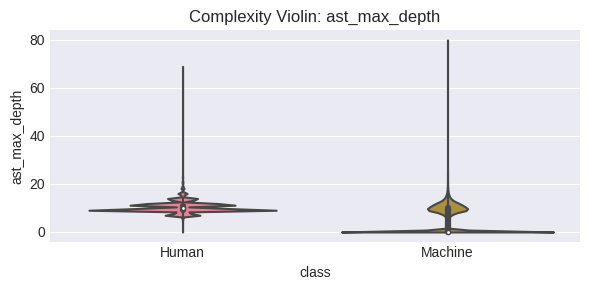

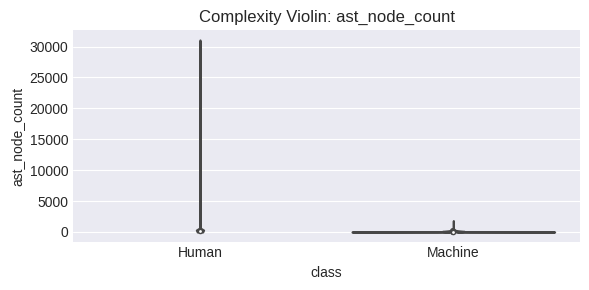

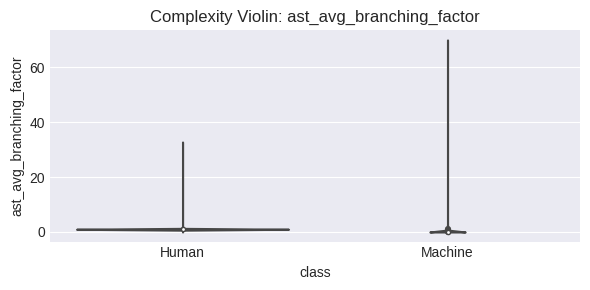

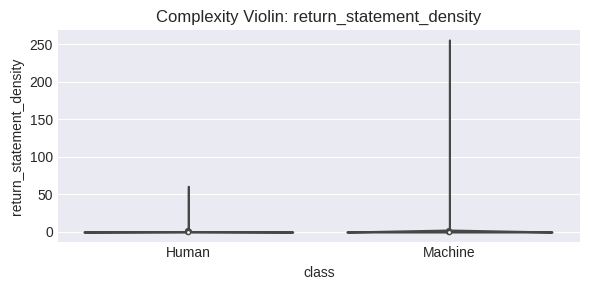

In [10]:
def plot_violin(df, features, title_prefix=""):
    for feat in features:
        plt.figure(figsize=(6,3))
        sns.violinplot(data=df, x='class', y=feat, cut=0)
        plt.title(f"{title_prefix} Violin: {feat}")
        plt.tight_layout()
        plt.show()

df['class'] = df['label'].map({0: "Human", 1: "Machine"})
plot_violin(df, FEATURE_GROUPS["structure"], "Complexity")


In [ ]:
def plot_violin(df, features, title_prefix=""):
    for feat in features:
        plt.figure(figsize=(6,3))
        sns.violinplot(data=df, x='class', y=feat, cut=0)
        plt.title(f"{title_prefix} Violin: {feat}")
        plt.tight_layout()
        plt.show()
plot_violin(df, FEATURE_GROUPS["halstead_info"], "Halstead Info")


**Ridge Plots**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

def ridgeline(df, feature, group='class'):
    groups = df[group].unique()
    plt.figure(figsize=(10, len(groups) * 1.5))

    for i, g in enumerate(groups):
        vals = df[df[group] == g][feature].replace([np.inf, -np.inf], np.nan).dropna()
        arr = vals.to_numpy(dtype=float)

        # Handle constant arrays (KDE fails)
        if arr.size == 0 or np.all(arr == arr[0]):
            arr = arr + np.random.normal(scale=1e-6, size=arr.shape)

        kde = gaussian_kde(arr, bw_method='silverman')
        xs = np.linspace(0, 150, 300)  # Fixed scale: 0 to 150
        ys = kde(xs)

        plt.fill_between(xs, ys + i, i, alpha=0.6)
        plt.text(xs.min(), i, g, va='center')

        # Optional: add mean line
        mean_val = np.mean(arr)
        if 0 <= mean_val <= 150:
            plt.axvline(mean_val, ymin=i/len(groups), ymax=(i+1)/len(groups), color='black', linestyle='--', alpha=0.3)

    plt.title(f"Ridgeline: {feature} across {group}")
    plt.xlim(0, 150)
    plt.yticks([])
    plt.tight_layout()
    plt.show()


ridgeline(df.sample(200000), "perplexity_score")


**ECDF PLOTS (Human vs Machine)**

In [ ]:
def ecdf_plot(df, feature):
    plt.figure(figsize=(6,3))
    for cls in ["Human", "Machine"]:
        vals = df[df['class']==cls][feature].dropna()
        xs = np.sort(vals)
        ys = np.arange(1, len(xs)+1) / len(xs)
        plt.plot(xs, ys, label=cls)

    plt.title(f"ECDF: {feature}")
    plt.legend()
    plt.tight_layout()
    plt.show()
ecdf_plot(df, "ast_max_depth")


**SCATTER + MARGINAL HISTOGRAM**

In [ ]:
def scatter_marginal(df, x, y):
    g = sns.JointGrid(data=df, x=x, y=y, hue="class")
    g.plot_joint(sns.scatterplot, alpha=0.3)
    g.plot_marginals(sns.histplot, kde=True, alpha=0.5)
    plt.suptitle(f"Scatter + Marginals: {x} vs {y}")
    plt.show()

scatter_marginal(df, "cyclomatic_complexity", "loc_total")


**2D DENSITY CONTOUR PLOT**

In [ ]:
def density_contour(df, x, y):
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=x, y=y, hue="class", fill=False, levels=7)
    plt.title(f"2D Density: {x} vs {y}")
    plt.ylim(0,500)
    plt.xlim(0,15)
    plt.tight_layout()
    plt.show()

density_contour(df.sample(2000), "token_entropy", "halstead_difficulty")

# SELECTED FRATURES

In [6]:
FINAL_FEATURES = [  
"ast_max_depth",
"ast_node_count",
"comment_ratio",
    
"loc_blank",
"ast_node_entropy",
"ast_avg_branching_factor",
    "snake_case_ratio",
    "loc_comments",
    "avg_identifier_length",
    "control_flow_ratio",
    "hapax_legomena_count",
    "unique_identifier_ratio",
    "cyclomatic_complexity",
    "avg_line_length",
     "halstead_volume",
    # "cognitive_complexity"
]
print(len(FINAL_FEATURES))

15


In [ ]:
from sklearn.manifold import TSNE
sampledf = df.sample(100000)
sampledf = testdf
# Step 1: Replace inf/-inf with NaN, then drop or fill
X_raw = sampledf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)

# Count how many infs were present originally
inf_count = np.isinf(sampledf[FINAL_FEATURES].to_numpy()).sum()

# Step 2: Fill NaNs with 0 (or you could drop rows if preferred)
X_clean = X_raw.fillna(X_raw.mean())

# Step 3: Scale
X = StandardScaler().fit_transform(X_clean)

# ---- t-SNE ----
tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto')
coords = tsne.fit_transform(X)
sampledf["tsne_x"], sampledf["tsne_y"] = coords[:,0], coords[:,1]

plt.figure(figsize=(7,5))
sns.scatterplot(data=sampledf, x='tsne_x', y='tsne_y', hue='class', s=5)
plt.title("t-SNE Projection")
plt.show()
print(f"Number of infinity values omitted: {inf_count}")

In [ ]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import umap

# Your existing data preparation code
sampledf = df.copy()
sampledf = testdf
# Step 1: Replace inf/-inf with NaN, then drop or fill
X_raw = sampledf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)

# Count how many infs were present originally
inf_count = np.isinf(sampledf[FINAL_FEATURES].to_numpy()).sum()

# Step 2: Fill NaNs with 0 (or you could drop rows if preferred)
X_clean = X_raw.fillna(0)

# Step 3: Scale
X = StandardScaler().fit_transform(X_clean)

# Get class labels
y = sampledf['class'].values
class_names = sampledf['class'].unique()

# # ---- UMAP ----
print("Generating UMAP...")
u = umap.UMAP(n_neighbors=30, min_dist=0.1).fit_transform(X)
sampledf["umap_x"], sampledf["umap_y"] = u[:,0], u[:,1]

# ---- PCA ----
print("Performing PCA...")
pca = PCA()
X_pca = pca.fit_transform(X)

# Store PCA components
sampledf["pca_x"], sampledf["pca_y"] = X_pca[:, 0], X_pca[:, 1]

# ---- LDA ----
print("Performing LDA...")
# For binary classification, LDA gives 1 component (n_classes - 1)
lda = LinearDiscriminantAnalysis()
try:
    X_lda = lda.fit_transform(X, y)
    
    # For binary classification, we get 1 component
    if X_lda.shape[1] == 1:
        # Create a 2D visualization by adding small random noise on y-axis
        np.random.seed(42)
        sampledf["lda_x"] = X_lda[:, 0]
        sampledf["lda_y"] = np.random.normal(0, 0.01, size=len(X_lda))
    else:
        # For multiclass with more than 2 classes
        sampledf["lda_x"], sampledf["lda_y"] = X_lda[:, 0], X_lda[:, 1]
    
    lda_success = True
except Exception as e:
    print(f"LDA failed: {e}")
    print("This can happen if classes are perfectly separable or covariance issues.")
    lda_success = False

# Create figure - adjust based on LDA success
if lda_success:
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    # Hide the LDA plot if it failed
    axes[1, 1].set_visible(False)

# 1. UMAP Plot
sns.scatterplot(data=sampledf, x='umap_x', y='umap_y', hue='class', s=5, ax=axes[0, 0])
axes[0, 0].set_title("UMAP Projection")
axes[0, 0].set_xlabel("UMAP 1")
axes[0, 0].set_ylabel("UMAP 2")

# 2. PCA Plot (first two components)
sns.scatterplot(data=sampledf, x='pca_x', y='pca_y', hue='class', s=5, ax=axes[0, 1])
axes[0, 1].set_title(f"PCA Projection\nPC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) vs PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0, 1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0, 1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# 3. Scree Plot (Variance Explained)
components = range(1, len(pca.explained_variance_ratio_) + 1)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

axes[1, 0].bar(components[:15], pca.explained_variance_ratio_[:15], alpha=0.6, color='skyblue', label='Individual')
axes[1, 0].plot(components[:15], cumulative_variance[:15], 'ro-', label='Cumulative')
axes[1, 0].set_xlabel('Principal Component')
axes[1, 0].set_ylabel('Explained Variance Ratio')
axes[1, 0].set_title('Scree Plot (First 15 PCs)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Add variance percentages as text on bars for first few PCs
for i, (v, cv) in enumerate(zip(pca.explained_variance_ratio_[:5], cumulative_variance[:5])):
    axes[1, 0].text(i+1, v + 0.01, f'{v*100:.1f}%', ha='center', fontsize=9)
    if i < 4:
        axes[1, 0].text(i+1.3, cv - 0.02, f'{cv*100:.1f}%', ha='left', fontsize=9, color='red')

# 4. LDA Plot
if lda_success:
    if X_lda.shape[1] == 1:
        # 1D LDA - create jitter plot
        ax = axes[1, 1]
        for class_val in class_names:
            class_data = sampledf[sampledf['class'] == class_val]
            ax.scatter(class_data['lda_x'], class_data['lda_y'], 
                      s=10, alpha=0.6, label=class_val)
        ax.set_xlabel('LDA Component 1')
        ax.set_ylabel('Jitter (for visualization)')
        ax.set_title(f'LDA Projection (Binary Classification)\nLDA Accuracy: {lda.score(X, y)*100:.2f}%')
        ax.legend()
        ax.set_ylim(-0.05, 0.05)
        ax.yaxis.set_ticklabels([])  # Hide y-axis labels for jitter
    else:
        # 2D LDA for multiclass
        sns.scatterplot(data=sampledf, x='lda_x', y='lda_y', hue='class', s=5, ax=axes[1, 1])
        axes[1, 1].set_title(f'LDA Projection\nLDA Accuracy: {lda.score(X, y)*100:.2f}%')
        axes[1, 1].set_xlabel('LDA Component 1')
        axes[1, 1].set_ylabel('LDA Component 2')
    
    # Add decision boundary visualization for 1D LDA
    if X_lda.shape[1] == 1:
        # Find the decision boundary (where discriminant function = 0)
        # For binary LDA, the decision boundary is where the posterior probabilities are equal
        x_min, x_max = sampledf['lda_x'].min(), sampledf['lda_x'].max()
        x_range = np.linspace(x_min, x_max, 100).reshape(-1, 1)
        
        # Get predictions and probabilities
        preds = lda.predict(X)
        probs = lda.predict_proba(X)
        
        # Find the decision threshold
        # For LDA with equal priors, the decision boundary is where discriminant scores = 0
        # We can approximate it as the midpoint between class means
        mean_0 = sampledf[sampledf['class'] == class_names[0]]['lda_x'].mean()
        mean_1 = sampledf[sampledf['class'] == class_names[1]]['lda_x'].mean()
        boundary = (mean_0 + mean_1) / 2
        
        axes[1, 1].axvline(x=boundary, color='red', linestyle='--', alpha=0.7, 
                          label=f'Decision boundary\nx = {boundary:.3f}')
        axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Number of infinity values omitted: {inf_count}")
print(f"Total variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Total variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")
print(f"Total variance explained by first 10 PCs: {sum(pca.explained_variance_ratio_[:10])*100:.2f}%")

if lda_success:
    print(f"\nLDA Results:")
    print(f"Training Accuracy: {lda.score(X, y)*100:.2f}%")
    print(f"Number of LDA components: {X_lda.shape[1]}")
    
    # For binary classification, show class separation along LDA axis
    if X_lda.shape[1] == 1:
        print("\nClass separation along LDA axis:")
        for class_val in class_names:
            class_scores = sampledf[sampledf['class'] == class_val]['lda_x']
            print(f"  {class_val}: Mean = {class_scores.mean():.3f}, Std = {class_scores.std():.3f}")
        
        # Calculate Fisher's discriminant ratio
        mean_0 = sampledf[sampledf['class'] == class_names[0]]['lda_x'].mean()
        mean_1 = sampledf[sampledf['class'] == class_names[1]]['lda_x'].mean()
        std_0 = sampledf[sampledf['class'] == class_names[0]]['lda_x'].std()
        std_1 = sampledf[sampledf['class'] == class_names[1]]['lda_x'].std()
         
        # Fisher's linear discriminant ratio
        fisher_ratio = (mean_0 - mean_1)**2 / (std_0**2 + std_1**2)
        print(f"\nFisher's discriminant ratio: {fisher_ratio:.3f}")
        print(f"Interpretation: Higher values indicate better separation")

In [ ]:
df.info()

**CORRELATION DIFFERENCE HEATMAP**

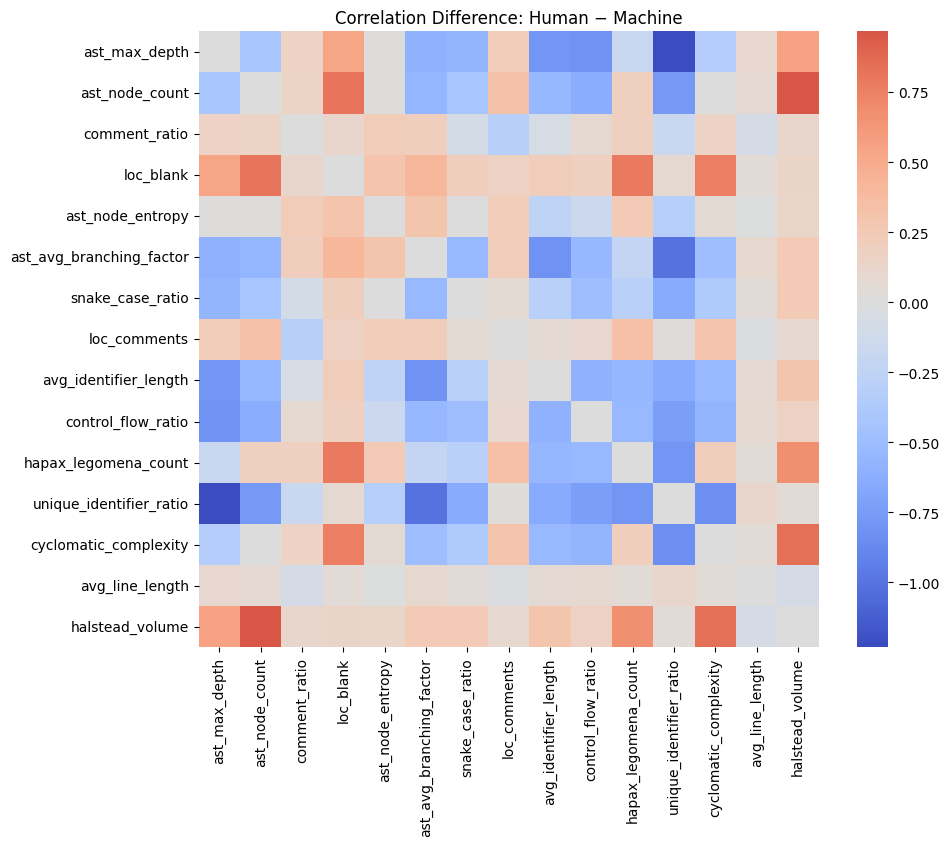

In [15]:
features = FINAL_FEATURES
corr_h = df[df['class']=='Human'][features].corr()
corr_m = df[df['class']=='Machine'][features].corr()
delta = corr_h - corr_m

plt.figure(figsize=(10,8))
sns.heatmap(delta, cmap="coolwarm", center=0)
plt.title("Correlation Difference: Human − Machine")
plt.show()


**GROUPED BAR CHART: AST NODE TYPE FREQUENCY / 100 LINES**

In [ ]:
AST_NODES = ["ast_max_depth","ast_node_count","ast_max_depth","ast_avg_branching_factor","control_flow_ratio", "return_statement_density"]

df_ast = (
    df.groupby("class")[AST_NODES]
    .mean()
    .apply(lambda x: x / (df['loc_total'].mean()/100))  # per 100 LOC
)

df_ast.T.plot(kind='bar', figsize=(8,4))
plt.title("AST Node Frequency per 100 LOC")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Logistic Regression and linear SVM

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import joblib

# --- Configuration ---
RANDOM_STATE = 42
TEST_SIZE = 0.2
EPOCHS = 30
BATCH_SIZE = 1024  # used only for mini-batch partial_fit loop (if desired)

target_col = "label"
sampledf = df.copy()
sampledf =sampledf.sample(100000)
# --- Prepare X and y (re-using your cleaned features) ---
# If you already have X (scaled) from your snippet, you can skip re-scaling here.
# We'll re-create X_scaled to ensure scaler is saved consistently.
X_raw = sampledf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
X_clean = X_raw.fillna(X_raw.mean())
scaler = StandardScaler().fit(X_clean)
X_scaled = scaler.transform(X_clean)

y = sampledf[target_col].values
# Ensure binary labels are 0/1
unique_y = np.unique(y)
if set(unique_y) - {0, 1}:
    # try to map two unique values to 0/1
    if len(unique_y) == 2:
        mapping = {unique_y[0]: 0, unique_y[1]: 1}
        y = np.vectorize(mapping.get)(y)
    else:
        raise ValueError(f"Target column has more than 2 unique values: {unique_y}")

# --- Train / validation split ---
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# --- Helper: epoch-wise training using partial_fit (SGDClassifier) ---
def train_with_epochs(clf, X_tr, y_tr, X_va, y_va, epochs=EPOCHS):
    classes = np.unique(y_tr)
    train_acc = []
    val_acc = []
    n_samples = X_tr.shape[0]
    # We'll do simple full-pass updates each epoch (shuffling each epoch)
    for ep in range(epochs):
        # shuffle
        idx = np.random.RandomState(RANDOM_STATE + ep).permutation(n_samples)
        X_shuf = X_tr[idx]
        y_shuf = y_tr[idx]
        # partial_fit on full data in one call (you can mini-batch if desired)
        clf.partial_fit(X_shuf, y_shuf, classes=classes)
        # record accuracies
        y_tr_pred = clf.predict(X_tr)
        y_va_pred = clf.predict(X_va)
        train_acc.append(accuracy_score(y_tr, y_tr_pred))
        val_acc.append(accuracy_score(y_va, y_va_pred))
    return train_acc, val_acc

# --- SGD-based Logistic (log loss) and Linear SVM (hinge) for curves ---
sgd_log = SGDClassifier(loss="log", max_iter=1, tol=None, warm_start=True, random_state=RANDOM_STATE)
sgd_svm = SGDClassifier(loss="hinge", max_iter=1, tol=None, warm_start=True, random_state=RANDOM_STATE)

print("Training SGD (logistic) for epoch-wise curves...")
log_train_acc, log_val_acc = train_with_epochs(sgd_log, X_train, y_train, X_val, y_val, epochs=EPOCHS)

print("Training SGD (linear SVM) for epoch-wise curves...")
svm_train_acc, svm_val_acc = train_with_epochs(sgd_svm, X_train, y_train, X_val, y_val, epochs=EPOCHS)

# --- Fit final models on the full training set ---
print("Fitting final LogisticRegression and LinearSVC on training data...")
final_log = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=RANDOM_STATE)
final_log.fit(X_train, y_train)

final_svc = LinearSVC(max_iter=2000, random_state=RANDOM_STATE)
final_svc.fit(X_train, y_train)

# Evaluate final models on validation set
log_val_pred = final_log.predict(X_val)
svc_val_pred = final_svc.predict(X_val)
log_val_acc_final = accuracy_score(y_val, log_val_pred)
svc_val_acc_final = accuracy_score(y_val, svc_val_pred)

print(f"Final LogisticRegression validation accuracy: {log_val_acc_final:.4f}")
print(f"Final LinearSVC validation accuracy: {svc_val_acc_final:.4f}")

# --- Save scaler and final models for future use ---
# Adjust filenames as you prefer
joblib.dump(scaler, "scaler.joblib")
joblib.dump(final_log, "logistic_model.joblib")
joblib.dump(final_svc, "linear_svc_model.joblib")

# --- Plot training/validation accuracy curves ---
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic curves
axes[0].plot(range(1, EPOCHS + 1), log_train_acc, label="Train acc", marker='o')
axes[0].plot(range(1, EPOCHS + 1), log_val_acc, label="Val acc", marker='o')
axes[0].set_title("SGD Logistic (epoch-wise)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# SVM curves
axes[1].plot(range(1, EPOCHS + 1), svm_train_acc, label="Train acc", marker='o')
axes[1].plot(range(1, EPOCHS + 1), svm_val_acc, label="Val acc", marker='o')
axes[1].set_title("SGD Linear SVM (epoch-wise)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# --- Optional: single-figure summary of final model accuracies ---
plt.figure(figsize=(6,4))
models = ["LogisticRegression", "LinearSVC"]
accs = [log_val_acc_final, svc_val_acc_final]
sns.barplot(x=models, y=accs)
plt.ylim(0,1)
plt.title("Final validation accuracies")
plt.ylabel("Accuracy")
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.show()

# --- How to load models later ---
# scaler = joblib.load("scaler.joblib")
# log_model = joblib.load("logistic_model.joblib")
# svc_model = joblib.load("linear_svc_model.joblib")


Training SGD (logistic) for epoch-wise curves...
Training SGD (linear SVM) for epoch-wise curves...
Fitting final LogisticRegression and LinearSVC on training data...


KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
# 1. Prepare the data
print("Preparing data...")
sampledf = df.copy()
sampledf = sampledf.sample(100000)
testdf = pd.read_parquet("/kaggle/working/test_features_all.parquet")
#valdf = pd.read_parquet("/kaggle/working/validation_features_all.parquet")
# Handle infinite values
X_raw = sampledf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
#X_val_raw = valdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
XT_raw = testdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
inf_count = np.isinf(sampledf[FINAL_FEATURES].to_numpy()).sum()

# Fill NaNs
X_clean = X_raw.fillna(X_raw.mean())
#X_val_clean = X_val_raw.fillna(0)
XT_clean = XT_raw.fillna(0)
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
#X_val = scaler.fit_transform(X_val_clean)
XT_scaled = scaler.transform(XT_clean)
# Target variable
y = sampledf['label'].values
#y_val = valdf['label'].values
yt = testdf['label'].values

# Split the data
X_train, X_test, y_train, y_test = X_scaled,XT_scaled,y,yt

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Number of infinity values omitted: {inf_count}")
print(f"Class distribution in training set: {np.bincount(y_train)}")
print(f"Class distribution in testing set: {np.bincount(y_test)}")

# 2. Logistic Regression
print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)

logreg = LogisticRegression(
    penalty="l1",                # Regularization
    C=2.636650898730358,         # Inverse regularization strength
    solver="liblinear",
    max_iter=2000,
    random_state=42
)

# Show warnings explicitly\
logreg.fit(X_train, y_train)

# Predictions
y_pred_logreg = logreg.predict(X_test)
y_pred_proba_logreg = logreg.predict_proba(X_test)[:, 1]

# Cross-validation
cv_scores = cross_val_score(logreg, X_scaled, y, cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42))
print(f"Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# 3. Linear SVM
print("\n" + "="*50)
print("LINEAR SVM")
print("="*50)

# Train Linear SVM
svm_linear = LinearSVC(
    penalty='l2',
    C=1.0,
    loss='squared_hinge',
    max_iter=25,
    dual = False,
    random_state=42
)

svm_linear.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_linear.predict(X_test)

# For SVM, we need to get decision function scores for ROC
if hasattr(svm_linear, 'decision_function'):
    y_scores_svm = svm_linear.decision_function(X_test)
else:
    # Fallback: use predict for scores
    y_scores_svm = svm_linear.predict(X_test)

# Cross-validation for SVM
cv_scores_svm = cross_val_score(svm_linear, X_scaled, y, cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42))
print(f"Cross-validation accuracy: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std() * 2:.4f})")

# 4. Evaluation Metrics
def evaluate_model(y_true, y_pred, y_scores, model_name):
    """Comprehensive evaluation function"""
    print(f"\n{model_name} Performance:")
    print("-" * 30)
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary')
    recall = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # ROC-AUC if we have probability scores
    if y_scores is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_scores)
            print(f"ROC-AUC:   {roc_auc:.4f}")
        except:
            print("ROC-AUC:   Not available")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"[[TN={cm[0,0]}  FP={cm[0,1]}]")
    print(f" [FN={cm[1,0]}  TP={cm[1,1]}]]")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cm': cm
    }

# Evaluate both models
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

results_logreg = evaluate_model(y_test, y_pred_logreg, y_pred_proba_logreg, "Logistic Regression")
results_svm = evaluate_model(y_test, y_pred_svm, y_scores_svm, "Linear SVM")

# 5. Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 5.1 ROC Curves
ax = axes[0, 0]
if y_pred_proba_logreg is not None:
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_logreg)
    roc_auc_lr = auc(fpr_lr, tpr_lr)
    ax.plot(fpr_lr, tpr_lr, color='blue', lw=2, 
            label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

if y_scores_svm is not None:
    try:
        fpr_svm, tpr_svm, _ = roc_curve(y_test, y_scores_svm)
        roc_auc_svm = auc(fpr_svm, tpr_svm)
        ax.plot(fpr_svm, tpr_svm, color='red', lw=2, 
                label=f'Linear SVM (AUC = {roc_auc_svm:.3f})')
    except:
        pass

ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# 5.2 Confusion Matrices
# Logistic Regression Confusion Matrix
ax = axes[0, 1]
sns.heatmap(results_logreg['cm'], annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Logistic Regression Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticklabels(['Class 0', 'Class 1'])
ax.set_yticklabels(['Class 0', 'Class 1'])

# SVM Confusion Matrix
ax = axes[0, 2]
sns.heatmap(results_svm['cm'], annot=True, fmt='d', cmap='Reds', ax=ax)
ax.set_title('Linear SVM Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticklabels(['Class 0', 'Class 1'])
ax.set_yticklabels(['Class 0', 'Class 1'])

# 5.3 Feature Importance (Logistic Regression)
ax = axes[1, 0]
if hasattr(logreg, 'coef_'):
    feature_importance = pd.DataFrame({
        'feature': FINAL_FEATURES,
        'importance': np.abs(logreg.coef_[0])
    }).sort_values('importance', ascending=False).head(10)
    
    ax.barh(range(len(feature_importance)), feature_importance['importance'])
    ax.set_yticks(range(len(feature_importance)))
    ax.set_yticklabels(feature_importance['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Absolute Coefficient Value')
    ax.set_title('Top 10 Features (Logistic Regression)')
    ax.grid(True, alpha=0.3, axis='x')

# 5.4 Model Comparison Bar Plot
ax = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
logreg_metrics = [results_logreg['accuracy'], results_logreg['precision'], 
                  results_logreg['recall'], results_logreg['f1']]
svm_metrics = [results_svm['accuracy'], results_svm['precision'], 
               results_svm['recall'], results_svm['f1']]

x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, logreg_metrics, width, label='Logistic Regression', color='blue', alpha=0.7)
ax.bar(x + width/2, svm_metrics, width, label='Linear SVM', color='red', alpha=0.7)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 5.5 Learning Curves (Simplified)
ax = axes[1, 2]
# Train on increasing data sizes
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores_logreg = []
test_scores_logreg = []

for size in train_sizes:
    n_samples = int(size * len(X_train))
    X_subset = X_train[:n_samples]
    y_subset = y_train[:n_samples]
    
    logreg_temp = LogisticRegression(max_iter=1000, random_state=42)
    logreg_temp.fit(X_subset, y_subset)
    
    train_scores_logreg.append(logreg_temp.score(X_subset, y_subset))
    test_scores_logreg.append(logreg_temp.score(X_test, y_test))

ax.plot(train_sizes * 100, train_scores_logreg, 'o-', color='blue', label='LogReg Train')
ax.plot(train_sizes * 100, test_scores_logreg, 'o-', color='red', label='LogReg Test')
ax.set_xlabel('Training Set Size (%)')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve (Logistic Regression)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Detailed Summary
print("\n" + "="*50)
print("SUMMARY")
print("="*50)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean', 'CV Std'],
    'Logistic Regression': [
        results_logreg['accuracy'],
        results_logreg['precision'],
        results_logreg['recall'],
        results_logreg['f1'],
        cv_scores.mean(),
        cv_scores.std()
    ],
    'Linear SVM': [
        results_svm['accuracy'],
        results_svm['precision'],
        results_svm['recall'],
        results_svm['f1'],
        cv_scores_svm.mean(),
        cv_scores_svm.std()
    ]
})

print(comparison_df.to_string(index=False))

# Determine which model performed better
if results_logreg['accuracy'] > results_svm['accuracy']:
    print(f"\n✓ Logistic Regression performed better by {results_logreg['accuracy'] - results_svm['accuracy']:.4f} accuracy")
    best_model = logreg
    best_model_name = "Logistic Regression"
else:
    print(f"\n✓ Linear SVM performed better by {results_svm['accuracy'] - results_logreg['accuracy']:.4f} accuracy")
    best_model = svm_linear
    best_model_name = "Linear SVM"

print(f"\nBest Model: {best_model_name}")
print(f"Test Accuracy: {max(results_logreg['accuracy'], results_svm['accuracy']):.4f}")

# 7. Optional: Save models
print("\nSaving models...")
import joblib
joblib.dump(logreg, 'logistic_regression_model.pkl')
joblib.dump(svm_linear, 'linear_svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Models saved as 'logistic_regression_model.pkl', 'linear_svm_model.pkl', and 'scaler.pkl'")

In [ ]:
print(logreg.n_iter_)

print(svm_linear.n_iter_)

# Decision Trees

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)
# Training function for Decision Trees with different configurations
def train_decision_trees(X_train, y_train, X_test, y_test):
    """
    Train multiple Decision Tree models with different configurations
    """
    models = {}
    
    # Define different Decision Tree configurations
    dt_configs = {
        'dt_default': DecisionTreeClassifier(random_state=42),
        'dt_gini_depth5': DecisionTreeClassifier(
            criterion='gini',
            max_depth=5,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        ),
        'dt_entropy_depth10': DecisionTreeClassifier(
            criterion='entropy',
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42
        ),
        'dt_pruned': DecisionTreeClassifier(
            criterion='gini',
            max_depth=None,  # Let tree grow
            min_samples_split=2,
            min_samples_leaf=1,
            max_features='sqrt',  # Consider sqrt of features at each split
            ccp_alpha=0.01,  # Cost complexity pruning
            random_state=42
        )
    }
    
    # Train each model
    for model_name, model in dt_configs.items():
        print(f"Training {model_name}...")
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_scores = model.predict_proba(X_test)[:, 1]
        # Assuming y_pred_proba_logreg is already defined
        df = pd.DataFrame({'y_pred_proba': y_scores})
        
        # Save to CSV
        df.to_csv(f'y_score_{model_name}.csv', index=False)
        # Evaluate
        evaluate_model(y_test, y_pred, y_scores, model_name)
        
        # Store model
        models[model_name] = model
        
        print("-" * 50)
    
    return models

# Evaluation function
def evaluate_model(y_true, y_pred, y_scores, model_name):
    """
    Comprehensive evaluation of classification model
    """
    print(f"\n{'='*60}")
    print(f"EVALUATION RESULTS FOR: {model_name}")
    print(f"{'='*60}")
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # ROC-AUC (if binary classification)
    if len(np.unique(y_true)) == 2:
        try:
            roc_auc = roc_auc_score(y_true, y_scores)
            print(f"ROC-AUC Score: {roc_auc:.4f}")
        except:
            roc_auc = None
            print("Could not calculate ROC-AUC score")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Print metrics
    print(f"\nBasic Metrics:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Print confusion matrix
    print(f"\nConfusion Matrix:")
    print(f"True Negatives: {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives: {cm[1,1]}")
    
    # Classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1']))
    
    # Visualizations
    plot_evaluation_metrics(y_true, y_pred, y_scores, model_name, cm)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc if 'roc_auc' in locals() else None,
        'confusion_matrix': cm
    }

def plot_evaluation_metrics(y_true, y_pred, y_scores, model_name, cm):
    """
    Plot evaluation metrics
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 12))
    fig.suptitle(f'Model Evaluation: {model_name}', fontsize=16, fontweight='bold')
    
    # 1. Confusion Matrix Heatmap
    ax1 = axes[0, 0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'], ax=ax1)
    ax1.set_title('Confusion Matrix')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # 2. ROC Curve (if binary classification)
    ax2 = axes[0, 1]
    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        
        ax2.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.2f})')
        ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax2.set_xlim([0.0, 1.0])
        ax2.set_ylim([0.0, 1.05])
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('ROC Curve')
        ax2.legend(loc="lower right")
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'ROC Curve only for binary classification',
                horizontalalignment='center', verticalalignment='center',
                transform=ax2.transAxes)
        ax2.set_title('ROC Curve (Not available)')
    
    # 3. Metrics Bar Chart
    ax3 = axes[1, 0]
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]
    
    bars = ax3.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
    ax3.set_ylim([0, 1])
    ax3.set_title('Performance Metrics')
    ax3.set_ylabel('Score')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.3f}', ha='center', va='bottom')
    
    # 4. Feature Importance (if using tree models)
    ax4 = axes[1, 1]
    ax4.text(0.5, 0.5, 'Feature importance would be shown here\nfor tree-based models',
            horizontalalignment='center', verticalalignment='center',
            transform=ax4.transAxes)
    ax4.set_title('Feature Importance')
    
    plt.tight_layout()
    plt.show()

# Main training and evaluation
def main_training_pipeline():
    """
    Complete training and evaluation pipeline
    """
    sampledf = df.copy()
    testdf = pd.read_parquet("/kaggle/working/sampletest_features_all.parquet")
    #valdf = pd.read_parquet("/kaggle/working/validation_features_all.parquet")
    # Handle infinite values
    X_raw = sampledf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    #X_val_raw = valdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    XT_raw = testdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    inf_count = np.isinf(sampledf[FINAL_FEATURES].to_numpy()).sum()
    
    # Fill NaNs
    X_clean = X_raw.fillna(X_raw.mean() )
    #X_val_clean = X_val_raw.fillna(0)
    XT_clean = XT_raw.fillna(0)
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    #X_val = scaler.fit_transform(X_val_clean)
    XT_scaled = scaler.transform(XT_clean)
    # Target variable
    y = sampledf['label'].values
    #y_val = valdf['label'].values
    yt = testdf['label'].values
    
    # Split the data
    X_train, X_test, y_train, y_test = X_scaled,XT_scaled,y,yt

    print("Starting Decision Tree Training Pipeline...")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    print(f"Number of features: {X_train.shape[1]}")
    print(f"Class distribution in training: {np.bincount(y_train)}")
    print(f"Class distribution in test: {np.bincount(y_test)}")
    
    # Train Decision Trees
    print("\n" + "="*60)
    print("TRAINING DECISION TREES")
    print("="*60)
    dt_models = train_decision_trees(X_train, y_train, X_test, y_test)
    
    # You can also add model saving functionality
    # save_models(dt_models)
    
    return dt_models


Starting Decision Tree Training Pipeline...
Training samples: 500000
Test samples: 1000
Number of features: 15
Class distribution in training: [238475 261525]
Class distribution in test: [777 223]

TRAINING DECISION TREES
Training dt_default...

EVALUATION RESULTS FOR: dt_default
ROC-AUC Score: 0.6568

Basic Metrics:
Accuracy:  0.5760
Precision: 0.3202
Recall:    0.8027
F1-Score:  0.4578

Confusion Matrix:
True Negatives: 397
False Positives: 380
False Negatives: 44
True Positives: 179

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.90      0.51      0.65       777
     Class 1       0.32      0.80      0.46       223

    accuracy                           0.58      1000
   macro avg       0.61      0.66      0.55      1000
weighted avg       0.77      0.58      0.61      1000



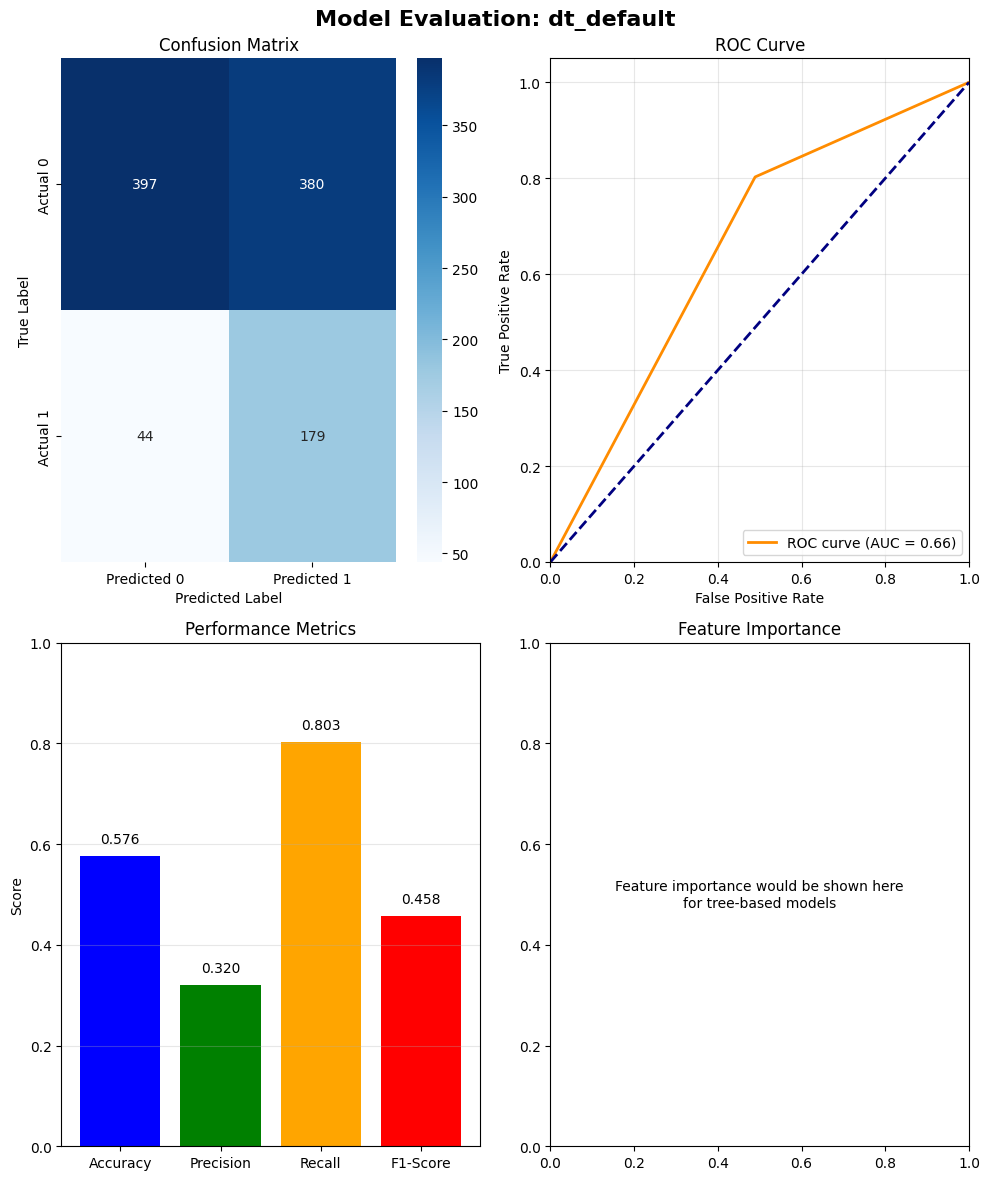

--------------------------------------------------
Training dt_gini_depth5...

EVALUATION RESULTS FOR: dt_gini_depth5
ROC-AUC Score: 0.7483

Basic Metrics:
Accuracy:  0.7130
Precision: 0.3994
Recall:    0.5695
F1-Score:  0.4695

Confusion Matrix:
True Negatives: 586
False Positives: 191
False Negatives: 96
True Positives: 127

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.86      0.75      0.80       777
     Class 1       0.40      0.57      0.47       223

    accuracy                           0.71      1000
   macro avg       0.63      0.66      0.64      1000
weighted avg       0.76      0.71      0.73      1000



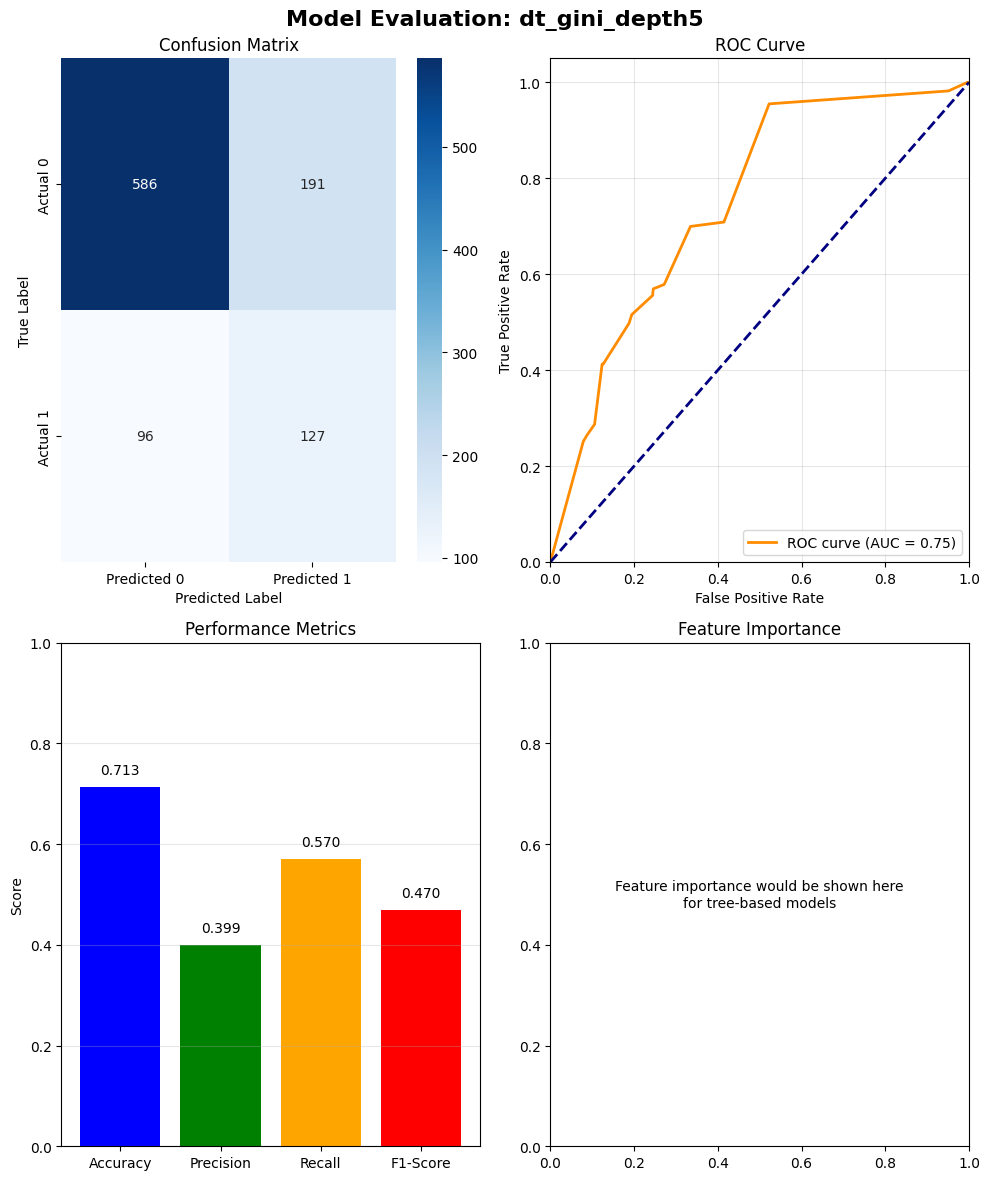

--------------------------------------------------
Training dt_entropy_depth10...

EVALUATION RESULTS FOR: dt_entropy_depth10
ROC-AUC Score: 0.7532

Basic Metrics:
Accuracy:  0.6800
Precision: 0.3859
Recall:    0.7354
F1-Score:  0.5062

Confusion Matrix:
True Negatives: 516
False Positives: 261
False Negatives: 59
True Positives: 164

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.90      0.66      0.76       777
     Class 1       0.39      0.74      0.51       223

    accuracy                           0.68      1000
   macro avg       0.64      0.70      0.63      1000
weighted avg       0.78      0.68      0.71      1000



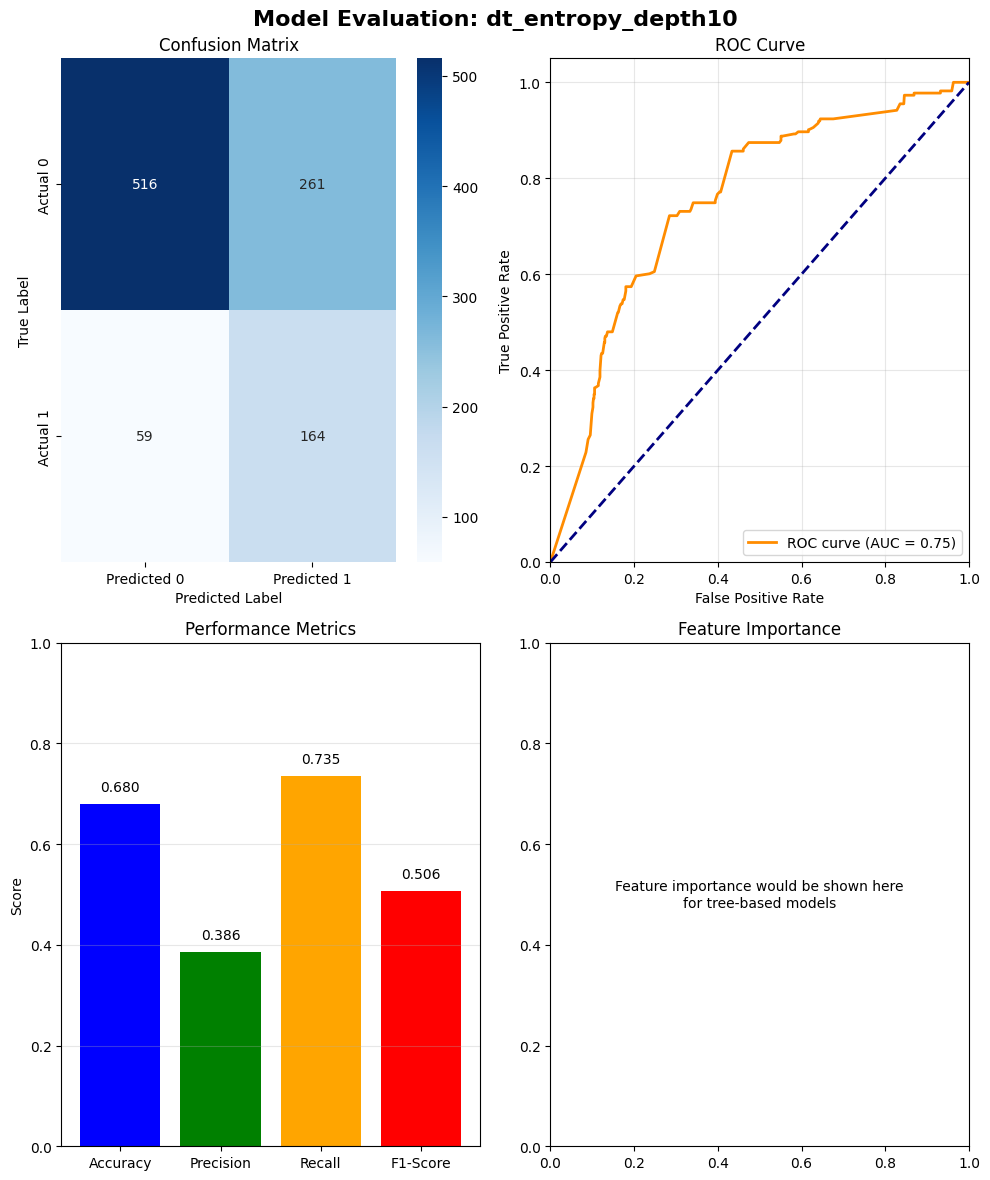

--------------------------------------------------
Training dt_pruned...

EVALUATION RESULTS FOR: dt_pruned
ROC-AUC Score: 0.7313

Basic Metrics:
Accuracy:  0.7410
Precision: 0.4526
Recall:    0.7713
F1-Score:  0.5705

Confusion Matrix:
True Negatives: 569
False Positives: 208
False Negatives: 51
True Positives: 172

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.92      0.73      0.81       777
     Class 1       0.45      0.77      0.57       223

    accuracy                           0.74      1000
   macro avg       0.69      0.75      0.69      1000
weighted avg       0.81      0.74      0.76      1000



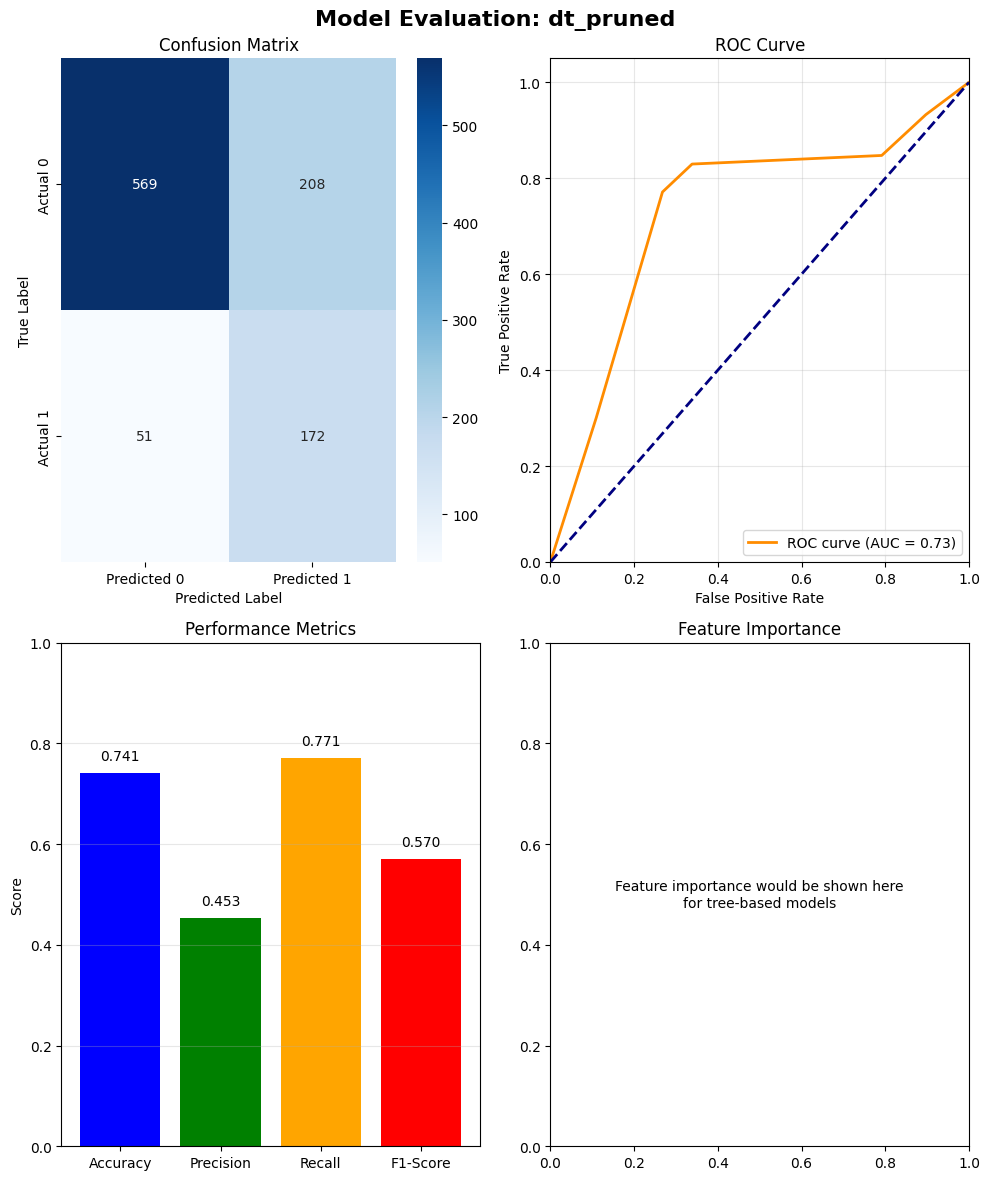

--------------------------------------------------
Saved dt_default to /kaggle/working/models/dt_default.pkl
Saved dt_gini_depth5 to /kaggle/working/models/dt_gini_depth5.pkl
Saved dt_entropy_depth10 to /kaggle/working/models/dt_entropy_depth10.pkl
Saved dt_pruned to /kaggle/working/models/dt_pruned.pkl
Performing cross-validation...
Cross-validation results (5-fold):
Individual scores: [0.88581577 0.86719997 0.86996267 0.88577533 0.87150871]
Mean f1: 0.8761
Std deviation: 0.0081

Training on full dataset...


KeyboardInterrupt: 

In [14]:
# Function to save trained models
import joblib
import pickle

def save_models(models_dict, path="models/"):
    """Save trained models to disk"""
    import os
    os.makedirs(path, exist_ok=True)
    
    for name, model in models_dict.items():
        filename = f"{path}{name}.pkl"
        joblib.dump(model, filename)
        print(f"Saved {name} to {filename}")

# Function to load models
def load_models(path="models/"):
    """Load saved models from disk"""
    import glob
    models = {}
    for filepath in glob.glob(f"{path}*.pkl"):
        name = filepath.split("/")[-1].replace(".pkl", "")
        models[name] = joblib.load(filepath)
        print(f"Loaded {name}")
    return models

# Function for cross-validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

def cross_validate_model(model, X, y, cv=5):
    """Perform cross-validation"""
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    # Cross-validate accuracy
    cv_scores = cross_val_score(model, X, y, 
                                cv=cv_strategy, 
                                scoring='f1')
    
    print(f"Cross-validation results ({cv}-fold):")
    print(f"Individual scores: {cv_scores}")
    print(f"Mean f1: {cv_scores.mean():.4f}")
    print(f"Std deviation: {cv_scores.std():.4f}")
    
    return cv_scores

# Enhanced evaluation with cross-validation
def enhanced_training(X_train, y_train, X_test, y_test):
    """
    Enhanced training with cross-validation
    """
    # Train a Decision Tree with optimal parameters (you can tune these)
    best_dt = DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        criterion='gini',
        random_state=42
    )
    
    # Cross-validation on training data
    print("Performing cross-validation...")
    cv_scores = cross_validate_model(best_dt, X_train, y_train, cv=5)
    
    # Train on full training data
    print("\nTraining on full dataset...")
    best_dt.fit(X_train, y_train)
    
    # Evaluate on test set
    y_pred = best_dt.predict(X_test)
    y_scores = best_dt.predict_proba(X_test)[:, 1]
    
    results = evaluate_model(y_test, y_pred, y_scores, "Optimized Decision Tree")
    
    # Feature importance
    if hasattr(best_dt, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': FINAL_FEATURES,
            'importance': best_dt.feature_importances_
        }).sort_values('importance', ascending=False)
        
        print("\nTop 10 Most Important Features:")
        print(feature_importance.head(10))
        
        # Plot feature importance
        plt.figure(figsize=(10, 6))
        plt.barh(feature_importance.head(20)['feature'][::-1], 
                feature_importance.head(20)['importance'][::-1])
        plt.xlabel('Importance')
        plt.title('Top 20 Feature Importances')
        plt.tight_layout()
        plt.show()
    
    return best_dt, results
    
# 1. Basic training and evaluation
sampledf = df.copy()
testdf = pd.read_parquet("/kaggle/working/validation_features_all.parquet")
#valdf = pd.read_parquet("/kaggle/working/validation_features_all.parquet")
# Handle infinite values
X_raw = sampledf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
#X_val_raw = valdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
XT_raw = testdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
inf_count = np.isinf(sampledf[FINAL_FEATURES].to_numpy()).sum()

# Fill NaNs
X_clean = X_raw.fillna(X_raw.mean())
#X_val_clean = X_val_raw.fillna(0)
XT_clean = XT_raw.fillna(0)
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
#X_val = scaler.fit_transform(X_val_clean)
XT_scaled = scaler.transform(XT_clean)
# Target variable
y = sampledf['label'].values
#y_val = valdf['label'].values
yt = testdf['label'].values

# Split the data
X_train, X_test, y_train, y_test = X_scaled,XT_scaled,y,yt
trained_models = main_training_pipeline()

# 2. Get predictions from a specific model
best_model = trained_models['dt_pruned']  # or whichever performed best
predictions = best_model.predict(XT_scaled)
probabilities = best_model.predict_proba(XT_scaled)

# 3. Save models for later use
save_models(trained_models, path="/kaggle/working/models/")

# 4. Enhanced training with cross-validation
best_model, results = enhanced_training(X_train, y_train, X_test, y_test)
joblib.dump(best_model, "/kaggle/working/models/dt_optimized.pkl")

**Random Forest**

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import joblib
import time
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

# Training function for Random Forest with different configurations
def train_random_forests(X_train, y_train, X_test, y_test):
    """
    Train multiple Random Forest models with different configurations
    """
    models = {}
    results = {}
    
    # Define different Random Forest configurations
    rf_configs = { 
        'rf_large' :  RandomForestClassifier(
                        n_estimators=600,
                        max_depth=10,
                        min_samples_leaf=5,
                        max_features="sqrt",
                        n_jobs=-1,
                        random_state=42
                    ),

        
        'rf_tuned' : RandomForestClassifier(
                    n_estimators=200,
                    min_samples_split=15,
                    min_samples_leaf=15,
                    max_features=0.5,  # Use 50% of features
                    bootstrap=True,
                    max_depth=8,
                    random_state=42,
                    n_jobs=-1
                ),
        'rf_basic': RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features='sqrt',
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ),

        
        'rf_fast': RandomForestClassifier(
            n_estimators=50,
            max_depth=8,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features=0.5,  # Use 50% of features
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        )
    }
    
    print("Training Random Forest models...")
    print("="*60)
    
    # Train each model
    for model_name, model in rf_configs.items():
        print(f"\nTraining {model_name}...")
        start_time = time.time()
        
        # Train model
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_scores = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        
        # Evaluate
        eval_results = evaluate_model(y_test, y_pred, y_scores, model_name)
        eval_results['training_time'] = training_time
        
        # Store results
        results[model_name] = eval_results
        models[model_name] = model
        
        # Print model info
        print(f"Training time: {training_time:.2f} seconds")
        print(f"Number of trees: {model.n_estimators}")
        print(f"Max depth: {model.max_depth}")
        print("-" * 50)
    
    return models, results

# Hyperparameter tuning for Random Forest
def tune_random_forest(X_train, y_train, X_test, y_test, method='random', cv_folds=3):
    """
    Perform hyperparameter tuning for Random Forest
    """
    print("\n" + "="*60)
    print("RANDOM FOREST HYPERPARAMETER TUNING")
    print("="*60)
    
    # Base model
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    
    # Define parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
        'bootstrap': [True, False],
        'class_weight': [None, 'balanced']
    }
    
    # For RandomizedSearchCV - broader ranges
    param_distributions = {
        'n_estimators': randint(50, 500),
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': uniform(0.1, 0.9),
        'bootstrap': [True, False]
    }
    
    if method == 'grid':
        print("Performing Grid Search CV...")
        search = GridSearchCV(
            estimator=rf,
            param_grid=param_grid,
            cv=cv_folds,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1
        )
    else:  # random search
        print("Performing Randomized Search CV...")
        search = RandomizedSearchCV(
            estimator=rf,
            param_distributions=param_distributions,
            n_iter=20,  # Number of parameter settings to sample
            cv=cv_folds,
            scoring='roc_auc',
            random_state=42,
            n_jobs=-1,
            verbose=1
        )
    
    # Perform search
    start_time = time.time()
    search.fit(X_train, y_train)
    tuning_time = time.time() - start_time
    
    print(f"\nTuning completed in {tuning_time:.2f} seconds")
    print(f"Best parameters: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.4f}")
    
    # Train final model with best parameters
    best_rf = search.best_estimator_
    
    # Evaluate on test set
    y_pred = best_rf.predict(X_test)
    y_scores = best_rf.predict_proba(X_test)[:, 1]
    
    results = evaluate_model(y_test, y_pred, y_scores, "Tuned Random Forest")
    results['best_params'] = search.best_params_
    results['tuning_time'] = tuning_time
    
    return best_rf, results, search

# Feature importance analysis
def analyze_feature_importance(model, feature_names, top_n=10):
    """
    Analyze and visualize feature importance
    """
    if hasattr(model, 'feature_importances_'):
        # Get feature importances
        importances = model.feature_importances_
        
        # Create DataFrame
        feature_importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)
        
        print(f"\n{'='*60}")
        print(f"FEATURE IMPORTANCE ANALYSIS (Top {top_n})")
        print(f"{'='*60}")
        print(feature_importance_df.head(top_n).to_string(index=False))
        
        # Plot feature importance
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        # Horizontal bar chart
        top_features = feature_importance_df.head(top_n)
        axes[0].barh(range(len(top_features)), top_features['importance'].values[::-1])
        axes[0].set_yticks(range(len(top_features)))
        axes[0].set_yticklabels(top_features['feature'].values[::-1])
        axes[0].set_xlabel('Importance')
        axes[0].set_title(f'Top {top_n} Feature Importances')
        axes[0].grid(True, alpha=0.3, axis='x')
        
        # Cumulative importance plot
        cumulative_importance = np.cumsum(feature_importance_df['importance'].values)
        axes[1].plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 
                    marker='o', linewidth=2)
        axes[1].axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80% importance')
        axes[1].axhline(y=0.9, color='g', linestyle='--', alpha=0.7, label='90% importance')
        axes[1].set_xlabel('Number of Features')
        axes[1].set_ylabel('Cumulative Importance')
        axes[1].set_title('Cumulative Feature Importance')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Find number of features for 80% and 90% importance
        idx_80 = np.where(cumulative_importance >= 0.8)[0][0] + 1
        idx_90 = np.where(cumulative_importance >= 0.9)[0][0] + 1
        
        print(f"\nFeature Reduction Insights:")
        print(f"Top {idx_80} features explain 80% of importance")
        print(f"Top {idx_90} features explain 90% of importance")
        
        return feature_importance_df, idx_80, idx_90
    
    else:
        print("Model does not have feature_importances_ attribute")
        return None, None, None

# Ensemble of Random Forests with different seeds
def create_ensemble_rf(X_train, y_train, X_test, y_test, n_models=5):
    """
    Create an ensemble of Random Forests with different random seeds
    """
    print(f"\n{'='*60}")
    print(f"CREATING ENSEMBLE OF {n_models} RANDOM FORESTS")
    print(f"{'='*60}")
    
    models = []
    predictions = []
    probabilities = []
    
    for i in range(n_models):
        print(f"Training model {i+1}/{n_models}...")
        
        # Create RF with different random seed
        rf = RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features='sqrt',
            bootstrap=True,
            random_state=42 + i,  # Different seed for each model
            n_jobs=-1
        )
        
        rf.fit(X_train, y_train)
        models.append(rf)
        
        # Get predictions
        pred = rf.predict(X_test)
        proba = rf.predict_proba(X_test)[:, 1]
        
        predictions.append(pred)
        probabilities.append(proba)
    
    # Ensemble predictions (voting)
    predictions_array = np.array(predictions)
    probabilities_array = np.array(probabilities)
    
    # Majority voting for classification
    ensemble_predictions = np.round(np.mean(predictions_array, axis=0))
    
    # Average probabilities
    ensemble_probabilities = np.mean(probabilities_array, axis=0)
    
    # Evaluate ensemble
    results = evaluate_model(y_test, ensemble_predictions, ensemble_probabilities, 
                            f"Random Forest Ensemble ({n_models} models)")
    
    return models[-1], ensemble_predictions, ensemble_probabilities, results

# Cross-validation for robust evaluation
def cross_validate_random_forest(X, y, n_splits=5):
    """
    Perform cross-validation for Random Forest
    """
    print(f"\n{'='*60}")
    print(f"{n_splits}-FOLD CROSS VALIDATION")
    print(f"{'='*60}")
    
    # Initialize model
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    
    # Stratified K-Fold for imbalanced data
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    cv_scores = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'roc_auc': []
    }
    
    fold = 1
    for train_idx, val_idx in skf.split(X, y):
        print(f"\nFold {fold}/{n_splits}:")
        
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # Train on fold
        rf.fit(X_train_fold, y_train_fold)
        
        # Predict on validation fold
        y_pred = rf.predict(X_val_fold)
        y_scores = rf.predict_proba(X_val_fold)[:, 1]
        
        # Calculate metrics
        cv_scores['accuracy'].append(accuracy_score(y_val_fold, y_pred))
        cv_scores['precision'].append(precision_score(y_val_fold, y_pred, zero_division=0))
        cv_scores['recall'].append(recall_score(y_val_fold, y_pred, zero_division=0))
        cv_scores['f1'].append(f1_score(y_val_fold, y_pred, zero_division=0))
        cv_scores['roc_auc'].append(roc_auc_score(y_val_fold, y_scores))
        
        fold += 1
    
    # Print results
    print(f"\nCross-Validation Results ({n_splits}-fold):")
    for metric, scores in cv_scores.items():
        print(f"{metric.capitalize()}:")
        print(f"  Scores: {[f'{s:.4f}' for s in scores]}")
        print(f"  Mean: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
        print()
    
    return cv_scores

# Main training pipeline
def main_random_forest_pipeline():
    """
    Complete Random Forest training pipeline
    """
    sampledf = df.copy() 
    
    testdf = pd.read_parquet("/kaggle/working/validation_features_all.parquet")
    #valdf = pd.read_parquet("/kaggle/working/validation_features_all.parquet")
    # Handle infinite values
    X_raw = sampledf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    #X_val_raw = valdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    XT_raw = testdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    inf_count = np.isinf(sampledf[FINAL_FEATURES].to_numpy()).sum()
    
    # Fill NaNs
    X_clean = X_raw.fillna(X_raw.mean())
    #X_val_clean = X_val_raw.fillna(0)
    XT_clean = XT_raw.fillna(0)
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    #X_val = scaler.fit_transform(X_val_clean)
    XT_scaled = scaler.transform(XT_clean)
    # Target variable
    y = sampledf['label'].values
    #y_val = valdf['label'].values
    yt = testdf['label'].values
    
    # Split the data
    X_train, X_test, y_train, y_test = X_scaled,XT_scaled,y,yt
    print("Starting Random Forest Training Pipeline...")
    print(f"{'='*60}")
    print(f"Training data shape: {X_train.shape}")
    print(f"Test data shape: {X_test.shape}")
    print(f"Features: {len(FINAL_FEATURES)}")
    print(f"Training class distribution: {np.bincount(y_train)}")
    print(f"Test class distribution: {np.bincount(y_test)}")
    
    # 1. Train basic Random Forest models
    print("\n1. Training basic Random Forest models...")
    rf_models, rf_results = train_random_forests(X_train, y_train, X_test, y_test)
    
    # # 2. Hyperparameter tuning (optional)
    # print("\n2. Performing hyperparameter tuning...")
    # best_rf, tuning_results, search_obj = tune_random_forest(
    #     X_train, y_train, X_test, y_test, 
    #     method='random', cv_folds=3
    # )
    best_rf = rf_models['rf_tuned']
    tuning_results = rf_results['rf_tuned']
    
    # 3. Cross-validation
    print("\n3. Performing cross-validation...")
    cv_results = cross_validate_random_forest(X_train, y_train, n_splits=5)
    
    # 4. Feature importance analysis
    print("\n4. Analyzing feature importance...")
    # Use the best model for feature importance
    best_model_name = max(rf_results, key=lambda x: rf_results[x].get('roc_auc', 0))
    best_model = rf_models[best_model_name]
    
    feature_importance_df, idx_80, idx_90 = analyze_feature_importance(
        best_model, FINAL_FEATURES, top_n=10
    )
    
    # 5. Create ensemble (optional)
    print("\n5. Creating ensemble of Random Forests...")
    ensemble_models, _, _, ensemble_results = create_ensemble_rf(
        X_train, y_train, X_test, y_test, n_models=3
    )
    
    # 6. Compare all models
    print(f"\n{'='*60}")
    print("MODEL COMPARISON SUMMARY")
    print(f"{'='*60}")
    
    comparison_df = pd.DataFrame({
        'Model': list(rf_results.keys()) + ['rf_tuned', 'ensemble'],
        'Accuracy': [r.get('accuracy', 0) for r in rf_results.values()] + 
                    [tuning_results.get('accuracy', 0), ensemble_results.get('accuracy', 0)],
        'Precision': [r.get('precision', 0) for r in rf_results.values()] + 
                     [tuning_results.get('precision', 0), ensemble_results.get('precision', 0)],
        'Recall': [r.get('recall', 0) for r in rf_results.values()] + 
                  [tuning_results.get('recall', 0), ensemble_results.get('recall', 0)],
        'F1-Score': [r.get('f1', 0) for r in rf_results.values()] + 
                    [tuning_results.get('f1', 0), ensemble_results.get('f1', 0)],
        'ROC-AUC': [r.get('roc_auc', 0) for r in rf_results.values()] + 
                   [tuning_results.get('roc_auc', 0), ensemble_results.get('roc_auc', 0)]
    }).sort_values('ROC-AUC', ascending=False)
    
    print(comparison_df.to_string(index=False))
    
    # Visualization
    plot_model_comparison(comparison_df)
    
    return {
        'models': rf_models,
        'best_model': best_model,
        'feature_importance': feature_importance_df,
        'comparison': comparison_df,
        'cv_results': cv_results,
        'ensemble_models': ensemble_models
    }

def plot_model_comparison(comparison_df):
    """
    Plot comparison of different models
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = plt.cm.Set3(np.linspace(0, 1, len(comparison_df)))
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        bars = ax.barh(comparison_df['Model'], comparison_df[metric], color=colors)
        ax.set_xlabel(metric)
        ax.set_title(f'{metric} Comparison')
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{width:.3f}', ha='left', va='center')
    
    plt.tight_layout()
    plt.show()

# Utility functions
def save_random_forest_model(model, model_name, path="/kaggle/working/models/"):
    """Save trained Random Forest model"""
    import os
    os.makedirs(path, exist_ok=True)
    
    filename = f"{path}{model_name}.pkl"
    joblib.dump(model, filename)
    print(f"Model saved to {filename}")

def load_random_forest_model(filename):
    """Load saved Random Forest model"""
    return joblib.load(filename)

def predict_with_confidence(model, X_new):
    """
    Make predictions with confidence scores
    """
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(X_new)
        predictions = model.predict(X_new)
        
        # Get confidence (max probability)
        confidence = np.max(probabilities, axis=1)
        
        return predictions, probabilities, confidence
    else:
        predictions = model.predict(X_new)
        return predictions, None, None


Starting Random Forest Training Pipeline...
Training data shape: (500000, 15)
Test data shape: (100000, 15)
Features: 15
Training class distribution: [238475 261525]
Test class distribution: [47695 52305]

1. Training basic Random Forest models...
Training Random Forest models...

Training rf_large...

EVALUATION RESULTS FOR: rf_large
ROC-AUC Score: 0.9668

Basic Metrics:
Accuracy:  0.9033
Precision: 0.9529
Recall:    0.8576
F1-Score:  0.9027

Confusion Matrix:
True Negatives: 45478
False Positives: 2217
False Negatives: 7448
True Positives: 44857

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.86      0.95      0.90     47695
     Class 1       0.95      0.86      0.90     52305

    accuracy                           0.90    100000
   macro avg       0.91      0.91      0.90    100000
weighted avg       0.91      0.90      0.90    100000



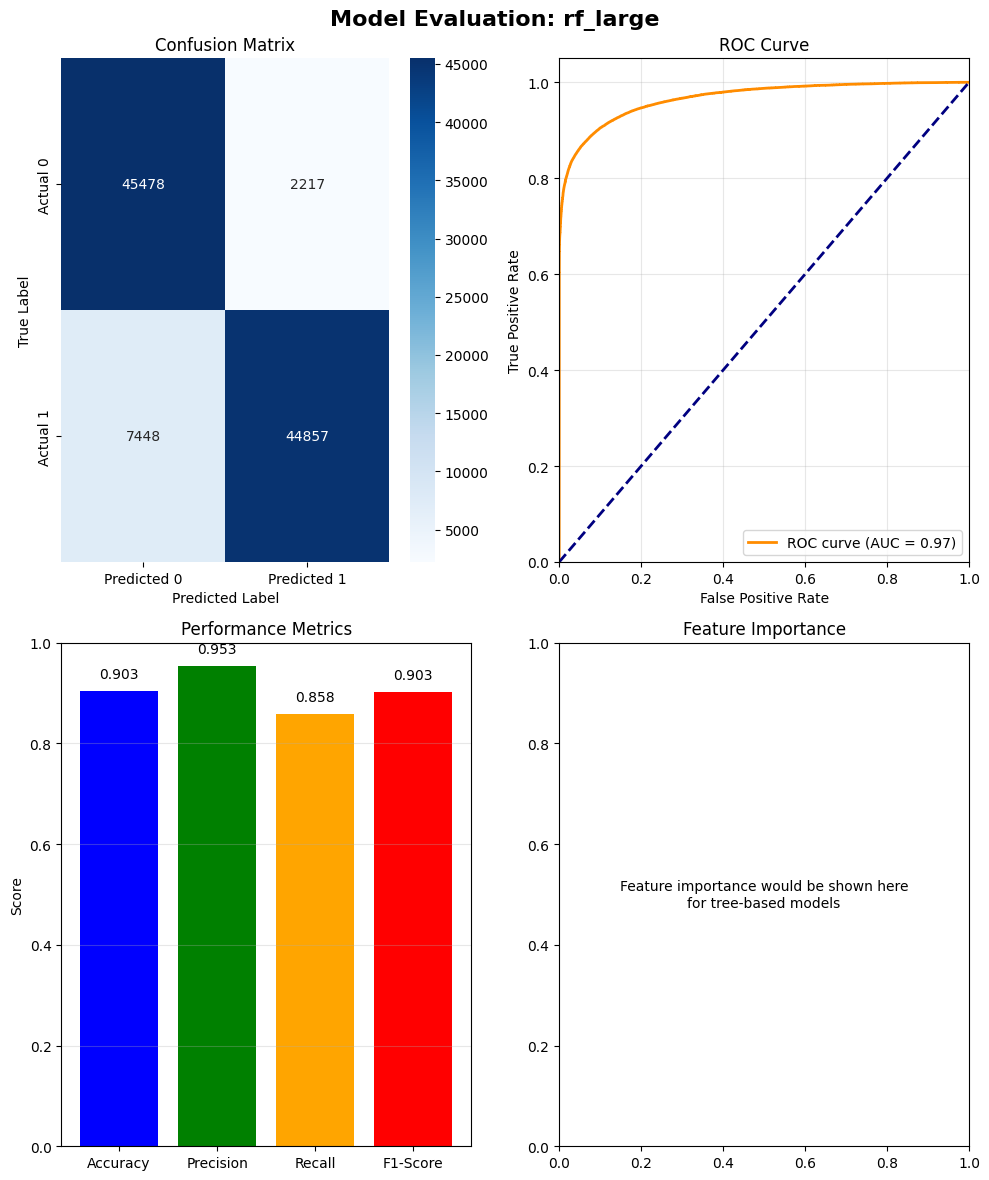

Training time: 235.32 seconds
Number of trees: 600
Max depth: 10
--------------------------------------------------

Training rf_tuned...

EVALUATION RESULTS FOR: rf_tuned
ROC-AUC Score: 0.9648

Basic Metrics:
Accuracy:  0.9002
Precision: 0.9510
Recall:    0.8530
F1-Score:  0.8994

Confusion Matrix:
True Negatives: 45397
False Positives: 2298
False Negatives: 7687
True Positives: 44618

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.86      0.95      0.90     47695
     Class 1       0.95      0.85      0.90     52305

    accuracy                           0.90    100000
   macro avg       0.90      0.90      0.90    100000
weighted avg       0.91      0.90      0.90    100000



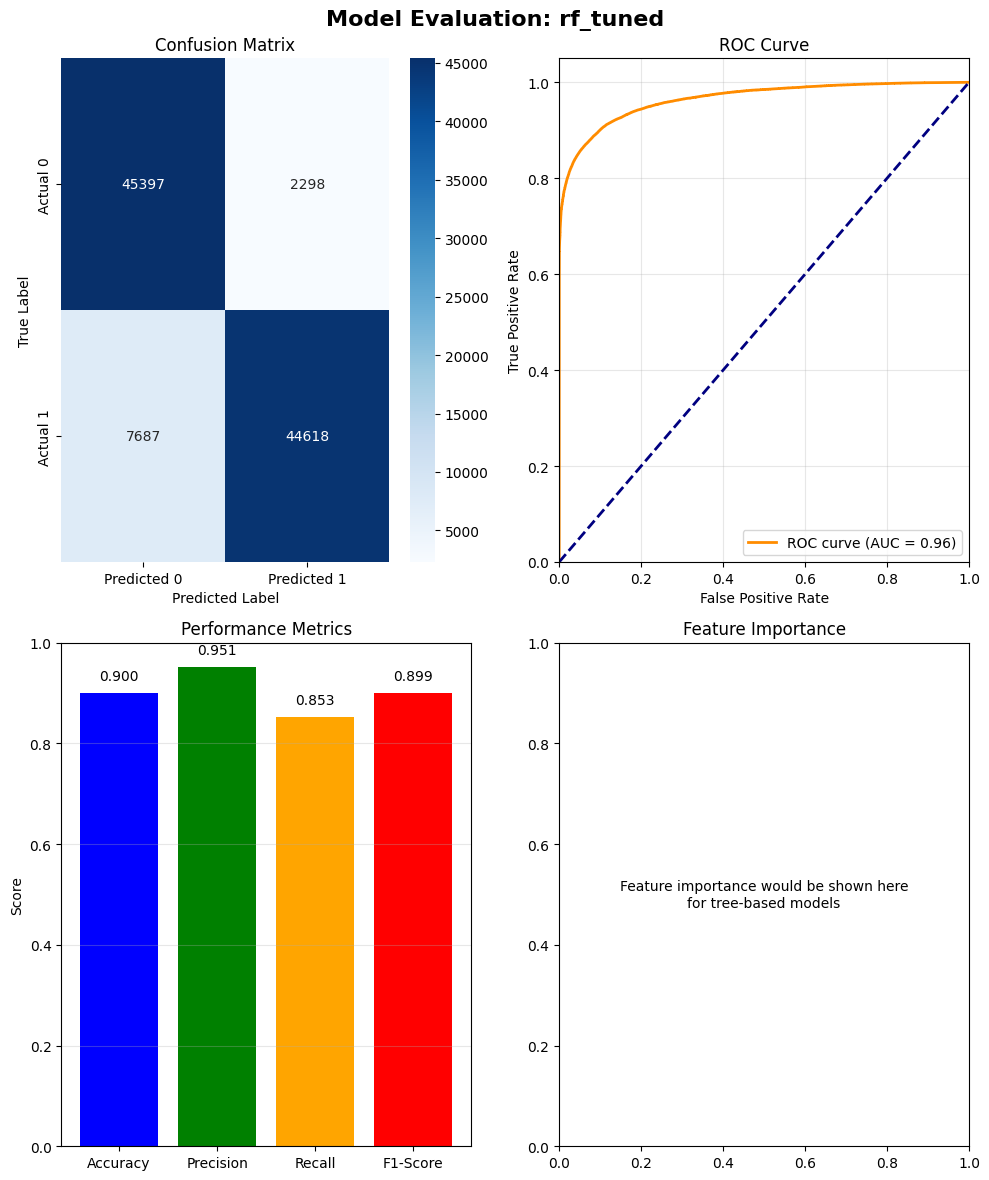

Training time: 130.04 seconds
Number of trees: 200
Max depth: 8
--------------------------------------------------

Training rf_basic...

EVALUATION RESULTS FOR: rf_basic
ROC-AUC Score: 0.9665

Basic Metrics:
Accuracy:  0.9028
Precision: 0.9537
Recall:    0.8558
F1-Score:  0.9021

Confusion Matrix:
True Negatives: 45520
False Positives: 2175
False Negatives: 7541
True Positives: 44764

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.86      0.95      0.90     47695
     Class 1       0.95      0.86      0.90     52305

    accuracy                           0.90    100000
   macro avg       0.91      0.91      0.90    100000
weighted avg       0.91      0.90      0.90    100000



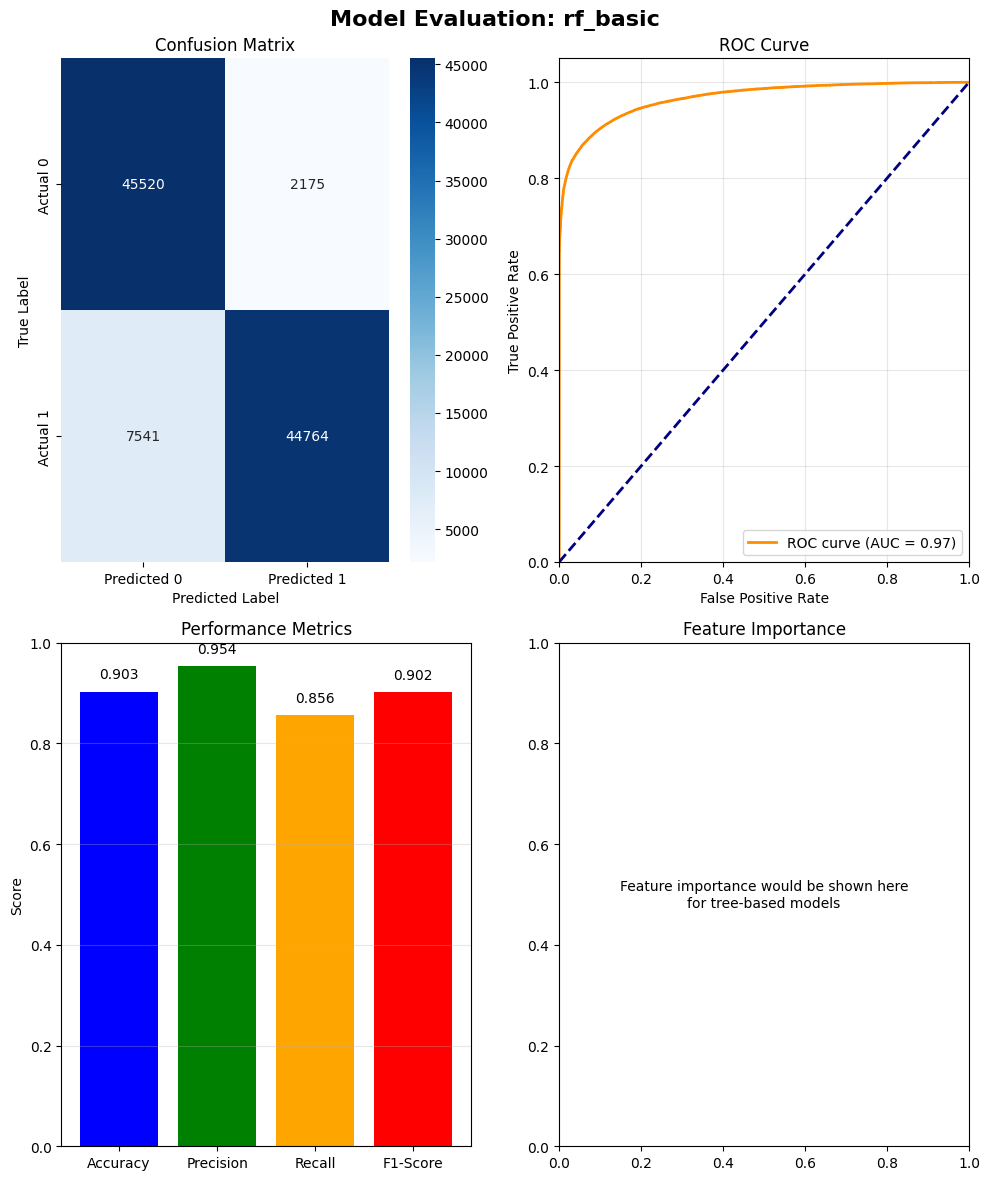

Training time: 39.68 seconds
Number of trees: 100
Max depth: 10
--------------------------------------------------

Training rf_fast...

EVALUATION RESULTS FOR: rf_fast
ROC-AUC Score: 0.9647

Basic Metrics:
Accuracy:  0.9003
Precision: 0.9490
Recall:    0.8552
F1-Score:  0.8997

Confusion Matrix:
True Negatives: 45293
False Positives: 2402
False Negatives: 7572
True Positives: 44733

Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.86      0.95      0.90     47695
     Class 1       0.95      0.86      0.90     52305

    accuracy                           0.90    100000
   macro avg       0.90      0.90      0.90    100000
weighted avg       0.91      0.90      0.90    100000



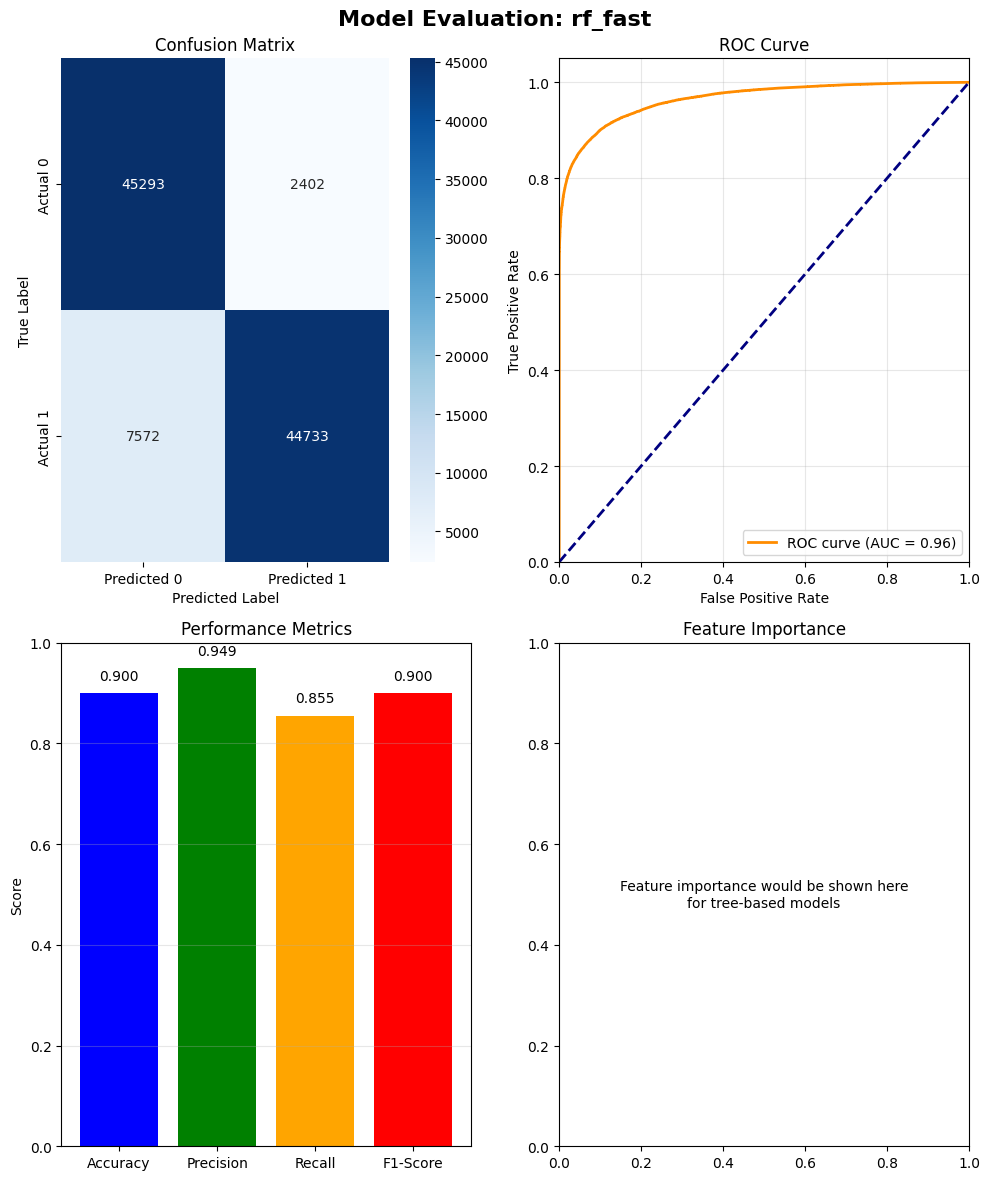

Training time: 32.95 seconds
Number of trees: 50
Max depth: 8
--------------------------------------------------

3. Performing cross-validation...

5-FOLD CROSS VALIDATION

Fold 1/5:

Fold 2/5:


KeyboardInterrupt: 

In [17]:
# Run complete Random Forest pipeline
results = main_random_forest_pipeline()

# Save the best model
best_model = results['best_model']
save_random_forest_model(best_model, "best_random_forest")
# Save the best model
e_model = results['ensemble_models']
save_random_forest_model(e_model, "ensemble_random_forest")
# Make predictions on test data
predictions, probabilities, confidence = predict_with_confidence(best_model, X_test)

print(f"\nPredictions on test set:")
print(f"Shape: {predictions.shape}")
print(f"Sample predictions: {predictions[:10]}")
print(f"Sample confidence scores: {confidence[:10] if confidence is not None else 'N/A'}")

# predictions, probabilities, confidence = predict_with_confidence(best_rf, XT_scaled)

# # Option 6: Save and load models
# save_random_forest_model(best_rf, "my_random_forest")
# loaded_model = load_random_forest_model("/kaggle/working/models/my_random_forest.pkl")

**Gradient Boosted Trees (XGBoost, LightGBM, CatBoost)**

Checking library availability...
XGBoost available: True
LightGBM available: True
CatBoost available: True
GRADIENT BOOSTING MODELS PIPELINE
Training data shape: (500000, 15)
Test data shape: (100000, 15)
Features: 15
Training class distribution: [238475 261525]
Test class distribution: [47695 52305]

1. XGBoost Training

TRAINING XGBOOST MODELS

Training xgb_large...

Evaluating xgb_large...
Accuracy:  0.9326
Precision: 0.9575
Recall:    0.9115
F1-Score:  0.9340
ROC-AUC:   0.9806
Training time: 19.26 seconds
Number of estimators: 600
Learning rate: 0.05
--------------------------------------------------

Training xgb_basic...

Evaluating xgb_basic...
Accuracy:  0.9219
Precision: 0.9490
Recall:    0.8990
F1-Score:  0.9233
ROC-AUC:   0.9763
Training time: 3.69 seconds
Number of estimators: 100
Learning rate: 0.1
--------------------------------------------------

Training xgb_balanced...

Evaluating xgb_balanced...
Accuracy:  0.9284
Precision: 0.9565
Recall:    0.9043
F1-Score:  0.9297


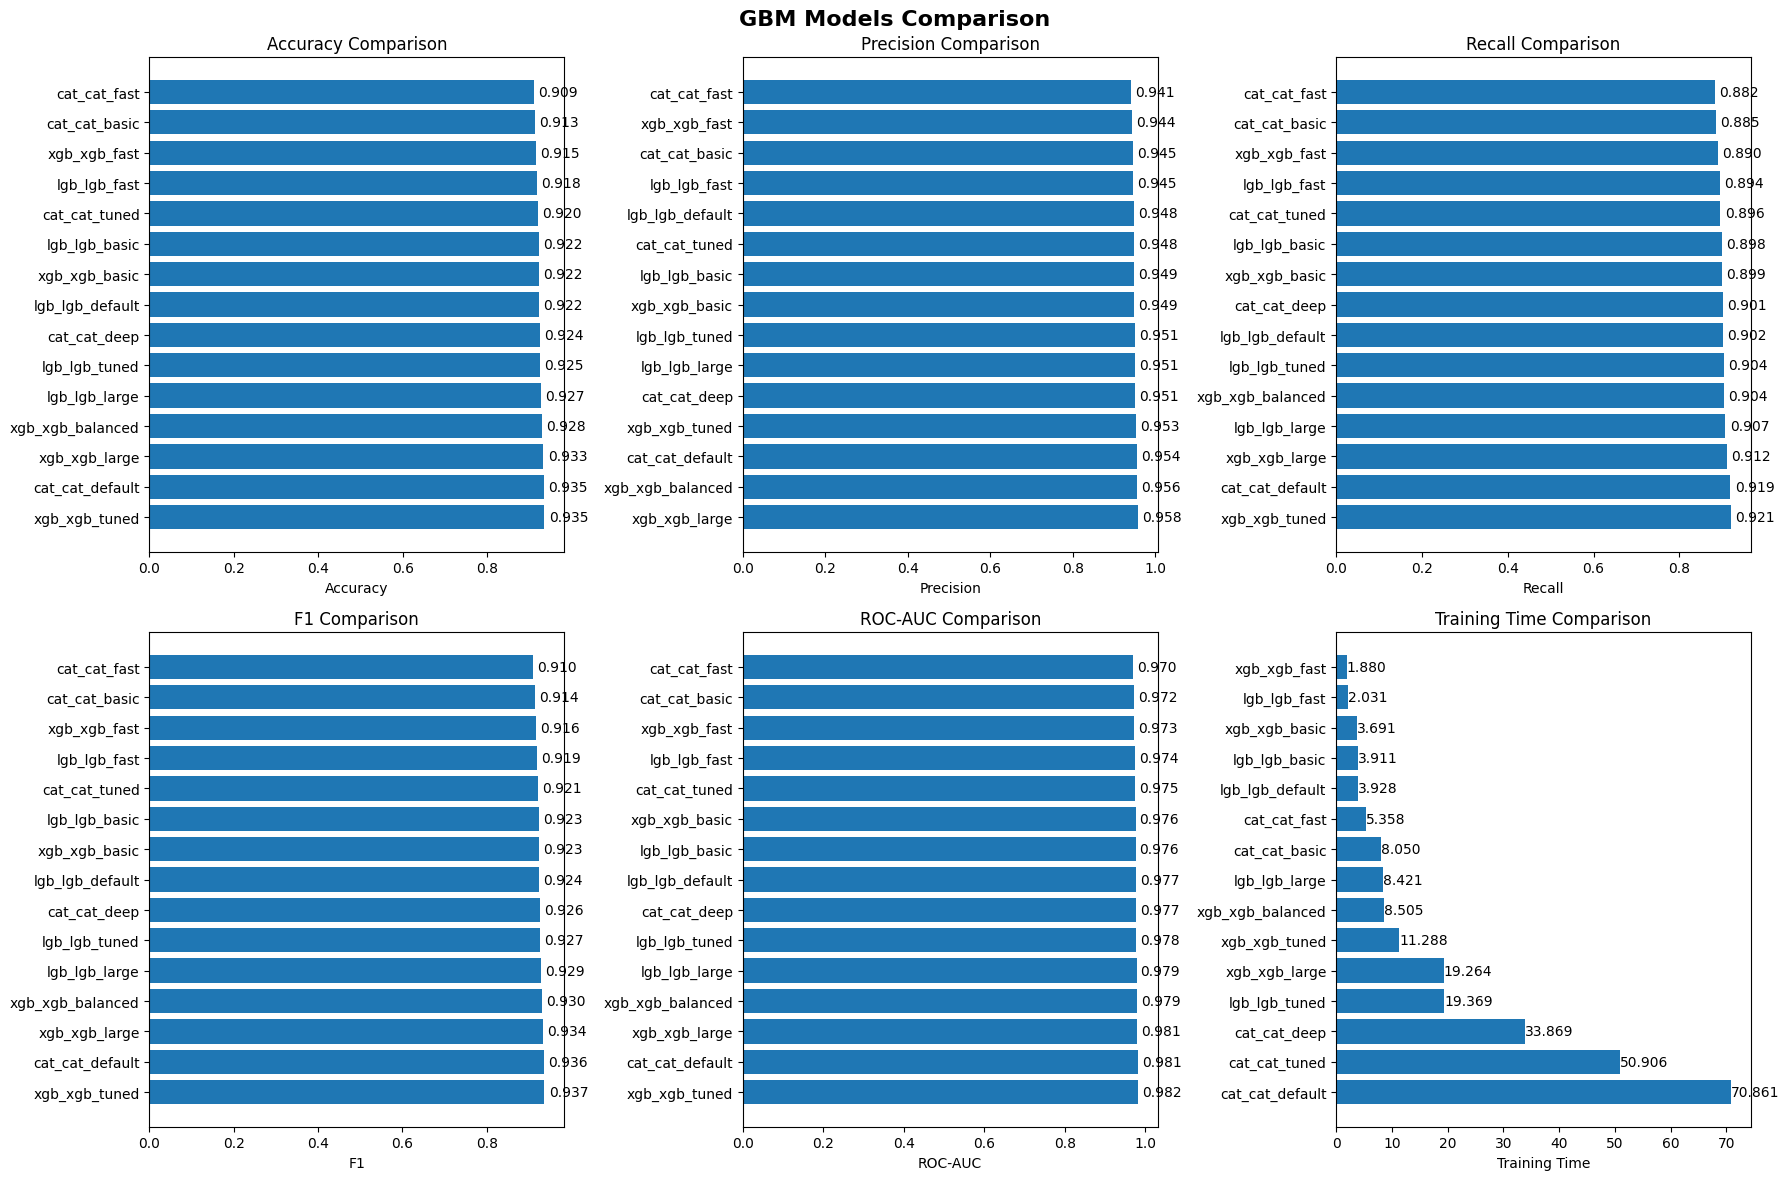


FEATURE IMPORTANCE ANALYSIS

FEATURE IMPORTANCE ANALYSIS

xgb_tuned - Top 10 features:
                 feature  importance
           ast_max_depth    0.411122
               loc_blank    0.121452
        snake_case_ratio    0.119811
           comment_ratio    0.112447
          ast_node_count    0.069914
         avg_line_length    0.024315
         halstead_volume    0.023685
ast_avg_branching_factor    0.017201
            loc_comments    0.016459
        ast_node_entropy    0.015927

lgb_tuned - Top 10 features:
                 feature  importance
         halstead_volume        1472
               loc_blank        1383
         avg_line_length        1238
   avg_identifier_length         917
ast_avg_branching_factor         879
        ast_node_entropy         829
 unique_identifier_ratio         789
          ast_node_count         754
           comment_ratio         642
    hapax_legomena_count         573

cat_tuned - Top 10 features:
                feature  importance
  

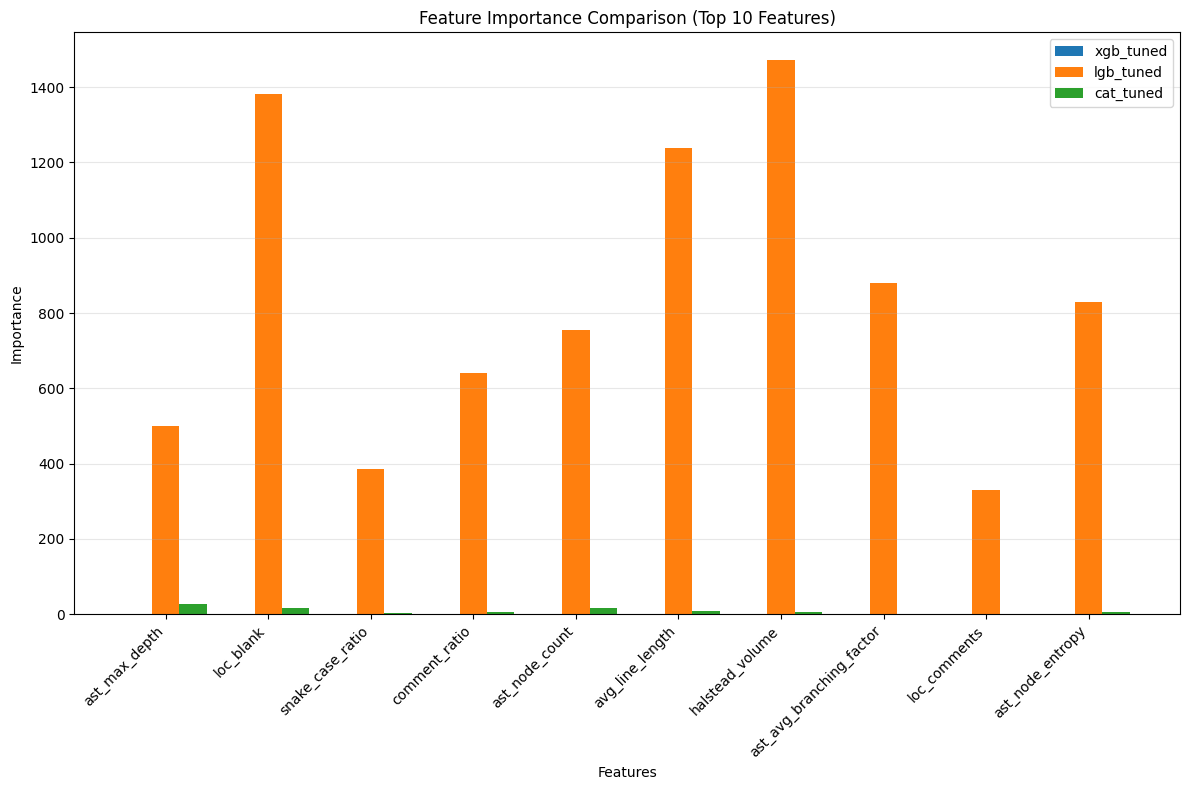


Best Model: xgb_xgb_tuned
Best Score: 0.9819

CREATING GBM ENSEMBLE
Training xgb_ensemble for ensemble...
Training lgb_ensemble for ensemble...
Training cat_ensemble for ensemble...

Evaluating GBM Ensemble (3 models)...
Accuracy:  0.9210
Precision: 0.9487
Recall:    0.8975
F1-Score:  0.9224
ROC-AUC:   0.9755


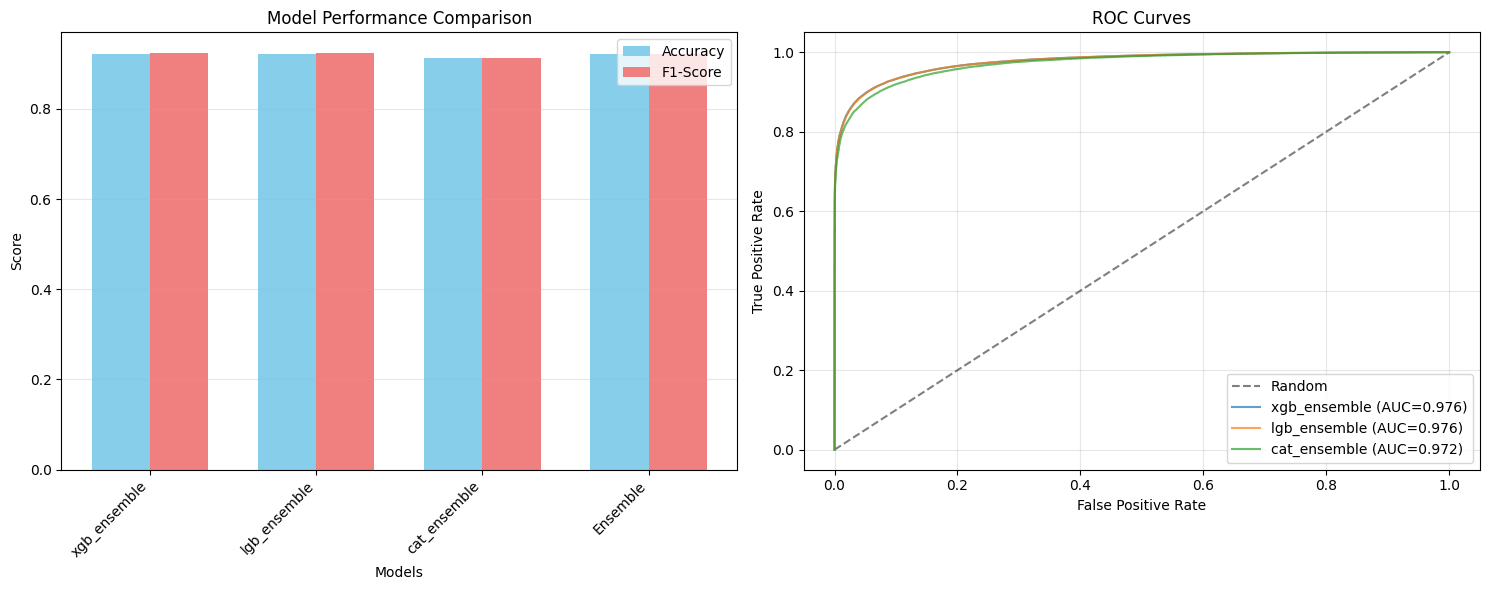

Saved xgb_ensemble to /kaggle/working/gbm_models/xgb_ensemble.pkl
Saved lgb_ensemble to /kaggle/working/gbm_models/lgb_ensemble.pkl
Saved CatBoost model to /kaggle/working/gbm_models/cat_ensemble.cbm
Saved xgb_large to /kaggle/working/gbm_models/xgb_large.pkl
Saved xgb_basic to /kaggle/working/gbm_models/xgb_basic.pkl
Saved xgb_balanced to /kaggle/working/gbm_models/xgb_balanced.pkl
Saved xgb_fast to /kaggle/working/gbm_models/xgb_fast.pkl
Saved xgb_tuned to /kaggle/working/gbm_models/xgb_tuned.pkl
Saved lgb_default to /kaggle/working/gbm_models/lgb_default.pkl
Saved lgb_basic to /kaggle/working/gbm_models/lgb_basic.pkl
Saved lgb_large to /kaggle/working/gbm_models/lgb_large.pkl
Saved lgb_fast to /kaggle/working/gbm_models/lgb_fast.pkl
Saved lgb_tuned to /kaggle/working/gbm_models/lgb_tuned.pkl
Saved CatBoost model to /kaggle/working/gbm_models/cat_default.cbm
Saved CatBoost model to /kaggle/working/gbm_models/cat_basic.cbm
Saved CatBoost model to /kaggle/working/gbm_models/cat_deep.cb

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import joblib
import pickle
from typing import Dict, List, Tuple, Optional, Any
warnings.filterwarnings('ignore')

# Try importing the boosting libraries
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    print("XGBoost not installed. Install with: pip install xgboost")
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    print("LightGBM not installed. Install with: pip install lightgbm")
    LGB_AVAILABLE = False

try:
    import catboost as cb
    CAT_AVAILABLE = True
except ImportError:
    print("CatBoost not installed. Install with: pip install catboost")
    CAT_AVAILABLE = False

from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, 
    StratifiedKFold, cross_val_score,
    train_test_split
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    mean_squared_error, mean_absolute_error
)
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform, loguniform

# ============================================
# 1. XGBoost Implementation
# ============================================

def train_xgboost_models(X_train, y_train, X_test, y_test):
    """
    Train multiple XGBoost models with different configurations
    """
    if not XGB_AVAILABLE:
        print("XGBoost not available. Skipping XGBoost training.")
        return {}, {}
    
    models = {}
    results = {}
    
    print("\n" + "="*60)
    print("TRAINING XGBOOST MODELS")
    print("="*60)
    
    # Define XGBoost configurations
    xgb_configs = {
        'xgb_large': xgb.XGBClassifier(
                n_estimators=600,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                scale_pos_weight=len(y[y==0]) / len(y[y==1]),
                random_state=42
            ),
        
        'xgb_basic': xgb.XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        
        'xgb_balanced': xgb.XGBClassifier(
            n_estimators=200,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.7,
            colsample_bytree=0.7,
            scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]) if len(np.unique(y_train)) == 2 else 1,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        
        'xgb_fast': xgb.XGBClassifier(
            n_estimators=50,
            max_depth=4,
            learning_rate=0.3,
            subsample=0.6,
            colsample_bytree=0.6,
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        
        'xgb_tuned' : xgb.XGBClassifier(
                n_estimators=200,
                max_depth=10,
                learning_rate=0.1,
                subsample=0.6,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                use_label_encoder=False
            )
    }
    
    # Train each model
    for model_name, model in xgb_configs.items():
        print(f"\nTraining {model_name}...")
        start_time = time.time()
        
        # Train model
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_scores = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        
        # Evaluate
        eval_results = evaluate_gbm_model(y_test, y_pred, y_scores, model_name)
        eval_results['training_time'] = training_time
        
        # Store results
        results[model_name] = eval_results
        models[model_name] = model
        
        # Print model info
        print(f"Training time: {training_time:.2f} seconds")
        print(f"Number of estimators: {model.n_estimators}")
        print(f"Learning rate: {model.learning_rate}")
        print("-" * 50)
    
    return models, results

def tune_xgboost(X_train, y_train, X_test, y_test, cv_folds=3):
    """
    Hyperparameter tuning for XGBoost
    """
    if not XGB_AVAILABLE:
        return None, {}, None
    
    print("\nTuning XGBoost hyperparameters...")
    
    # Base model
    xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, verbosity=0)
    
    # Parameter grid for tuning
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma': [0, 0.1, 0.2],
        'reg_alpha': [0, 0.01, 0.1],
        'reg_lambda': [1, 1.5, 2]
    }
    
    # Use RandomizedSearchCV for faster tuning
    search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_grid,
        n_iter=15,  # Number of parameter settings to sample
        cv=cv_folds,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    start_time = time.time()
    search.fit(X_train, y_train)
    tuning_time = time.time() - start_time
    
    print(f"\nXGBoost tuning completed in {tuning_time:.2f} seconds")
    print(f"Best parameters: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.4f}")
    
    # Train final model with best parameters
    best_xgb = search.best_estimator_
    
    # Evaluate on test set
    y_pred = best_xgb.predict(X_test)
    y_scores = best_xgb.predict_proba(X_test)[:, 1]
    
    results = evaluate_gbm_model(y_test, y_pred, y_scores, "Tuned XGBoost")
    results['best_params'] = search.best_params_
    results['tuning_time'] = tuning_time
    
    return best_xgb, results, search

# ============================================
# 2. LightGBM Implementation
# ============================================

def train_lightgbm_models(X_train, y_train, X_test, y_test):
    """
    Train multiple LightGBM models with different configurations
    """
    if not LGB_AVAILABLE:
        print("LightGBM not available. Skipping LightGBM training.")
        return {}, {}
    
    models = {}
    results = {}
    
    print("\n" + "="*60)
    print("TRAINING LIGHTGBM MODELS")
    print("="*60)
    
    # Create LightGBM dataset for faster training
    try:
        train_data = lgb.Dataset(X_train, label=y_train)
    except:
        train_data = None
    
    # Define LightGBM configurations
    lgb_configs = {
        'lgb_default': lgb.LGBMClassifier(
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        
        'lgb_basic': lgb.LGBMClassifier(
            n_estimators=100,
            max_depth=7,
            learning_rate=0.1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        
        'lgb_large': lgb.LGBMClassifier(
            n_estimators=200,
            max_depth=-1,  # No limit
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.7,
            colsample_bytree=0.7,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        
        'lgb_fast': lgb.LGBMClassifier(
            n_estimators=50,
            max_depth=5,
            learning_rate=0.3,
            num_leaves=16,
            subsample=0.6,
            colsample_bytree=0.6,
            random_state=42,
            n_jobs=-1,
                verbose=-1
        ),
        'lgb_tuned':lgb.LGBMClassifier(
            n_estimators=800,
            learning_rate=0.05,
            max_depth=4,
            num_leaves=31,          # default, safe with depth=4
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=3,           # similar to l2_leaf_reg
            objective="binary",
            random_state=42,
            n_jobs=-1
        )
    }
    
    # Train each model
    for model_name, model in lgb_configs.items():
        print(f"\nTraining {model_name}...")
        start_time = time.time()
        
        # Train model with early stopping if we have validation data
        try:
            if train_data is not None and len(y_train) > 10000:
                # Split for early stopping
                X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
                    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
                )
                
                model.fit(
                    X_train_sub, y_train_sub,
                    eval_set=[(X_val_sub, y_val_sub)],
                    eval_metric='logloss',
                    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
                )
            else:
                model.fit(X_train, y_train)
        except Exception as e:
            print(f"Error during training: {e}. Using simple fit.")
            model.fit(X_train, y_train)
        
        training_time = time.time() - start_time
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_scores = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        
        # Evaluate
        eval_results = evaluate_gbm_model(y_test, y_pred, y_scores, model_name)
        eval_results['training_time'] = training_time
        
        # Store results
        results[model_name] = eval_results
        models[model_name] = model
        
        # Print model info
        print(f"Training time: {training_time:.2f} seconds")
        print(f"Number of estimators: {model.n_estimators}")
        print(f"Number of leaves: {model.num_leaves}")
        print("-" * 50)
    
    return models, results

def tune_lightgbm(X_train, y_train, X_test, y_test, cv_folds=3):
    """
    Hyperparameter tuning for LightGBM
    """
    if not LGB_AVAILABLE:
        return None, {}, None
    
    print("\nTuning LightGBM hyperparameters...")
    
    # Base model
    lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    
    # Parameter grid
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, -1],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'num_leaves': [15, 31, 63, 127],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0, 0.01, 0.1],
        'reg_lambda': [0, 0.01, 0.1]
    }
    
    # Use RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=lgb_model,
        param_distributions=param_grid,
        n_iter=15,
        cv=cv_folds,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    start_time = time.time()
    search.fit(X_train, y_train)
    tuning_time = time.time() - start_time
    
    print(f"\nLightGBM tuning completed in {tuning_time:.2f} seconds")
    print(f"Best parameters: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.4f}")
    
    # Train final model with best parameters
    best_lgb = search.best_estimator_
    
    # Evaluate on test set
    y_pred = best_lgb.predict(X_test)
    y_scores = best_lgb.predict_proba(X_test)[:, 1]
    
    results = evaluate_gbm_model(y_test, y_pred, y_scores, "Tuned LightGBM")
    results['best_params'] = search.best_params_
    results['tuning_time'] = tuning_time
    
    return best_lgb, results, search

# ============================================
# 3. CatBoost Implementation
# ============================================

def train_catboost_models(X_train, y_train, X_test, y_test):
    """
    Train multiple CatBoost models with different configurations
    """
    if not CAT_AVAILABLE:
        print("CatBoost not available. Skipping CatBoost training.")
        return {}, {}
    
    models = {}
    results = {}
    
    print("\n" + "="*60)
    print("TRAINING CATBOOST MODELS")
    print("="*60)
    
    # Define CatBoost configurations
    # Note: CatBoost handles categorical features automatically if specified
    cat_configs = {
        'cat_default': cb.CatBoostClassifier(
            random_state=42,
            verbose=0,
            thread_count=-1
        ),
        
        'cat_basic': cb.CatBoostClassifier(
            iterations=100,
            depth=6,
            learning_rate=0.1,
            l2_leaf_reg=3,
            random_strength=1,
            random_state=42,
            verbose=0,
            thread_count=-1
        ),
        
        'cat_deep': cb.CatBoostClassifier(
            iterations=200,
            depth=10,
            learning_rate=0.05,
            l2_leaf_reg=5,
            random_strength=1.5,
            border_count=128,
            random_state=42,
            verbose=0,
            thread_count=-1
        ),
        
        'cat_fast': cb.CatBoostClassifier(
            iterations=50,
            depth=4,
            learning_rate=0.3,
            l2_leaf_reg=1,
            random_strength=0.5,
            random_state=42,
            verbose=0,
            thread_count=-1
        ),
        'cat_tuned' : cb.CatBoostClassifier(
                iterations=800,
                learning_rate=0.05,
                depth=4,
                l2_leaf_reg=3,
                loss_function="Logloss",
                eval_metric="AUC",
                random_seed=42,
                verbose=0
            )
    }
    
    # Train each model
    for model_name, model in cat_configs.items():
        print(f"\nTraining {model_name}...")
        start_time = time.time()
        
        # Train model with early stopping
        try:
            # Split for early stopping
            X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
                X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
            )
            
            model.fit(
                X_train_sub, y_train_sub,
                eval_set=(X_val_sub, y_val_sub),
                early_stopping_rounds=10,
                verbose=False
            )
        except Exception as e:
            print(f"Using simple fit due to: {e}")
            model.fit(X_train, y_train, verbose=False)
        
        training_time = time.time() - start_time
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_scores = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
        
        # Evaluate
        eval_results = evaluate_gbm_model(y_test, y_pred, y_scores, model_name)
        eval_results['training_time'] = training_time
        
        # Store results
        results[model_name] = eval_results
        models[model_name] = model
        
        # Print model info
        print(f"Training time: {training_time:.2f} seconds")
        print(f"Number of iterations: {model.tree_count_ if hasattr(model, 'tree_count_') else 'N/A'}")
        print(f"Learning rate: {model.learning_rate_ if hasattr(model, 'learning_rate_') else 'N/A'}")
        print("-" * 50)
    
    return models, results

def tune_catboost(X_train, y_train, X_test, y_test, cv_folds=3):
    """
    Hyperparameter tuning for CatBoost
    """
    if not CAT_AVAILABLE:
        return None, {}, None
    
    print("\nTuning CatBoost hyperparameters...")
    
    # Base model
    cat_model = cb.CatBoostClassifier(
        random_state=42,
        verbose=0,
        thread_count=-1
    )
    
    # Parameter grid
    param_grid = {
        'iterations': [100, 200, 300],
        'depth': [4, 6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'l2_leaf_reg': [1, 3, 5, 7],
        'border_count': [32, 64, 128],
        'random_strength': [0.5, 1, 1.5]
    }
    
    # Use RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=cat_model,
        param_distributions=param_grid,
        n_iter=10,
        cv=cv_folds,
        scoring='roc_auc',
        random_state=42,
        n_jobs=1,  # CatBoost doesn't work well with n_jobs > 1 in GridSearchCV
        verbose=1
    )
    
    start_time = time.time()
    search.fit(X_train, y_train)
    tuning_time = time.time() - start_time
    
    print(f"\nCatBoost tuning completed in {tuning_time:.2f} seconds")
    print(f"Best parameters: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.4f}")
    
    # Train final model with best parameters
    best_cat = search.best_estimator_
    
    # Evaluate on test set
    y_pred = best_cat.predict(X_test)
    y_scores = best_cat.predict_proba(X_test)[:, 1]
    
    results = evaluate_gbm_model(y_test, y_pred, y_scores, "Tuned CatBoost")
    results['best_params'] = search.best_params_
    results['tuning_time'] = tuning_time
    
    return best_cat, results, search

# ============================================
# 4. Enhanced Evaluation Function for GBM
# ============================================

def evaluate_gbm_model(y_true, y_pred, y_scores, model_name):
    """
    Comprehensive evaluation for GBM models
    """
    print(f"\nEvaluating {model_name}...")
    
    # Calculate basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # ROC-AUC if available
    roc_auc = None
    if y_scores is not None and len(np.unique(y_true)) == 2:
        try:
            roc_auc = roc_auc_score(y_true, y_scores)
        except:
            roc_auc = None
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Store results
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }
    
    # Print results
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC:   {roc_auc:.4f}")
    
    return results

def plot_gbm_comparison(all_results):
    """
    Plot comparison of all GBM models
    """
    # Prepare data for plotting
    comparison_data = []
    for model_type, models in all_results.items():
        for model_name, metrics in models.items():
            if isinstance(metrics, dict):  # Ensure it's a metrics dict
                comparison_data.append({
                    'Model': f"{model_type}_{model_name}",
                    'Accuracy': metrics.get('accuracy', 0),
                    'Precision': metrics.get('precision', 0),
                    'Recall': metrics.get('recall', 0),
                    'F1': metrics.get('f1', 0),
                    'ROC-AUC': metrics.get('roc_auc', 0) or 0,
                    'Training Time': metrics.get('training_time', 0)
                })
    
    if not comparison_data:
        print("No results to plot")
        return
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Plotting
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('GBM Models Comparison', fontsize=16, fontweight='bold')
    
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Training Time']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 3, idx % 3]
        
        # Sort by metric
        sorted_df = comparison_df.sort_values(metric, ascending=False)
        
        bars = ax.barh(range(len(sorted_df)), sorted_df[metric].values)
        ax.set_yticks(range(len(sorted_df)))
        ax.set_yticklabels(sorted_df['Model'].values)
        ax.set_xlabel(metric)
        ax.set_title(f'{metric} Comparison')
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, sorted_df[metric].values)):
            ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{val:.3f}', ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return comparison_df

# ============================================
# 5. Feature Importance Analysis
# ============================================

def analyze_gbm_feature_importance(models_dict, feature_names, top_n=10):
    """
    Analyze and compare feature importance across different GBM models
    """
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    importance_dict = {}
    
    for model_name, model in models_dict.items():
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            
            # Create DataFrame for this model
            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances,
                'model': model_name
            }).sort_values('importance', ascending=False)
            
            importance_dict[model_name] = importance_df
            
            # Print top features
            print(f"\n{model_name} - Top {top_n} features:")
            print(importance_df.head(top_n)[['feature', 'importance']].to_string(index=False))
    
    # Plot comparison if we have multiple models
    if len(importance_dict) > 1:
        plot_feature_importance_comparison(importance_dict, top_n)
    
    return importance_dict

def plot_feature_importance_comparison(importance_dict, top_n=15):
    """
    Plot feature importance comparison across models
    """
    # Get union of top features across all models
    all_top_features = set()
    for model_name, df in importance_dict.items():
        all_top_features.update(df.head(top_n)['feature'].values)
    
    # Create comparison DataFrame
    comparison_data = []
    for feature in all_top_features:
        row = {'feature': feature}
        for model_name, df in importance_dict.items():
            importance = df[df['feature'] == feature]['importance'].values
            row[model_name] = importance[0] if len(importance) > 0 else 0
        comparison_data.append(row)
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values(comparison_df.columns[1], ascending=False).head(top_n)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    x = np.arange(len(comparison_df))
    width = 0.8 / len(importance_dict)
    
    for i, (model_name, df) in enumerate(importance_dict.items()):
        if model_name in comparison_df.columns:
            importances = comparison_df[model_name].values
            ax.bar(x + i*width - width*(len(importance_dict)-1)/2, 
                  importances, width, label=model_name)
    
    ax.set_xlabel('Features')
    ax.set_ylabel('Importance')
    ax.set_title(f'Feature Importance Comparison (Top {top_n} Features)')
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df['feature'], rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# ============================================
# 6. Main Pipeline
# ============================================

def gbm_main_pipeline():
    """
    Main pipeline for training and evaluating all GBM models
    """
    sampledf = df.copy() 
    testdf = pd.read_parquet("/kaggle/working/validation_features_all.parquet")
    #valdf = pd.read_parquet("/kaggle/working/validation_features_all.parquet")
    # Handle infinite values
    X_raw = sampledf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    #X_val_raw = valdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    XT_raw = testdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
    inf_count = np.isinf(sampledf[FINAL_FEATURES].to_numpy()).sum()
    
    # Fill NaNs
    X_clean = X_raw.fillna(X_raw.mean())
    #X_val_clean = X_val_raw.fillna(0)
    XT_clean = XT_raw.fillna(0)
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    #X_val = scaler.fit_transform(X_val_clean)
    XT_scaled = scaler.transform(XT_clean)
    # Target variable
    y = sampledf['label'].values
    #y_val = valdf['label'].values
    yt = testdf['label'].values
    
    # Split the data
    X_train, X_test, y_train, y_test = X_scaled,XT_scaled,y,yt
    print("GRADIENT BOOSTING MODELS PIPELINE")
    print("="*60)
    print(f"{'='*60}")
    print(f"Training data shape: {X_train.shape}")
    print(f"Test data shape: {X_test.shape}")
    print(f"Features: {len(FINAL_FEATURES)}")
    print(f"Training class distribution: {np.bincount(y_train)}")
    print(f"Test class distribution: {np.bincount(y_test)}")
    
    
    
    all_models = {}
    all_results = {}
    
    # 1. XGBoost
    if XGB_AVAILABLE:
        print("\n1. XGBoost Training")
        xgb_models, xgb_results = train_xgboost_models(X_train, y_train, X_test, y_test)
        all_models.update(xgb_models)
        all_results['xgb'] = xgb_results
        
        # # Tuning
        # best_xgb, xgb_tune_results, _ = tune_xgboost(X_train, y_train, X_test, y_test, cv_folds=3)
        # if best_xgb:
        #     all_models['xgb_tuned'] = best_xgb
        #     all_results['xgb']['xgb_tuned'] = xgb_tune_results
    
    # 2. LightGBM
    if LGB_AVAILABLE:
        print("\n2. LightGBM Training")
        lgb_models, lgb_results = train_lightgbm_models(X_train, y_train, X_test, y_test)
        all_models.update(lgb_models)
        all_results['lgb'] = lgb_results
        
        # # Tuning
        # best_lgb, lgb_tune_results, _ = tune_lightgbm(X_train, y_train, X_test, y_test, cv_folds=3)
        # if best_lgb:
        #     all_models['lgb_tuned'] = best_lgb
        #     all_results['lgb']['lgb_tuned'] = lgb_tune_results
    
    # 3. CatBoost
    if CAT_AVAILABLE:
        print("\n3. CatBoost Training")
        cat_models, cat_results = train_catboost_models(X_train, y_train, X_test, y_test)
        all_models.update(cat_models)
        all_results['cat'] = cat_results
        
        # # Tuning
        # best_cat, cat_tune_results, _ = tune_catboost(X_train, y_train, X_test, y_test, cv_folds=3)
        # if best_cat:
        #     all_models['cat_tuned'] = best_cat
        #     all_results['cat']['cat_tuned'] = cat_tune_results
    
    # 4. Comparison
    print("\n" + "="*60)
    print("MODEL COMPARISON")
    print("="*60)
    
    comparison_df = plot_gbm_comparison(all_results)
    
    # 5. Feature Importance
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    # Analyze feature importance for tuned models
    tuned_models = {k: v for k, v in all_models.items() if 'tuned' in k}
    if tuned_models:
        importance_dict = analyze_gbm_feature_importance(tuned_models, FINAL_FEATURES, top_n=10)
    
    # 6. Select best model
    best_model_name = None
    best_score = -1
    
    for model_type, models in all_results.items():
        for model_name, metrics in models.items():
            if isinstance(metrics, dict):
                score = metrics.get('roc_auc', 0) or metrics.get('f1', 0)
                if score > best_score:
                    best_score = score
                    best_model_name = f"{model_type}_{model_name}"
    
    print(f"\nBest Model: {best_model_name}")
    print(f"Best Score: {best_score:.4f}")
    
    return {
        'models': all_models,
        'results': all_results,
        'comparison': comparison_df,
        'best_model_name': best_model_name,
        'best_score': best_score
    }

# ============================================
# 7. Advanced Ensemble of GBM Models
# ============================================

def create_gbm_ensemble(X_train, y_train, X_test, y_test):
    """
    Create an ensemble of different GBM models
    """
    print("\n" + "="*60)
    print("CREATING GBM ENSEMBLE")
    print("="*60)
    
    ensemble_models = []
    predictions = []
    probabilities = []
    model_names = []
    
    # Define different GBM models for ensemble
    ensemble_configs = []
    
    if XGB_AVAILABLE:
        ensemble_configs.append(('xgb_ensemble', xgb.XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            random_state=42, n_jobs=-1, verbosity=0
        )))
    
    if LGB_AVAILABLE:
        ensemble_configs.append(('lgb_ensemble', lgb.LGBMClassifier(
            n_estimators=100, max_depth=7, learning_rate=0.1,
            random_state=42, n_jobs=-1, verbose=-1
        )))
    
    if CAT_AVAILABLE and len(ensemble_configs) < 3:  # Limit to 3 models
        ensemble_configs.append(('cat_ensemble', cb.CatBoostClassifier(
            iterations=100, depth=6, learning_rate=0.1,
            random_state=42, verbose=0, thread_count=-1
        )))
    
    # Train each model
    for model_name, model in ensemble_configs:
        print(f"Training {model_name} for ensemble...")
        
        try:
            model.fit(X_train, y_train)
            ensemble_models.append((model_name, model))
            model_names.append(model_name)
            
            # Get predictions
            pred = model.predict(X_test)
            proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else pred
            
            predictions.append(pred)
            probabilities.append(proba)
            
        except Exception as e:
            print(f"Failed to train {model_name}: {e}")
    
    if len(predictions) == 0:
        print("No models trained successfully for ensemble")
        return None, None, None, None
    
    # Ensemble predictions
    predictions_array = np.array(predictions)
    probabilities_array = np.array(probabilities)
    
    # Weighted average (you can customize weights based on model performance)
    weights = np.ones(len(predictions_array)) / len(predictions_array)  # Equal weights
    
    # Weighted voting for classification
    weighted_predictions = np.average(predictions_array, axis=0, weights=weights)
    ensemble_predictions = np.round(weighted_predictions)
    
    # Weighted average probabilities
    ensemble_probabilities = np.average(probabilities_array, axis=0, weights=weights)
    
    # Evaluate ensemble
    results = evaluate_gbm_model(y_test, ensemble_predictions, ensemble_probabilities, 
                                f"GBM Ensemble ({len(ensemble_models)} models)")
    
    # Plot individual vs ensemble performance
    plot_ensemble_comparison(predictions_array, probabilities_array, model_names, y_test)
    
    return ensemble_models, ensemble_predictions, ensemble_probabilities, results

def plot_ensemble_comparison(predictions_array, probabilities_array, model_names, y_test):
    """
    Plot comparison of individual models vs ensemble
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Calculate metrics for each model
    accuracies = []
    f1_scores = []
    
    for i in range(len(predictions_array)):
        acc = accuracy_score(y_test, predictions_array[i])
        f1 = f1_score(y_test, predictions_array[i], zero_division=0)
        accuracies.append(acc)
        f1_scores.append(f1)
    
    # Add ensemble (average of predictions)
    ensemble_pred = np.round(np.mean(predictions_array, axis=0))
    accuracies.append(accuracy_score(y_test, ensemble_pred))
    f1_scores.append(f1_score(y_test, ensemble_pred, zero_division=0))
    extended_names = model_names + ['Ensemble']
    
    # Plot
    x = np.arange(len(extended_names))
    width = 0.35
    
    axes[0].bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
    axes[0].bar(x + width/2, f1_scores, width, label='F1-Score', color='lightcoral')
    axes[0].set_xlabel('Models')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Model Performance Comparison')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(extended_names, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # ROC curves if available
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    
    for i in range(len(probabilities_array)):
        if len(np.unique(y_test)) == 2:
            fpr, tpr, _ = roc_curve(y_test, probabilities_array[i])
            roc_auc = auc(fpr, tpr)
            axes[1].plot(fpr, tpr, label=f'{model_names[i]} (AUC={roc_auc:.3f})', alpha=0.7)
    
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curves')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================
# 8. Utility Functions
# ============================================

def save_gbm_models(models_dict, path="/kaggle/working/gbm_models/"):
    """Save trained GBM models"""
    import os
    os.makedirs(path, exist_ok=True)
    
    for model_name, model in models_dict.items():
        filename = f"{path}{model_name}.pkl"
        
        # Special handling for CatBoost
        if 'cat' in model_name.lower() and CAT_AVAILABLE:
            model.save_model(f"{path}{model_name}.cbm")
            print(f"Saved CatBoost model to {path}{model_name}.cbm")
        else:
            joblib.dump(model, filename)
            print(f"Saved {model_name} to {filename}")
def save_gbm_models_from_tuples(models_list, path="/kaggle/working/gbm_models/"):
    """
    Save trained GBM models from a list of (name, model) tuples.
    Handles CatBoost (.cbm) and other GBMs (.pkl)
    """
    import os
    os.makedirs(path, exist_ok=True)
    
    for model_name, model in models_list:
        # CatBoost models
        if 'cat' in model_name.lower() and CAT_AVAILABLE:
            filename = f"{path}{model_name}.cbm"
            model.save_model(filename)
            print(f"Saved CatBoost model to {filename}")
        else:
            filename = f"{path}{model_name}.pkl"
            joblib.dump(model, filename)
            print(f"Saved {model_name} to {filename}")

def load_gbm_model(model_path):
    """Load saved GBM model"""
    if model_path.endswith('.cbm') and CAT_AVAILABLE:
        model = cb.CatBoostClassifier()
        model.load_model(model_path)
    else:
        model = joblib.load(model_path)
    return model

def predict_with_all_models(models_dict, X_new):
    """Make predictions with all models"""
    all_predictions = {}
    
    for model_name, model in models_dict.items():
        try:
            if hasattr(model, 'predict_proba'):
                proba = model.predict_proba(X_new)
                pred = model.predict(X_new)
                all_predictions[model_name] = {
                    'predictions': pred,
                    'probabilities': proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]
                }
            else:
                pred = model.predict(X_new)
                all_predictions[model_name] = {
                    'predictions': pred,
                    'probabilities': None
                }
        except Exception as e:
            print(f"Error predicting with {model_name}: {e}")
    
    return all_predictions

# ============================================
# 9. Main Execution
# ============================================
# Check library availability
print("Checking library availability...")
print(f"XGBoost available: {XGB_AVAILABLE}")
print(f"LightGBM available: {LGB_AVAILABLE}")
print(f"CatBoost available: {CAT_AVAILABLE}")

if not any([XGB_AVAILABLE, LGB_AVAILABLE, CAT_AVAILABLE]):
    print("No GBM libraries available. Please install at least one of:")
    print("  pip install xgboost")
    print("  pip install lightgbm")
    print("  pip install catboost")
else:
    # Run main pipeline
    results = gbm_main_pipeline()
    
    # Create ensemble
    if len(results['models']) >= 2:
        ensemble_results = create_gbm_ensemble(X_train, y_train, X_test, y_test)
        
        if ensemble_results:
            ensemble_models, ensemble_pred, ensemble_proba, ensemble_metrics = ensemble_results
            results['ensemble'] = {
                'models': ensemble_models,
                'predictions': ensemble_pred,
                'probabilities': ensemble_proba,
                'metrics': ensemble_metrics
            }
            save_gbm_models_from_tuples(ensemble_models)
    
    # Save models
    save_gbm_models(results['models'])
    
    # Make predictions on test data
    print("\n" + "="*60)
    print("MAKING PREDICTIONS")
    print("="*60)
    
    # Get the best model
    best_model_name = results['best_model_name']
    model_type, model_key = best_model_name.split('_', 1)
    best_model = results['models'].get(best_model_name.split('_', 1)[1] if '_' in best_model_name else best_model_name)
    
    if best_model:
        predictions = predict_with_all_models({best_model_name: best_model}, X_test)
        print(f"\nPredictions from best model ({best_model_name}):")
        print(f"Shape: {predictions[best_model_name]['predictions'].shape}")
        
        # # Save predictions
        # if probabilities is not None:
        #     pd.DataFrame({
        #         'predictions': predictions[best_model_name]['predictions'],
        #         'probabilities': predictions[best_model_name]['probabilities']
        #     }).to_csv("/kaggle/working/gbm_predictions.csv", index=False)
        #     print("Predictions saved to /kaggle/working/gbm_predictions.csv")

## Feed Forward Neural Network

In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Assuming FINAL_FEATURES is defined elsewhere in your code as a list of feature columns
# Load validation data (uncommented as per your mention)
# Handle infinite values and NaNs for validation
X_val_raw = valdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
X_val_clean = X_val_raw.fillna(0)

# Assuming you have already loaded sampledf and testdf as in your provided code
# Recompute scaling, but fit only on training data for better practice
X_raw = sampledf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)
XT_raw = testdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)

X_clean = X_raw.fillna(X_raw.mean())
XT_clean = XT_raw.fillna(0)

# Fit scaler on training data only
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)  # Training features
X_val_scaled = scaler.transform(X_val_clean)  # Validation features
XT_scaled = scaler.transform(XT_clean)  # Test features

# Target variables
y = sampledf['label'].values
y_val = valdf['label'].values
yt = testdf['label'].values

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # Shape for BCE (N, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(XT_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(yt, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define FFNN with hidden layers matching the MLP parameters
class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_layers=(256, 128)):
        super(FFNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_layers[0])
        self.fc2 = nn.Linear(hidden_layers[0], hidden_layers[1])
        self.fc3 = nn.Linear(hidden_layers[1], 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# Hyperparameters from your MLP tuning
learning_rate = 0.0001     # clf__learning_rate_init
hidden_layers = (256, 128) # clf__hidden_layer_sizes
weight_decay = 0.01        # clf__alpha (L2 regularization)

# Initialize model
input_dim = X_scaled.shape[1]  # number of features
model = FFNN(input_dim, hidden_layers=hidden_layers)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Training loop
num_epochs = 5  # adjust as needed
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    
    train_loss /= len(train_loader.dataset)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(val_loader.dataset)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    # Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_ffnn_model.pth')

# Load the best model for evaluation
model.load_state_dict(torch.load('best_ffnn_model.pth'))
model.eval()

# Evaluate on test set
test_loss = 0.0
all_preds, all_labels = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_x.size(0)
        preds = (outputs > 0.5).float()  # use 0.5 threshold for binary classification
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(batch_y.cpu().numpy().flatten())

test_loss /= len(test_loader.dataset)
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Test Loss: {test_loss:.6f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

# Save final model
torch.save(model.state_dict(), 'ffnn_model_final.pth')


Epoch 1/5, Train Loss: 0.319063, Val Loss: 0.310924
Epoch 2/5, Train Loss: 0.309045, Val Loss: 0.305856
Epoch 3/5, Train Loss: 0.308060, Val Loss: 0.305458
Epoch 4/5, Train Loss: 0.307718, Val Loss: 0.305345
Epoch 5/5, Train Loss: 0.307619, Val Loss: 0.305103
Test Loss: 0.305103
Test Accuracy: 0.8696
Test Precision: 0.9151
Test Recall: 0.8275
Test F1 Score: 0.8691


## Evaluation of our model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, 
    roc_auc_score, roc_curve, precision_recall_curve
)
import joblib
from tqdm import tqdm

# ==============================================================
# 1. LOAD SAVED MODELS
# ==============================================================
print("Loading saved models...")
try:
    logreg_model = joblib.load('models/best_random_forest.pkl')
    svm_model = joblib.load('models/dt_pruned.pkl')
    scaler = joblib.load('scaler.pkl')
    print("✓ Models loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error loading models: {e}")
    print("Please ensure the model files exist in the current directory.")
    print("Required files:")
    print("1. logistic_regression_model.pkl")
    print("2. linear_svm_model.pkl")
    print("3. scaler.pkl")
    exit()

# ==============================================================
# 2. DISPLAY DATASET INFO AND GET FEATURE COLUMNS
# ==============================================================
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)

print(f"Test dataset shape: {testdf.shape}")
print(f"Columns: {len(testdf.columns)}")

# ==============================================================
# 3. PREPARE TEST DATA
# ==============================================================
print("\n" + "="*60)
print("PREPARING TEST DATA")
print("="*60)

# Identify label column
label_column = 'label'

# Extract features and labels
X_test_raw = testdf[FINAL_FEATURES].copy()
y_true = testdf[label_column].values

# Handle infinite values
inf_count = np.isinf(X_test_raw.values).sum()
print(f"Replacing {inf_count} infinite values with 0...")
X_test_raw = X_test_raw.replace([np.inf, -np.inf], 0)

# Handle NaN values
nan_count = X_test_raw.isna().sum().sum()
print(f"Filling {nan_count} NaN values with 0...")
X_test_raw = X_test_raw.fillna(0)

# Convert to numpy array
X_test = X_test_raw.values

# Scale features
print("Scaling features...")
X_test_scaled = scaler.transform(X_test)

print(f"\nFinal test data shape: {X_test_scaled.shape}")
print(f"Number of samples: {len(X_test_scaled)}")
print(f"Class distribution:")
unique_classes, class_counts = np.unique(y_true, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f"  Class {cls}: {count} samples ({count/len(y_true)*100:.1f}%)")

# ==============================================================
# 4. MAKE PREDICTIONS
# ==============================================================
print("\n" + "="*60)
print("MAKING PREDICTIONS")
print("="*60)

# Logistic Regression predictions
print("\n1. Logistic Regression predictions...")
y_pred_lr = logreg_model.predict(X_test_scaled)
if hasattr(logreg_model, 'predict_proba'):
    y_proba_lr = logreg_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_proba_lr = None

# Linear SVM predictions
print("2. Linear SVM predictions...")
y_pred_svm = svm_model.predict(X_test_scaled)
if hasattr(svm_model, 'decision_function'):
    y_scores_svm = svm_model.decision_function(X_test_scaled)
else:
    y_scores_svm = None

# ==============================================================
# 5. EVALUATE MODELS
# ==============================================================
def evaluate_and_plot(y_true, y_pred, y_proba, model_name):
    """Evaluate model and create visualizations."""
    print(f"\n{'='*60}")
    print(f"{model_name.upper()} EVALUATION")
    print(f"{'='*60}")
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # ROC-AUC if available
    roc_auc = None
    if y_proba is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_proba)
        except:
            pass
    
    # Print results
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC  : {roc_auc:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(f"[[TN={tn:4d}  FP={fp:4d}]")
    print(f" [FN={fn:4d}  TP={tp:4d}]]")
    
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{model_name} - Model Evaluation', fontsize=16, fontweight='bold')
    
    # 1. Confusion Matrix Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                ax=axes[0, 0])
    axes[0, 0].set_title('Confusion Matrix')
    axes[0, 0].set_ylabel('True Label')
    axes[0, 0].set_xlabel('Predicted Label')
    
    # 2. ROC Curve
    if roc_auc is not None and y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, 
                       label=f'ROC curve (AUC = {roc_auc:.3f})')
        axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0, 1].set_xlim([0.0, 1.0])
        axes[0, 1].set_ylim([0.0, 1.05])
        axes[0, 1].set_xlabel('False Positive Rate')
        axes[0, 1].set_ylabel('True Positive Rate')
        axes[0, 1].set_title('ROC Curve')
        axes[0, 1].legend(loc="lower right")
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'ROC Curve\nNot Available', 
                       ha='center', va='center', fontsize=12)
        axes[0, 1].set_title('ROC Curve')
        axes[0, 1].axis('off')
    
    # 3. Metrics Bar Chart
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [accuracy, precision, recall, f1]
    
    bars = axes[0, 2].bar(metrics_names, metrics_values, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
    axes[0, 2].set_ylim([0, 1.05])
    axes[0, 2].set_ylabel('Score')
    axes[0, 2].set_title('Performance Metrics')
    axes[0, 2].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, metrics_values):
        height = bar.get_height()
        axes[0, 2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                       f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Precision-Recall Curve
    if y_proba is not None:
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)
        axes[1, 0].plot(recall_vals, precision_vals, color='green', lw=2)
        axes[1, 0].set_xlabel('Recall')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].set_title('Precision-Recall Curve')
        axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Prediction Distribution
    if y_proba is not None:
        axes[1, 1].hist([y_proba[y_true == 0], y_proba[y_true == 1]], 
                       bins=30, alpha=0.7, label=['Class 0', 'Class 1'],
                       color=['red', 'blue'], stacked=False)
        axes[1, 1].set_xlabel('Predicted Probability')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Prediction Distribution')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Feature Importance (for Logistic Regression only)
    if model_name.lower() == 'logistic regression' and hasattr(logreg_model, 'coef_'):
        feature_importance = pd.DataFrame({
            'Feature': FINAL_FEATURES,
            'Coefficient': logreg_model.coef_[0]
        }).sort_values('Coefficient', key=abs, ascending=False).head(10)
        
        colors = ['red' if x < 0 else 'green' for x in feature_importance['Coefficient']]
        axes[1, 2].barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
        axes[1, 2].set_xlabel('Coefficient Value')
        axes[1, 2].set_title('Top 10 Feature Importance')
        axes[1, 2].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'model_name': model_name
    }

# Evaluate Logistic Regression
results_lr = evaluate_and_plot(y_true, y_pred_lr, y_proba_lr, "Logistic Regression")

# Evaluate Linear SVM
results_svm = evaluate_and_plot(y_true, y_pred_svm, y_scores_svm, "Linear SVM")

# ==============================================================
# 6. MODEL COMPARISON
# ==============================================================
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

# Create comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'TP', 'TN', 'FP', 'FN'],
    'Logistic Regression': [
        f"{results_lr['accuracy']:.4f}",
        f"{results_lr['precision']:.4f}",
        f"{results_lr['recall']:.4f}",
        f"{results_lr['f1']:.4f}",
        f"{results_lr['roc_auc']:.4f}" if results_lr['roc_auc'] else 'N/A',
        results_lr['confusion_matrix'][1, 1],
        results_lr['confusion_matrix'][0, 0],
        results_lr['confusion_matrix'][0, 1],
        results_lr['confusion_matrix'][1, 0]
    ],
    'Linear SVM': [
        f"{results_svm['accuracy']:.4f}",
        f"{results_svm['precision']:.4f}",
        f"{results_svm['recall']:.4f}",
        f"{results_svm['f1']:.4f}",
        f"{results_svm['roc_auc']:.4f}" if results_svm['roc_auc'] else 'N/A',
        results_svm['confusion_matrix'][1, 1],
        results_svm['confusion_matrix'][0, 0],
        results_svm['confusion_matrix'][0, 1],
        results_svm['confusion_matrix'][1, 0]
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

lr_values = [results_lr['accuracy'], results_lr['precision'], 
             results_lr['recall'], results_lr['f1']]
svm_values = [results_svm['accuracy'], results_svm['precision'], 
              results_svm['recall'], results_svm['f1']]

axes[0].bar(x - width/2, lr_values, width, label='Logistic Regression', color='blue', alpha=0.7)
axes[0].bar(x + width/2, svm_values, width, label='Linear SVM', color='red', alpha=0.7)

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Winner indicator
best_model = 'Logistic Regression' if results_lr['accuracy'] > results_svm['accuracy'] else 'Linear SVM'
accuracy_diff = abs(results_lr['accuracy'] - results_svm['accuracy'])

axes[0].text(0.5, 1.08, f'Best Model: {best_model} (Δ={accuracy_diff:.4f})', 
             ha='center', va='center', transform=axes[0].transAxes,
             fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

# Confusion matrices side by side
axes[1].axis('off')  # Turn off for text display
comparison_text = f"""
=== MODEL COMPARISON ===

Logistic Regression:
• Accuracy:  {results_lr['accuracy']:.4f}
• F1-Score:  {results_lr['f1']:.4f}
• ROC-AUC:   {results_lr['roc_auc'] }

Linear SVM:
• Accuracy:  {results_svm['accuracy']:.4f}
• F1-Score:  {results_svm['f1']:.4f}
• ROC-AUC:   {results_svm['roc_auc']}

BEST MODEL: {best_model}
Accuracy Difference: {accuracy_diff:.4f}
"""
axes[1].text(0.1, 0.5, comparison_text, fontfamily='monospace', fontsize=11,
             verticalalignment='center', transform=axes[1].transAxes,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.5))

plt.tight_layout()
plt.show()

# ==============================================================
# 7. SAVE RESULTS
# ==============================================================
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Create results dataframe
results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM'],
    'Accuracy': [results_lr['accuracy'], results_svm['accuracy']],
    'Precision': [results_lr['precision'], results_svm['precision']],
    'Recall': [results_lr['recall'], results_svm['recall']],
    'F1_Score': [results_lr['f1'], results_svm['f1']],
    'ROC_AUC': [results_lr['roc_auc'] if results_lr['roc_auc'] else None, 
                results_svm['roc_auc'] if results_svm['roc_auc'] else None],
    'TP': [results_lr['confusion_matrix'][1, 1], results_svm['confusion_matrix'][1, 1]],
    'TN': [results_lr['confusion_matrix'][0, 0], results_svm['confusion_matrix'][0, 0]],
    'FP': [results_lr['confusion_matrix'][0, 1], results_svm['confusion_matrix'][0, 1]],
    'FN': [results_lr['confusion_matrix'][1, 0], results_svm['confusion_matrix'][1, 0]]
})

# Save to CSV
results_summary.to_csv('model_evaluation_results.csv', index=False)
print("✓ Results saved to 'model_evaluation_results.csv'")

# Save detailed predictions
predictions_df = pd.DataFrame({
    'True_Label': y_true,
    'LR_Prediction': y_pred_lr,
    'LR_Probability': y_proba_lr if y_proba_lr is not None else [None] * len(y_true),
    'SVM_Prediction': y_pred_svm
})

# Add original features if needed
for i, feat in enumerate(FINAL_FEATURES):
    predictions_df[feat] = X_test[:, i]

predictions_df.to_csv('detailed_predictions.csv', index=False)
print("✓ Detailed predictions saved to 'detailed_predictions.csv'")

print("\n" + "="*60)
print("EVALUATION COMPLETE!")
print("="*60)
print(f"Test Samples: {len(y_true)}")
print(f"Features Used: {len(FINAL_FEATURES)}")
print(f"Best Model: {best_model}")
print("="*60)

## Language wise Evaluation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_auc_score, roc_curve
)
import joblib
from tqdm import tqdm

# ==============================================================
# 1. LOAD SAVED MODELS
# ==============================================================
print("Loading saved models...")
try:
    rf_model = joblib.load('models/best_random_forest.pkl')
    dt_model = joblib.load('models/dt_optimized.pkl')
    scaler = joblib.load('scaler.pkl')
    print("✓ Models loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ Error loading models: {e}")
    print("Please ensure the model files exist:")
    print("1. Randomforest_model.pkl")
    print("2. Disicion Tree.pkl")
    print("3. scaler.pkl")
    exit()

# ==============================================================
# 2. Define your feature columns (adjust based on your 29 features)
# ==============================================================
# Replace FINAL_FEATURES with your actual feature column names
# Example: FINAL_FEATURES = ['feature1', 'feature2', ..., 'feature29']
# You need to provide the exact feature names used during training

# This is IMPORTANT - you must define your feature names here

# ==============================================================
# 3. Prepare features from test dataframe
# ==============================================================
def prepare_features(df, feature_columns):
    """
    Extract and preprocess features from dataframe.
    """
    # Extract features
    X = df[feature_columns].copy()
    
    # Handle infinite values
    X = X.replace([np.inf, -np.inf], np.nan)
    
    # Count infinite values
    inf_count = np.isinf(df[feature_columns].to_numpy()).sum()
    print(f"  Infinite values handled: {inf_count}")
    
    # Fill NaN values (matching training preprocessing)
    X = X.fillna(0)
    
    # Convert to numpy array
    X_array = X.values
    
    return X_array


# ==============================================================
# 4. Batch prediction function for traditional ML models
# ==============================================================
def predict_batch_ml(feature_matrix, model, batch_size=1000):
    """
    Predict using traditional ML models on batches of features.
    """
    preds = []
    probas = []
    
    # Process in batches if needed (for memory efficiency)
    for i in tqdm(range(0, len(feature_matrix), batch_size), desc="Predicting"):
        batch = feature_matrix[i : i + batch_size]
        
        # Scale features
        X_batch_scaled = scaler.transform(batch)
        
        # Predict
        batch_preds = model.predict(X_batch_scaled)
        preds.extend(batch_preds)
        
        # Get probabilities if available
        if hasattr(model, 'predict_proba'):
            batch_probas = model.predict_proba(X_batch_scaled)[:, 1]
            probas.extend(batch_probas)
        elif hasattr(model, 'decision_function'):
            batch_scores = model.decision_function(X_batch_scaled)
            probas.extend(batch_scores)
        else:
            probas.extend(batch_preds)
    
    return np.array(preds), np.array(probas)

# ==============================================================
# 5. Model evaluation wrapper
# ==============================================================
def evaluate_model(y_true, y_pred, y_proba, model_name, language):
    """
    Comprehensive evaluation of a model.
    """
    print("\n" + "="*60)
    print(f"Model: {model_name} | Language: {language}")
    print("="*60)
    
    # Basic metrics
    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    
    # Per-class metrics
    prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_per = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    # ROC-AUC if we have probability scores
    roc_auc = None
    if y_proba is not None and len(np.unique(y_true)) == 2:
        try:
            roc_auc = roc_auc_score(y_true, y_proba)
        except:
            pass
    
    # Print results
    print(f"Accuracy        : {acc:.4f}")
    print(f"Macro Precision : {prec_macro:.4f}")
    print(f"Macro Recall    : {recall_macro:.4f}")
    print(f"Macro F1-Score  : {f1_macro:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC Score   : {roc_auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    
    return {
        'accuracy': acc,
        'precision_macro': prec_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_per': prec_per,
        'recall_per': rec_per,
        'f1_per': f1_per,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'model_name': model_name,
        'language': language,
        'y_true': y_true,
        'y_proba': y_proba if y_proba is not None else y_pred
    }

# ==============================================================
# 6. Visualization function
# ==============================================================
def plot_results(results_dict, language):
    """
    Plot confusion matrix and metrics for a model.
    """
    cm = results_dict['confusion_matrix']
    model_name = results_dict['model_name']
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 6a. Confusion Matrix
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='RdBu', cbar=True,
        xticklabels=['0', '1'], yticklabels=['0', '1'],
        linewidths=.5, linecolor='gray', ax=axes[0]
    )
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title(f"Confusion Matrix\n{model_name} ({language})")
    
    # 6b. Per-class + macro bar chart
    labels = ['Class 0', 'Class 1', 'macro']
    x = np.arange(len(labels))
    width = 0.2
    
    # Prepare data
    acc_vals = [np.nan, np.nan, results_dict['accuracy']]
    prec_vals = list(results_dict['precision_per']) + [results_dict['precision_macro']]
    rec_vals = list(results_dict['recall_per']) + [results_dict['recall_macro']]
    f1_vals = list(results_dict['f1_per']) + [results_dict['f1_macro']]
    
    # Plot bars
    axes[1].bar(x - 1.5*width, acc_vals, width, label="Accuracy", color="#4C72B0")
    axes[1].bar(x - 0.5*width, prec_vals, width, label="Precision", color="#DD8452")
    axes[1].bar(x + 0.5*width, rec_vals, width, label="Recall", color="#55A868")
    axes[1].bar(x + 1.5*width, f1_vals, width, label="F1-Score", color="#C44E52")
    
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_ylabel("Score")
    axes[1].set_title(f"Metrics\n{model_name} ({language})")
    axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # 6c. ROC Curve (if available)
    if results_dict['roc_auc'] is not None:
        fpr, tpr, _ = roc_curve(results_dict['y_true'], results_dict['y_proba'])
        axes[2].plot(fpr, tpr, color='darkorange', lw=2, 
                    label=f'ROC curve (AUC = {results_dict["roc_auc"]:.3f})')
        axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[2].set_xlim([0.0, 1.0])
        axes[2].set_ylim([0.0, 1.05])
        axes[2].set_xlabel('False Positive Rate')
        axes[2].set_ylabel('True Positive Rate')
        axes[2].set_title(f'ROC Curve\n{model_name} ({language})')
        axes[2].legend(loc="lower right")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'ROC Curve\nNot Available', 
                    ha='center', va='center', fontsize=12)
        axes[2].set_title(f'ROC Curve\n{model_name} ({language})')
        axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==============================================================
# 7. Main evaluation loop
# ==============================================================
def evaluate_models_per_language(test_df, feature_columns):
    """
    Evaluate both models per language.
    """
    # Create normalized language column if it doesn't exist
    if 'language_norm' not in test_df.columns and 'language' in test_df.columns:
        test_df = test_df.copy()
        test_df["language_norm"] = test_df["language"].str.strip().str.lower()
    
    # Define language order
    canonical_order = ["c#", "go", "python", "c++", "java", "php", "javascript", "c"]
    
    # Get languages present in data
    if 'language_norm' in test_df.columns:
        present_langs = [l for l in canonical_order if l in set(test_df["language_norm"].unique())]
    else:
        # If no language column, evaluate on entire dataset
        present_langs = ["all"]
        test_df["language_norm"] = "all"
    
    all_results = []
    
    for la in present_langs:
        # Subset for this language
        sample_df = test_df[test_df["language_norm"] == la]
        
        if sample_df.empty:
            print(f"Skipping '{la}': no rows found.")
            continue
        
        print(f"\n{'='*60}")
        print(f"Language: {la} | Rows: {len(sample_df)}")
        print(f"{'='*60}")
        
        # Prepare features
        X_test = prepare_features(sample_df, feature_columns)
        
        # Get true labels
        # Adjust column name based on your test dataframe
        label_column = 'label'  # Change to your actual label column name
        
        y_true = sample_df[label_column].values
        
        # Check if labels need encoding
        if y_true.dtype == 'O':  # Object type (strings)
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder()
            y_true = le.fit_transform(y_true)
            print(f"  Labels encoded: {dict(zip(le.classes_, range(len(le.classes_))))}")
        
        # Evaluate Logistic Regression
        print(f"\nEvaluating Random forest on {la}...")
        y_pred_lr, y_proba_lr = predict_batch_ml(X_test, rf_model)
        
        if len(y_pred_lr) != len(y_true):
            print(f"Mismatch in predictions for LR on '{la}'. Skipping.")
            continue
        
        results_lr = evaluate_model(y_true, y_pred_lr, y_proba_lr, "Random Forest", la)
        plot_results(results_lr, la)
        all_results.append(results_lr)
        
        # Evaluate Linear SVM
        print(f"\nEvaluating Disicion Tree on {la}...")
        y_pred_svm, y_proba_svm = predict_batch_ml(X_test, dt_model)
        
        if len(y_pred_svm) != len(y_true):
            print(f"Mismatch in predictions for SVM on '{la}'. Skipping.")
            continue
        
        results_svm = evaluate_model(y_true, y_pred_svm, y_proba_svm, "Disicion Tree", la)
        plot_results(results_svm, la)
        all_results.append(results_svm)
        
        # Compare models for this language
        print(f"\n{'='*60}")
        print(f"MODEL COMPARISON - {la}")
        print(f"{'='*60}")
        
        comparison_data = {
            'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)', 'ROC-AUC'],
            'Random Forest': [
                results_lr['accuracy'],
                results_lr['precision_macro'],
                results_lr['recall_macro'],
                results_lr['f1_macro'],
                results_lr['roc_auc'] if results_lr['roc_auc'] else 'N/A'
            ],
            'Disicion Tree': [
                results_svm['accuracy'],
                results_svm['precision_macro'],
                results_svm['recall_macro'],
                results_svm['f1_macro'],
                results_svm['roc_auc'] if results_svm['roc_auc'] else 'N/A'
            ]
        }
        
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        
        # Determine best model
        if results_lr['accuracy'] > results_svm['accuracy']:
            print(f"\n✓ Random Forest is better by {results_lr['accuracy'] - results_svm['accuracy']:.4f} accuracy")
        elif results_svm['accuracy'] > results_lr['accuracy']:
            print(f"\n✓ Disicion Tree is better by {results_svm['accuracy'] - results_lr['accuracy']:.4f} accuracy")
        else:
            print(f"\n✓ Both models have the same accuracy")
    
    return all_results

# ==============================================================
# 8. Summary across all languages
# ==============================================================
def create_summary_table(all_results):
    """
    Create a summary table across all languages and models.
    """
    summary_data = []
    
    for result in all_results:
        summary_data.append({
            'Model': result['model_name'],
            'Language': result['language'],
            'Accuracy': f"{result['accuracy']:.4f}",
            'Precision': f"{result['precision_macro']:.4f}",
            'Recall': f"{result['recall_macro']:.4f}",
            'F1-Score': f"{result['f1_macro']:.4f}",
            'ROC-AUC': f"{result['roc_auc']:.4f}" if result['roc_auc'] else 'N/A',
            'TP': result['confusion_matrix'][1, 1],
            'TN': result['confusion_matrix'][0, 0],
            'FP': result['confusion_matrix'][0, 1],
            'FN': result['confusion_matrix'][1, 0]
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Calculate averages per model
    numeric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    summary_df_numeric = summary_df.copy()
    
    # Convert to numeric for calculation
    for col in numeric_cols:
        summary_df_numeric[col] = pd.to_numeric(summary_df_numeric[col], errors='coerce')
    
    avg_by_model = summary_df_numeric.groupby('Model')[numeric_cols].mean().round(4)
    
    return summary_df, avg_by_model

# ==============================================================
# 9. MAIN EXECUTION
# ==============================================================

print("="*70)
print("TRADITIONAL ML MODEL EVALUATION WITH EXISTING FEATURES")
print("="*70)

# Display test dataframe info
print("\nTest DataFrame Info:")
print(f"\nUsing features: {FINAL_FEATURES}")

# Verify we have label column
label_col = 'label'
print(f"Using label column: '{label_col}'")

testdf = pd.read_parquet("/kaggle/working/test_features_all.parquet")
# Run evaluation
all_results = evaluate_models_per_language(testdf, FINAL_FEATURES)

# Create summary
if all_results:
    summary_df, avg_by_model = create_summary_table(all_results)
    
    print("\n" + "="*70)
    print("SUMMARY ACROSS ALL LANGUAGES")
    print("="*70)
    print(summary_df.to_string(index=False))
    
    print("\n" + "="*70)
    print("AVERAGE PERFORMANCE BY MODEL")
    print("="*70)
    print(avg_by_model.to_string())
    
    # Save results to CSV
    summary_df.to_csv('ml_model_results_by_language.csv', index=False)
    avg_by_model.to_csv('ml_model_average_performance.csv')
    print("\n✓ Results saved to CSV files")
    
    # Plot overall comparison
    plt.figure(figsize=(10, 6))
    
    models = ['Random Forest', 'Disicion Tree']
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    # Prepare data
    lr_avg = avg_by_model.loc['Random Forest'] if 'Random Forest' in avg_by_model.index else [0]*4
    svm_avg = avg_by_model.loc['Disicion Tree'] if 'Disicion Tree' in avg_by_model.index else [0]*4
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, lr_avg, width, label='Random Forest', color='blue', alpha=0.7)
    plt.bar(x + width/2, svm_avg, width, label='Disicion Tree', color='red', alpha=0.7)
    
    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Average Model Performance Comparison')
    plt.xticks(x, metrics)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
else:
    print("\nNo results to summarize.")

# Clear ouput 🛑🚫⛔🛑🚫🚫🛑⛔

In [ ]:
import os
import shutil

# Path to Kaggle working directory
working_dir = "/kaggle/working"

# Iterate through all files and folders in the working directory
for item in os.listdir(working_dir):
    item_path = os.path.join(working_dir, item)
    try:
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.remove(item_path)  # remove file or symbolic link
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)  # remove directory
    except Exception as e:
        print(f"Failed to delete {item_path}. Reason: {e}")

print("✅ Kaggle working directory cleared.")


# Including Tf-Idf 

In [ ]:
print(f"Train: {len(train_df):,} samples")
print(f"Validation: {len(validation_df):,} samples")
print(f"Test: {len(test_df):,} samples")

In [ ]:
X_train = train_df['code'].values
y_train = train_df['label'].values

X_val = validation_df['code'].values
y_val = validation_df['label'].values

X_test = test_df['code'].values
y_test = test_df['label'].values


print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Test samples: {len(X_test):,}")

## Feature Extraction 

We'll try different n-gram configurations:

Word n-grams (1-3)
Character n-grams (3-5)
Combined

In [ ]:
# Experiment 1: Word n-grams (1-3)
from time import time
from sklearn.feature_extraction.text import TfidfVectorizer
print("Creating TF-IDF features (word 1-3 grams)...")
tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    max_features=10000,
    min_df=2,
    sublinear_tf=True
)

start = time()
X_train_word = tfidf_word.fit_transform(X_train)
X_val_word = tfidf_word.transform(X_val)
X_test_word = tfidf_word.transform(X_test)
print(f"Done in {time() - start:.2f}s")
print(f"Feature shape: {X_train_word.shape}")

In [ ]:
# Experiment 2: Character n-grams (3-5)
print("\nCreating TF-IDF features (char 3-5 grams)...")
tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=10000,
    min_df=2,
    sublinear_tf=True
)

start = time()
X_train_char = tfidf_char.fit_transform(X_train)
X_val_char = tfidf_char.transform(X_val)
X_test_char = tfidf_char.transform(X_test)
print(f"Done in {time() - start:.2f}s")
print(f"Feature shape: {X_train_char.shape}")

In [ ]:
def plot_evaluation_metrics(y_true, y_pred, model_name, cm):
    """
    Plot evaluation metrics
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 12))
    fig.suptitle(f'Model Evaluation: {model_name}', fontsize=16, fontweight='bold')
    
    # 1. Confusion Matrix Heatmap
    ax1 = axes[0, 0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'], ax=ax1)
    ax1.set_title('Confusion Matrix')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # 3. Metrics Bar Chart
    ax3 = axes[1, 0]
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]
    
    bars = ax3.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
    ax3.set_ylim([0, 1])
    ax3.set_title('Performance Metrics')
    ax3.set_ylabel('Score')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{value:.3f}', ha='center', va='bottom')
    
    # 4. Feature Importance (if using tree models)
    ax4 = axes[1, 1]
    ax4.text(0.5, 0.5, 'Feature importance would be shown here\nfor tree-based models',
            horizontalalignment='center', verticalalignment='center',
            transform=ax4.transAxes)
    ax4.set_title('Feature Importance')
    
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name):
    """
    Train and evaluate a model on train, validation, and test sets.
    """
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    
    # Train
    print("Training...")
    start = time()
    model.fit(X_train, y_train)
    train_time = time() - start
    print(f"Training time: {train_time:.2f}s")
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Evaluate
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    val_f1 = f1_score(y_val, y_val_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    
    print(f"\nMacro F1 Scores:")
    print(f"  Train: {train_f1:.4f}")
    print(f"  Val:   {val_f1:.4f}")
    print(f"  Test:  {test_f1:.4f}")

        # Detailed validation report
    print(f"\nValidation Set Classification Report:")
    print(classification_report(y_val, y_val_pred, digits= 4))
    
    # Test set report
    print(f"\nTest Set Classification Report:")
    cf = confusion_matrix(y_test, y_test_pred)
    print(classification_report(y_test, y_test_pred, digits= 4))
    plot_evaluation_metrics(y_test, y_test_pred, model_name, cf)
    return {
        'model_name': model_name,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'train_time': train_time,
        'model': model,
        'y_test_pred': y_test_pred
    }

In [ ]:
results = []
# Model 1: Logistic Regression with word n-grams
lr_word = LogisticRegression(
    max_iter=500,
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1
)

result = evaluate_model(lr_word, X_train_word, y_train, X_val_word, y_val, 
                       X_test_word, y_test, "Logistic Regression (Word 1-3 grams)")
results.append(result)

In [ ]:
# Model 2: Random Forest with word n-grams
rf_word = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=20
)

result = evaluate_model(rf_word, X_train_word, y_train, X_val_word, y_val, 
                       X_test_word, y_test, "Random Forest (Word 1-3 grams)")
results.append(result)

In [ ]:
# Model 3: XGBoost with word n-grams (if available)
# Calculate scale_pos_weight for each class

from xgboost import XGBClassifier
class_counts = np.bincount(y_train)
total = len(y_train)

xgb_word =  XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

result = evaluate_model(xgb_word, X_train_word, y_train, X_val_word, y_val, 
                        X_test_word, y_test, "XGBoost (Word 1-3 grams)")
results.append(result)

In [ ]:
# Model 5: XGBoost with char n-grams (if available)
xgb_char = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

result = evaluate_model(xgb_char, X_train_char, y_train, X_val_char, y_val, 
                        X_test_char, y_test, "XGBoost (Char 3-5 grams)")
results.append(result)



In [ ]:
# Model 5: Random Forest with word n-grams
rf_char = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=20
)

result = evaluate_model(rf_char, X_train_char, y_train, X_val_char, y_val, 
                       X_test_char, y_test, "Random Forest (Char 1-3 grams)")
results.append(result)

In [ ]:
# Create results dataframe
results_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Train F1': f"{r['train_f1']:.4f}",
    'Val F1': f"{r['val_f1']:.4f}",
    'Test F1': f"{r['test_f1']:.4f}",
    'Train Time (s)': f"{r['train_time']:.2f}"
} for r in results])

print("\n" + "="*80)
print("BASELINE RESULTS SUMMARY")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

In [ ]:
# Find best model based on validation F1
best_result = max(results, key=lambda x: x['test_f1'])
print(f"\n🏆 Best Model: {best_result['model_name']}")
print(f"   Val F1: {best_result['val_f1']:.4f}")
print(f"   Test F1: {best_result['test_f1']:.4f}")

## Combining tf-idf and extracted features

In [ ]:
# positive class probabilities
p_basic = rf_model.predict_proba(X_test_tab)[:, 1]
p_word  = rf_word.predict_proba(X_test_tfidf)[:, 1]

# base predictions
pred_basic = (p_basic >= 0.5).astype(int)
import numpy as np
from sklearn.metrics import f1_score

def guarded_ensemble(
    p_basic,
    p_word,
    y_true,
    base_threshold=0.5,
    word_high=0.95,     # tfidf must be VERY confident
    basic_uncertain=0.15
):
    """
    Safe ensemble: never worse than base model
    """
    pred = (p_basic >= base_threshold).astype(int)

    # indices where basic model is uncertain
    uncertain = np.abs(p_basic - 0.5) < basic_uncertain

    # allow tfidf override ONLY when extremely confident
    override_to_1 = (p_word >= word_high) & uncertain
    override_to_0 = (p_word <= (1 - word_high)) & uncertain

    pred[override_to_1] = 1
    pred[override_to_0] = 0

    return pred
best_f1 = 0.52   # hard floor
best_params = None
best_pred = None
# Get predicted probabilities for validation set
p_basic_val = rf_model.predict_proba(X_val_tab)[:, 1]
p_word_val = rf_word.predict_proba(X_val_tfidf)[:, 1]

import numpy as np

# Generate 50 values from 0.97 to 0.60 for word_high
word_high_values = np.linspace(0.97, 0.60, 50)

# Generate 50 values from 0.40 to 0.10 for basic_uncertain
basic_uncertain_values = np.linspace(0.40, 0.10, 50)

# Smart nested loop
for word_high in word_high_values:
    for basic_uncertain in basic_uncertain_values:
    
        pred = guarded_ensemble(
            p_basic_val,
            p_word_val,
            y_val,
            word_high=word_high,
            basic_uncertain=basic_uncertain
        )
        f1 = f1_score(y_val, pred)

        if f1 > best_f1:
            best_f1 = f1
            best_params = (word_high, basic_uncertain)
            best_pred = pred

print("Best guarded ensemble F1:", best_f1)
print("Best params:", best_params)

# Apply to test set
p_basic = rf_model.predict_proba(X_test_tab)[:, 1]
p_word = rf_word.predict_proba(X_test_tfidf)[:, 1]

if best_params is None:
    print("No safe improvement found — using rf_basic only")
    final_pred = pred_basic
else:
    final_pred = guarded_ensemble(
        p_basic,
        p_word,
        y_test,
        word_high=best_params[0],
        basic_uncertain=best_params[1]
    )
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, final_pred, digits=4))

cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human", "Machine"],
            yticklabels=["Human", "Machine"])
plt.title("Final Guarded Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [18]:
!gdown --id  1up8AC6F0rp3pcvnKISPzhSLVVRW8p1ui -O /kaggle/working/finaltest_features_all.parquet


/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1up8AC6F0rp3pcvnKISPzhSLVVRW8p1ui
From (redirected): https://drive.google.com/uc?id=1up8AC6F0rp3pcvnKISPzhSLVVRW8p1ui&confirm=t&uuid=f89d49d9-70be-420e-8521-6ca40b1c5bec
To: /kaggle/working/finaltest_features_all.parquet
100%|█████████████████████████████████████████| 338M/338M [00:01<00:00, 196MB/s]


In [19]:

finaltestdf = pd.read_parquet("/kaggle/working/finaltest_features_all.parquet")
finaltestdf.info()
finaltestdf.head()
tdf = finaltestdf

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 38 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   code                       500000 non-null  object 
 1   ID                         500000 non-null  int64  
 2   language                   500000 non-null  object 
 3   loc_total                  500000 non-null  float64
 4   loc_comments               500000 non-null  float64
 5   loc_blank                  500000 non-null  float64
 6   comment_ratio              500000 non-null  float64
 7   avg_line_length            500000 non-null  float64
 8   max_line_length            500000 non-null  float64
 9   indentation_std_dev        500000 non-null  float64
 10  unique_identifier_ratio    500000 non-null  float64
 11  avg_identifier_length      500000 non-null  float64
 12  snake_case_ratio           500000 non-null  float64
 13  keyword_density            50

In [25]:
import joblib
import numpy as np
import pandas as pd
import os

# Assuming 'tdf' and 'scaler' are already defined elsewhere in the code

# 1. Extract features
XT_raw = tdf[FINAL_FEATURES].replace([np.inf, -np.inf], np.nan)

# 2. Handle missing values (same strategy as training)
XT_clean = XT_raw.fillna(XT_raw.mean())

# 3. Scale features using trained scaler
XT_scaled = scaler.transform(XT_clean)

# 4. Iterate through all model files in the "models" folder
models_folder = 'models'
model_files = [f for f in os.listdir(models_folder) if f.endswith('dt_pruned.pkl')]

# Loop through all model files
for model_file in model_files:
    model_path = os.path.join(models_folder, model_file)
    
    # Load the model
    model = joblib.load(model_path)
    
    # Predict labels (binary classification)
    pred_labels = model.predict(XT_scaled)
    pred_proba = model.predict_proba(XT_scaled)[:, 1]
    
    # Create submission DataFrame
    submission = pd.DataFrame({
        "ID": tdf["ID"],
        "label": pred_labels,
        "scores":pred_proba
    })
    
    # Save the prediction to a CSV file with model name in the file name
    submission_filename = f"submission_{model_file.split('.')[0]}.csv"
    submission.to_csv(submission_filename, index=False)
    
    print(f"{submission_filename} created successfully!")


submission_dt_pruned.csv created successfully!


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      500000 non-null  int64  
 1   label   500000 non-null  int64  
 2   scores  500000 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 11.4 MB


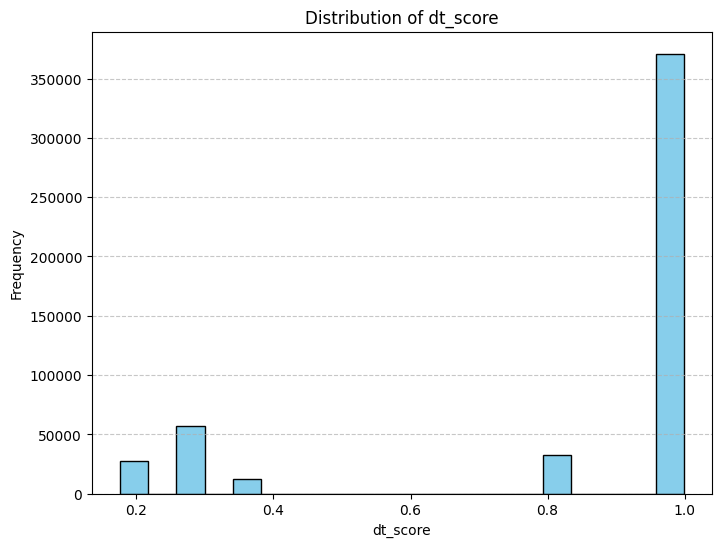

In [26]:
sf = pd.read_csv("/kaggle/working/submission_dt_pruned.csv")
sf.info()
sf.head(9) 
import matplotlib.pyplot as plt

# Plot histogram of dt_score values
plt.figure(figsize=(8, 6))
plt.hist(sf['scores'], bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of dt_score')
plt.xlabel('dt_score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
